In [21]:
from random import gauss
from random import seed
import random
import numpy as np
import pandas as pd
from pandas.plotting import autocorrelation_plot
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sn

# Stock Price and Sales Analysis of Magnificent 7 Stocks
## The seven stocks in the Mag7 are:
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;GOOG
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;TSLA
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;AMZN
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;AAPL
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;MSFT
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;META
#### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;NVDA

### Analysis of GOOG Stock and Fundamentals over last 10 years

In [106]:
#goog = pd.read_csv('GOOGL.csv',header=0, index_col=0, parse_dates=True,squeeze=True)
goog = pd.read_csv('GOOGL.csv')

In [107]:
goog.columns


Index(['Date', 'Sales', 'FreeCashFlow', 'Cash', 'Long Term Debt', 'Price'], dtype='object')

In [108]:
goog['Date'] = pd.to_datetime(goog['Date'], format='%m/%d/%Y')
goog['Year'] = goog['Date'].dt.year
goog['Quarter'] = goog['Date'].dt.quarter

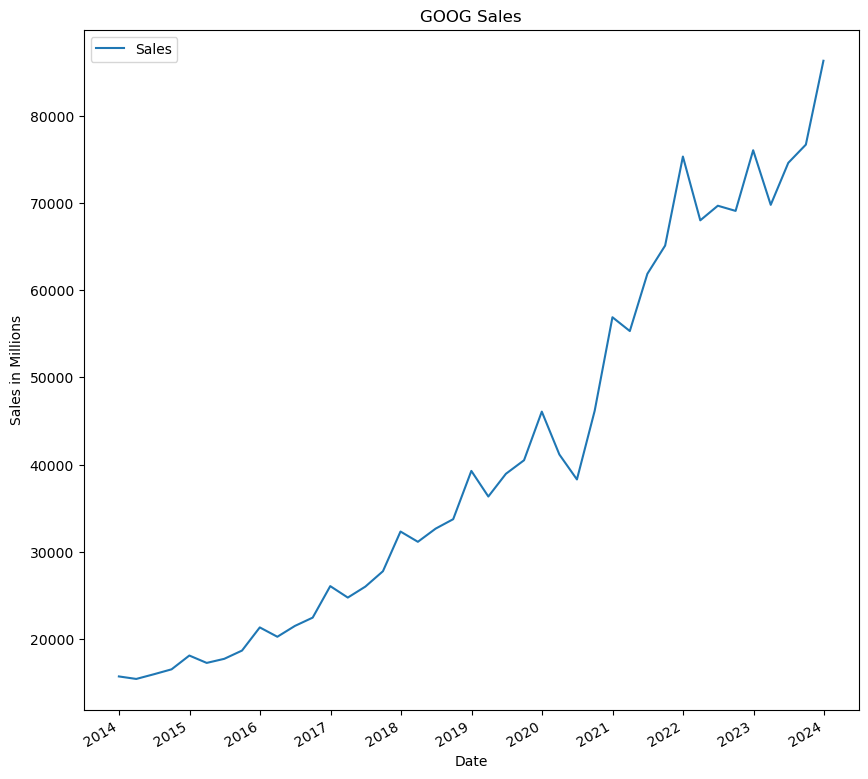

In [113]:
goog.plot('Date', 'Sales')
plt.title('GOOG Sales')
plt.ylabel('Sales in Millions')
plt.show()


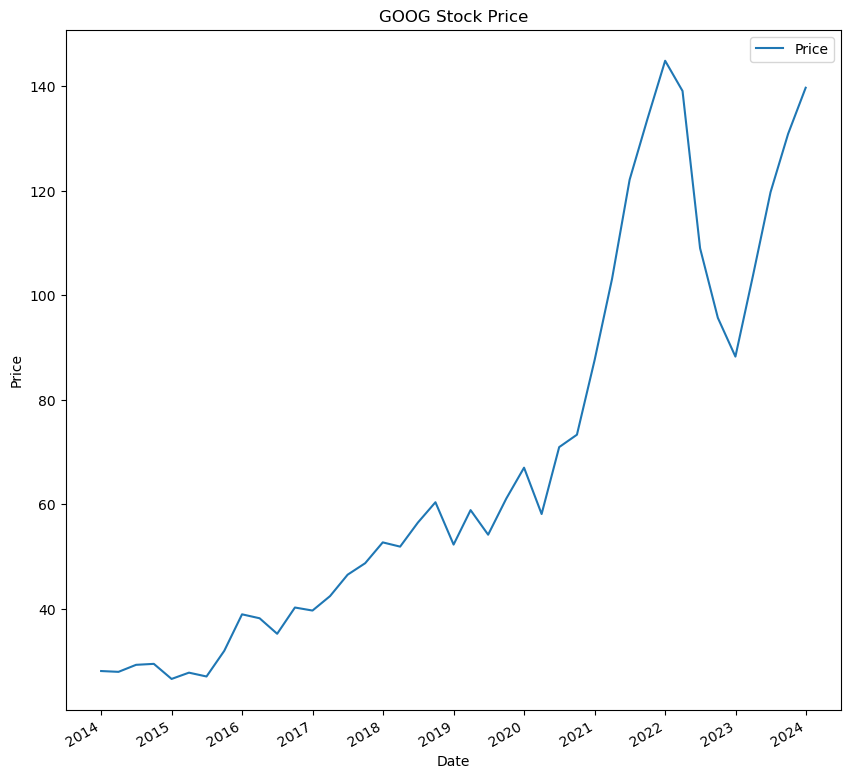

In [114]:
goog.plot('Date','Price')
plt.title('GOOG Stock Price')
plt.ylabel('Price')
plt.show()

Text(0.5, 1.0, 'GOOG Stock Price vs Sales')

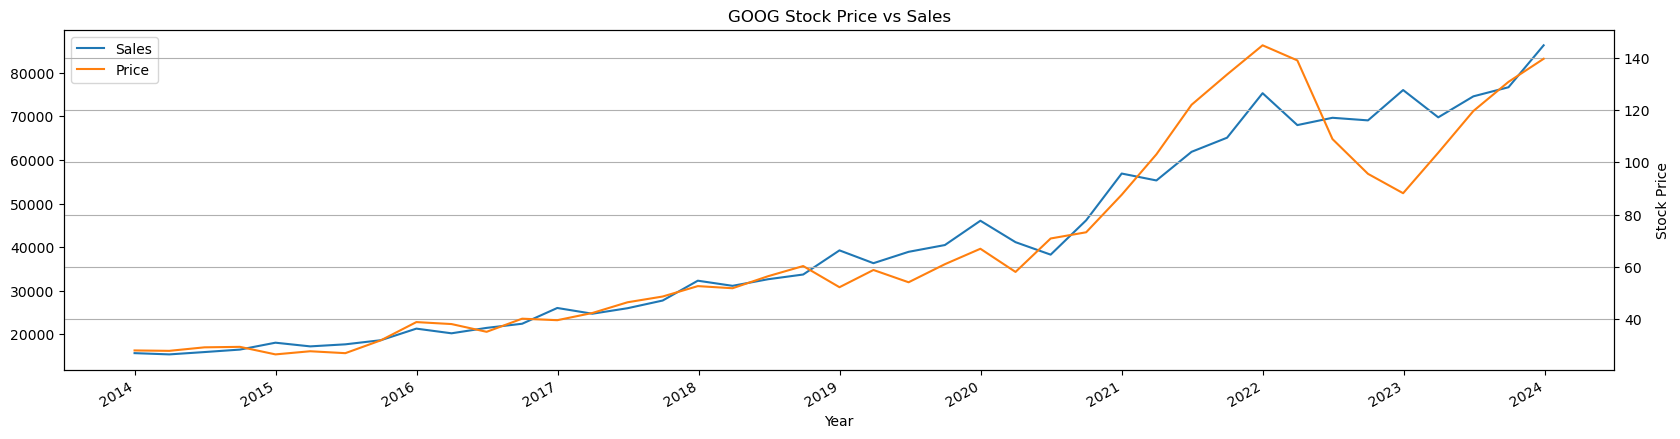

In [115]:
goog.loc[:,['Date','Sales','Price']].plot(x = 'Date',secondary_y=['Price'], xlabel = 'Year', ylabel = 'Stock Price',sharex = True,mark_right=False, figsize = (20,5), grid=True)
plt.title('GOOG Stock Price vs Sales')

[Text(0.5, 1.0, 'GOOG Box and Whisker by Year')]

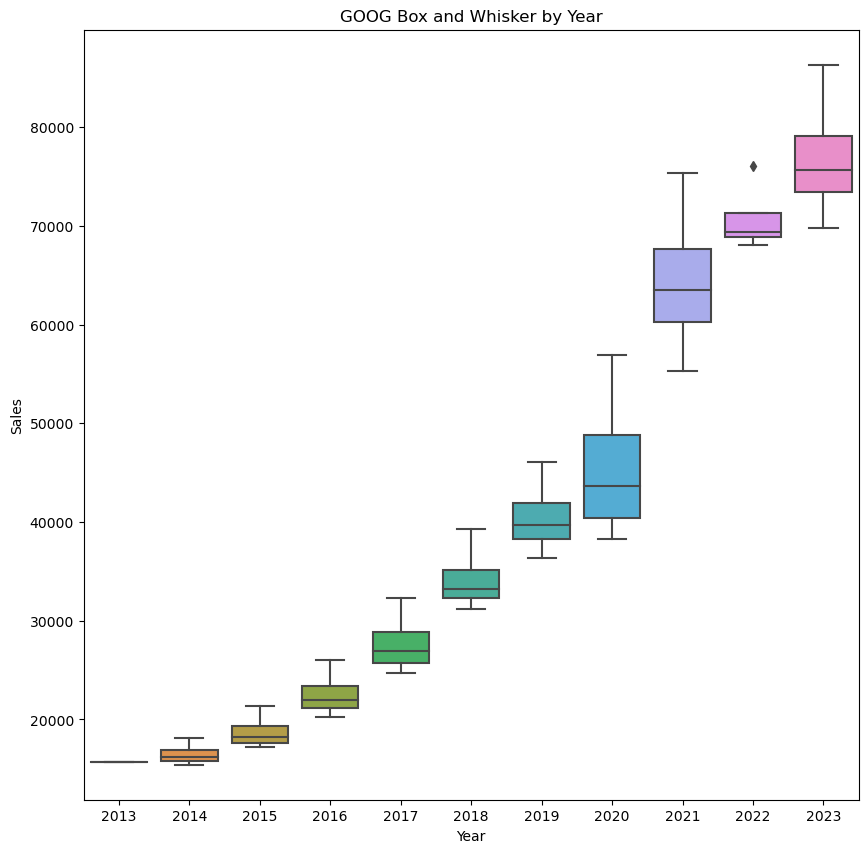

In [159]:
sn.boxplot(x='Year',y='Sales', data = goog).set(title = 'GOOG Box and Whisker by Year')

In [77]:
avgperqtr = goog[['Quarter', 'Sales']].groupby('Quarter').mean().reset_index()



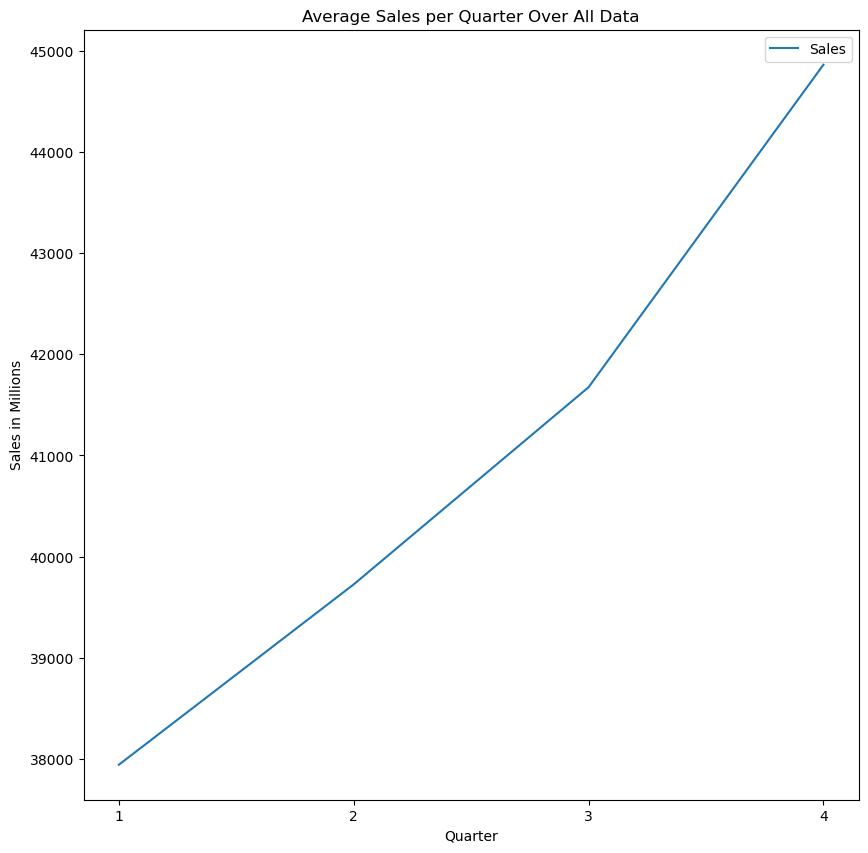

In [125]:
avgperqtr.plot('Quarter','Sales')
plt.ylabel('Sales in Millions')
plt.title('Average Sales per Quarter Over All Data')
plt.xticks(goog.Quarter.unique())
plt.show()

In [4]:
goog1 = pd.DataFrame(goog, columns=['Year','Quarter','Sales'])

In [5]:
goog2  = goog1[goog1['Year']>2013]

In [81]:
dictyear = {}
saleslist = []
for year in goog1['Year'].unique():
    #print(year)
    #byyear = goog1[goog1['Year'] == year]
    #saleslist = saleslist.append(byyear.Sales) 
    dictyear[year] = list(goog1[goog1['Year'] == year].Sales)
    
    
    

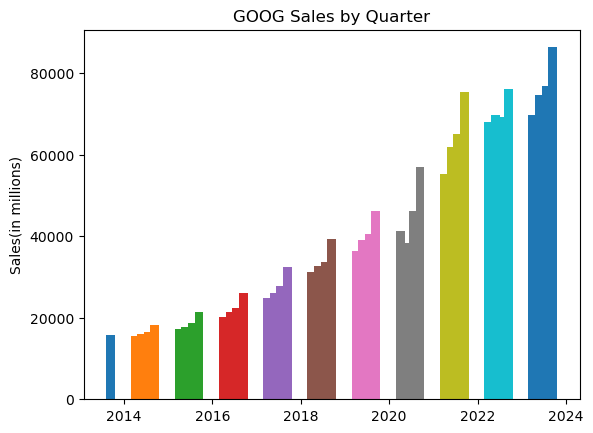

In [83]:
#adopted from https://medium.com/@BetterEverything/graph-quarterly-data-with-python-6f38bcc6b7fe
for year, data in dictyear.items():
    quarters = list(goog1.loc[(goog1['Year'] == year)].Quarter)
    x_coordinates = [year + 0.15 * q for q in quarters]
    #print(x_coordinates, data)
    plt.bar(x_coordinates,data,width=0.2,align='edge')
plt.title('GOOG Sales by Quarter')
plt.ylabel('Sales(in millions)')

#plt.xticks(labels=[np.unique(goog1['Year'].values)], ticks = [])
#print(plt.xticks())
plt.show()

In [116]:
goog.set_index('Date', inplace=True)

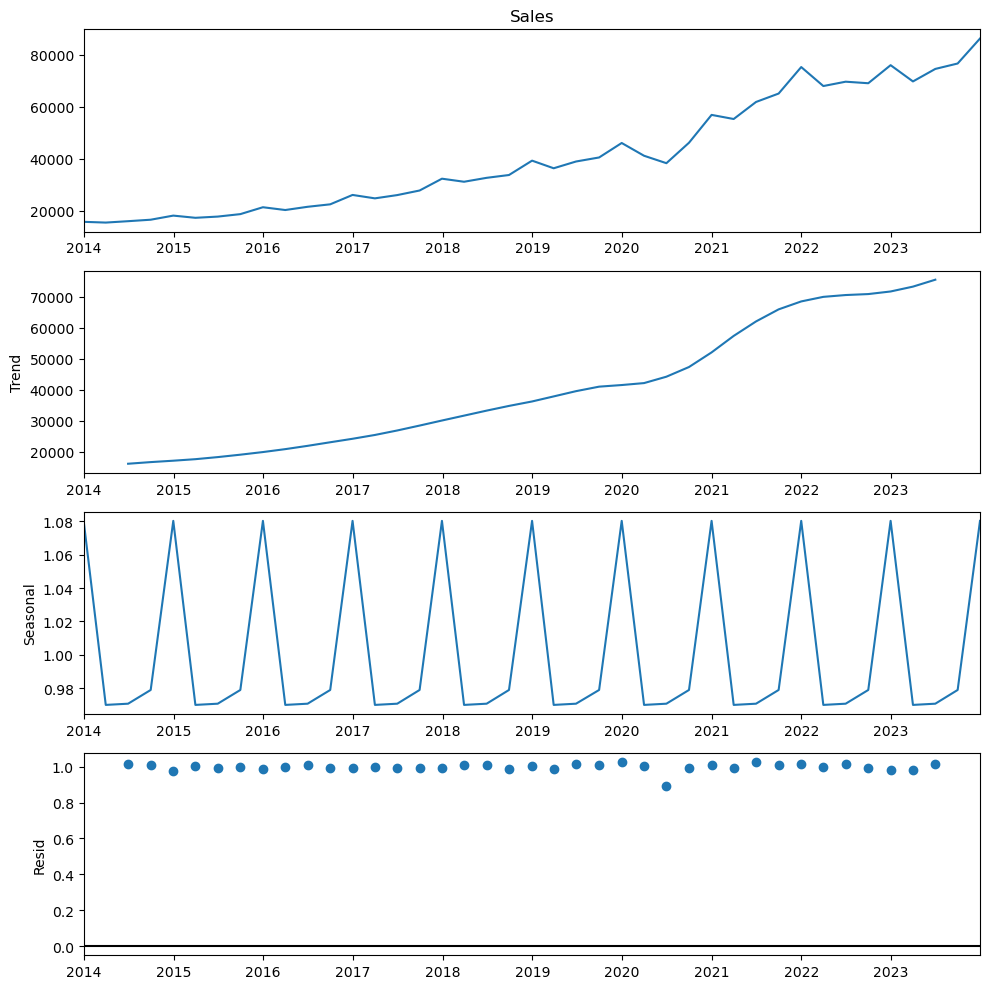

In [117]:

#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Sales'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

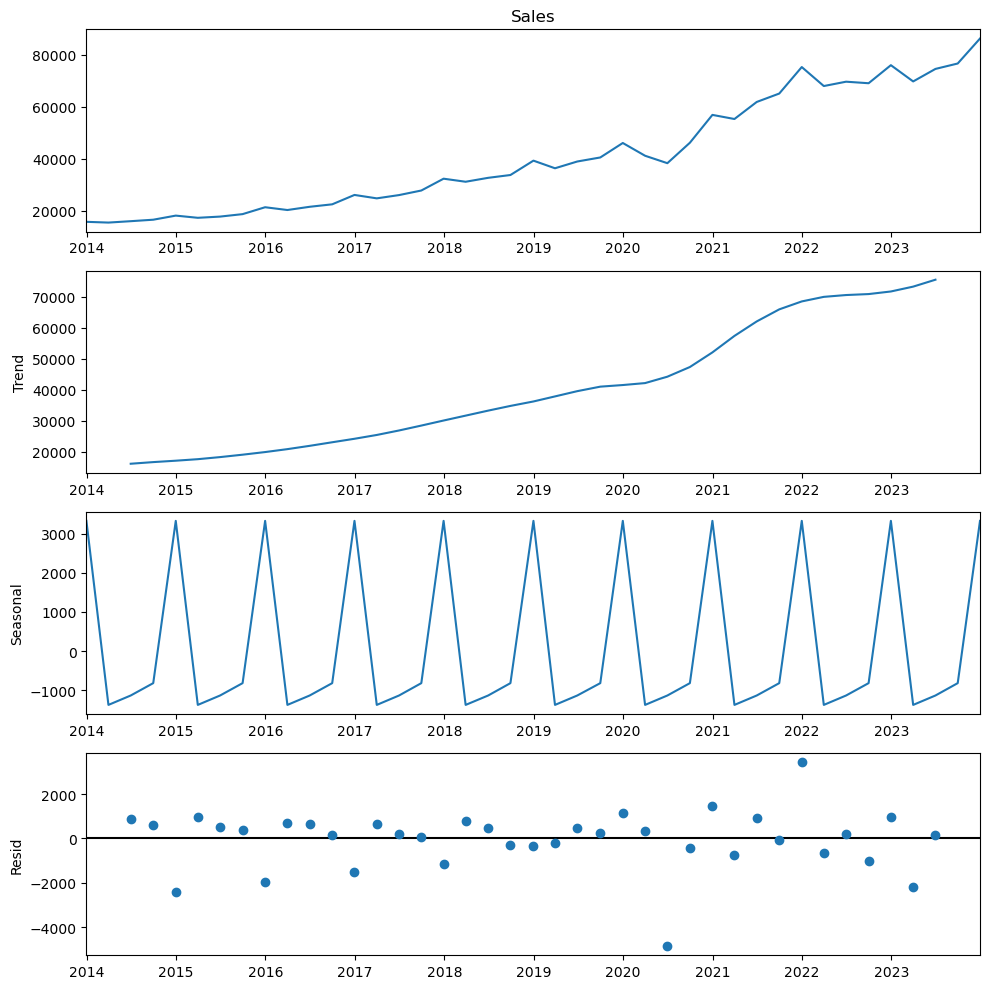

In [118]:
result = seasonal_decompose(goog['Sales'],model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
#plt.title('Time Series Decomposition of Sales')
plt.show()

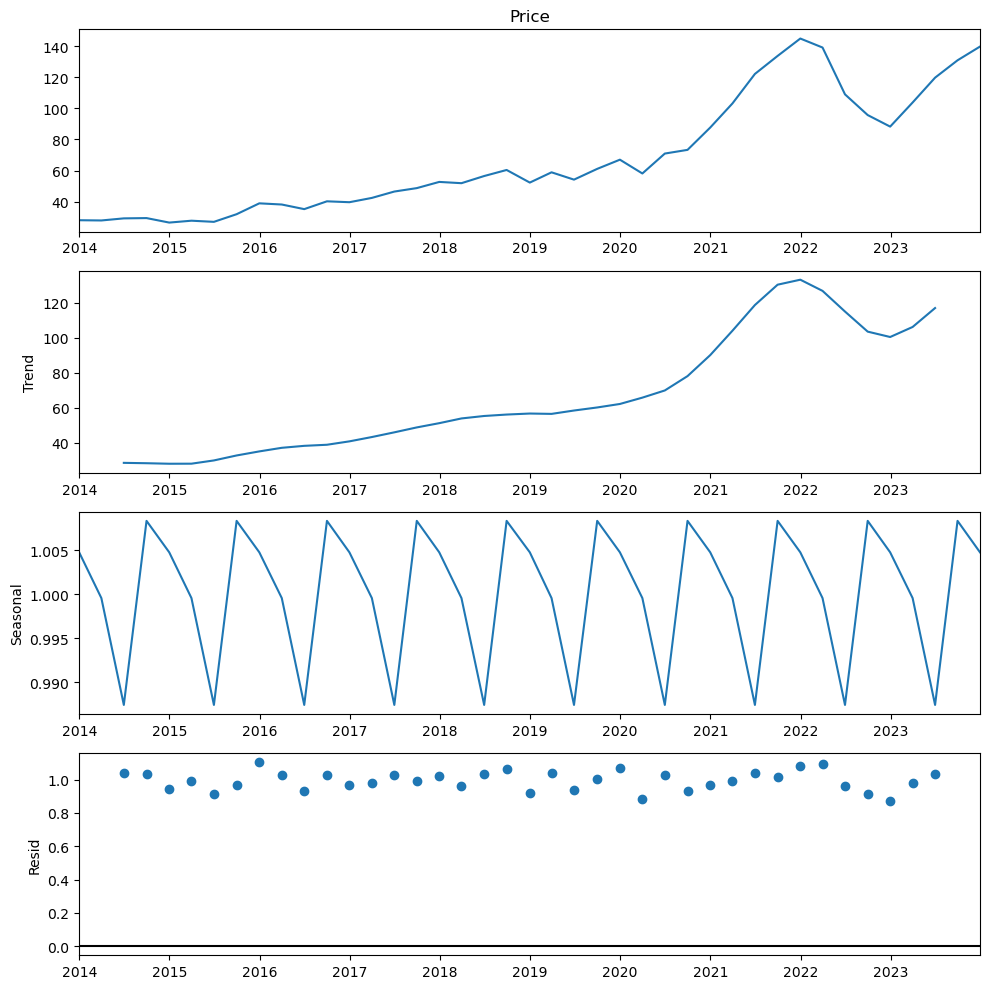

In [121]:
#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Price'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

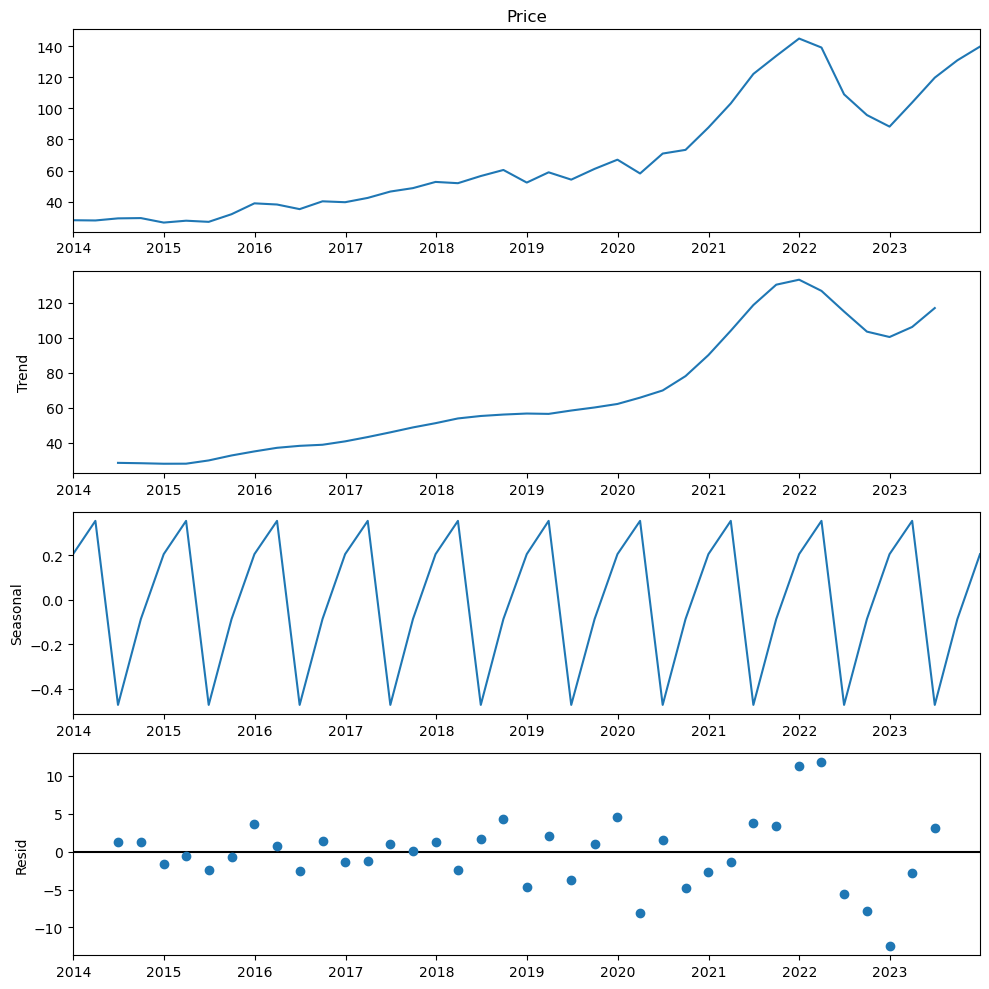

In [122]:
result = seasonal_decompose(goog['Price'], model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

In [ ]:
df.set_index('Month',inplace=True)
df.index=pd.to_datetime(df.index)
#drop null values
df.dropna(inplace=True)
df.plot()

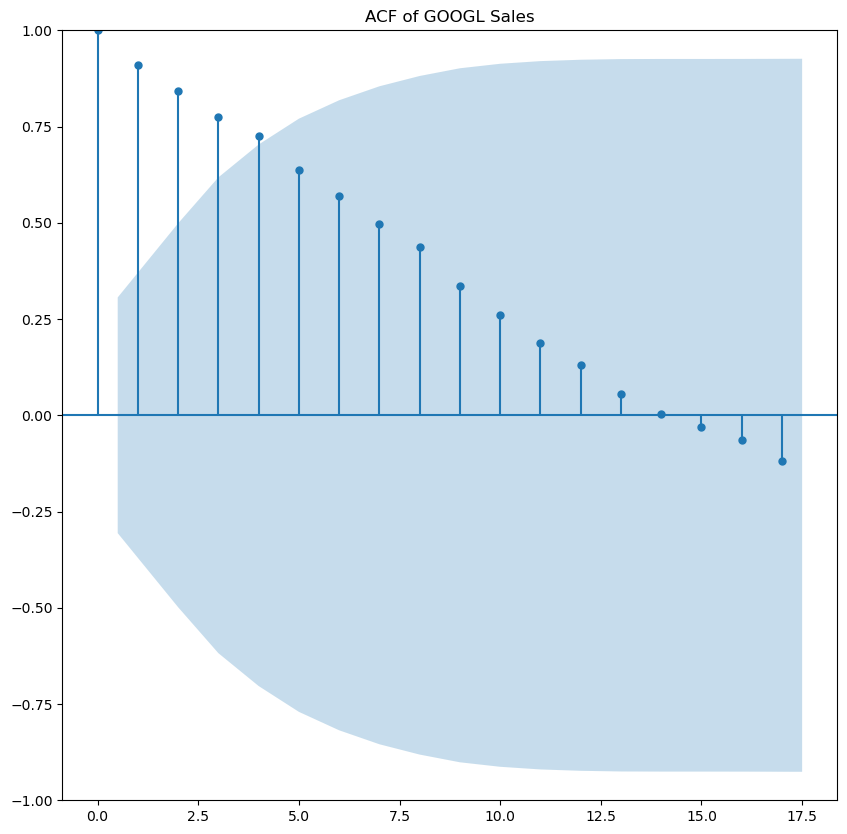

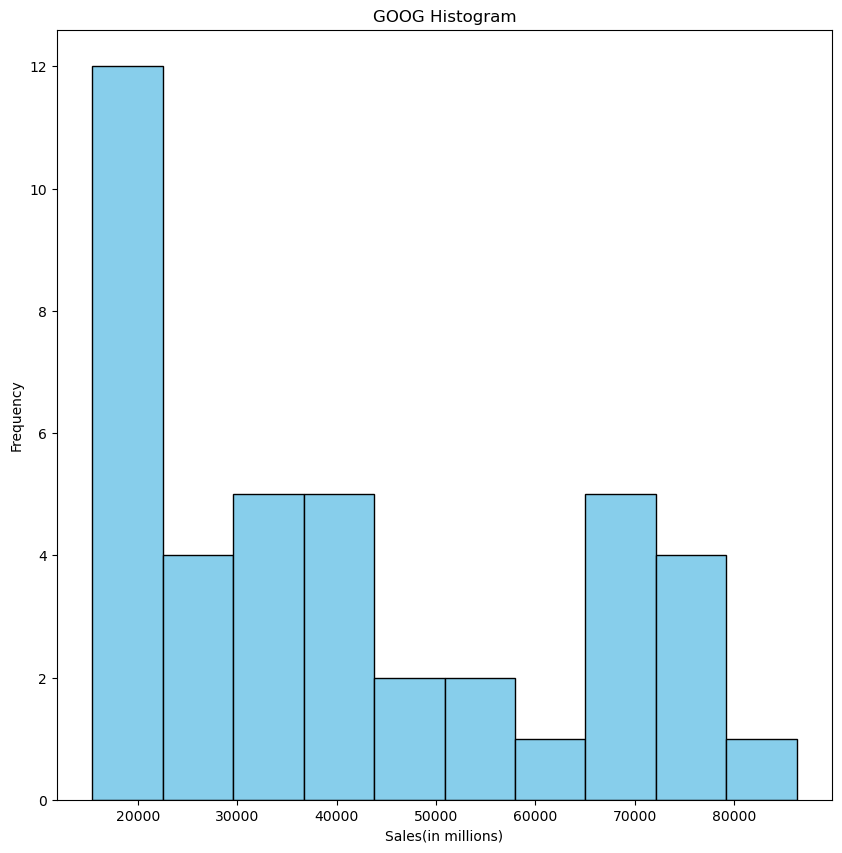

In [101]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_acf(decomp['Sales'], title='ACF of GOOGL Sales')
pyplot.show()

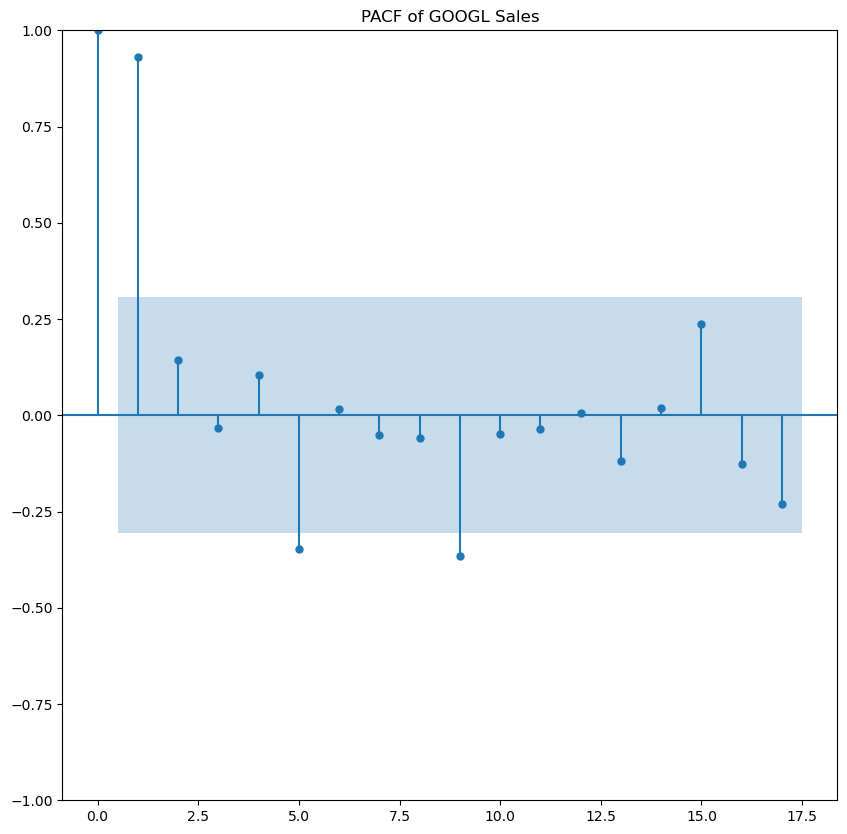

In [129]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_pacf(decomp['Sales'], title='PACF of GOOGL Sales')
pyplot.show()


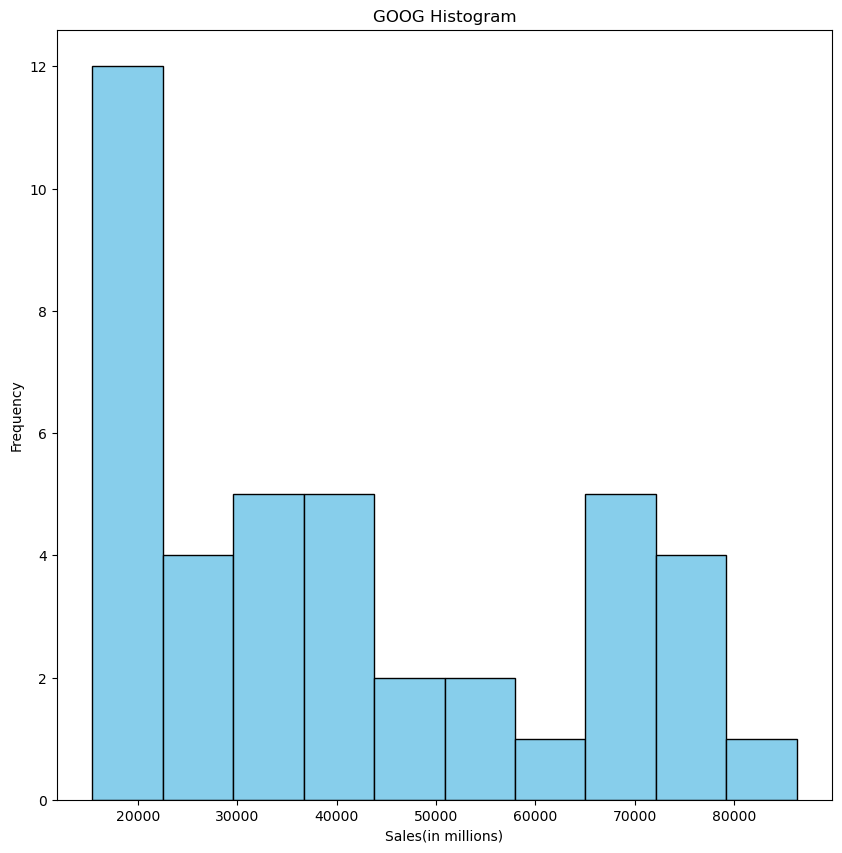

In [130]:
plt.hist(decomp, color='skyblue', edgecolor='black')
plt.xlabel('Sales(in millions)')
plt.ylabel('Frequency')
plt.title('GOOG Histogram')
pyplot.show()

In [123]:
# statistical test
result = adfuller(goog['Sales'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 1.242373
p-value: 0.996266
Critical Values:
	1%: -3.661
	5%: -2.961
	10%: -2.619


In [124]:
# statistical test
result = adfuller(goog['Price'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -0.190971
p-value: 0.939589
Critical Values:
	1%: -3.627
	5%: -2.946
	10%: -2.612


## GOOG Conclusion

In [ ]:
#The null hypothesis of the ADF test is the time series is Non Stationary.  We conclude GOOG is Non Stationary since the test 
#statistic is larger than the critical values.

Description of Time series (is it stationary, are there any trends, seasonality etc)

For GOOGL, you can see there is clearly a trend higher in both price and sales over the last 10 years. There does appear to be seasonality mainly in the 4th quarter of the year.  The additive model seems to be more appropriate for the Sales and Stock price data as the residuals in each case appear like white noise in the additive model but have more of a pattern in the multiplicative model. This is shown in both time series decomposition charts. 

The null hypothesis of the ADF test is the time series is Non Stationary. We conclude GOOG is Non Stationary both when looking at Sales and Price since the test statistic is larger than the critical values. 


GOOGL does show autocorrelation out to about 5 lags.  

### Analysis of TSLA Stock and Fundamentals over last 10 years

In [137]:
#goog = pd.read_csv('GOOGL.csv',header=0, index_col=0, parse_dates=True,squeeze=True)
goog = pd.read_csv('TSLA.csv')

In [138]:
goog.columns


Index(['Date', 'Sales', 'FreeCashFlow', 'Cash', 'Long Term Debt', 'Price'], dtype='object')

In [139]:
goog['Date'] = pd.to_datetime(goog['Date'], format='%m/%d/%Y')
goog['Year'] = goog['Date'].dt.year
goog['Quarter'] = goog['Date'].dt.quarter

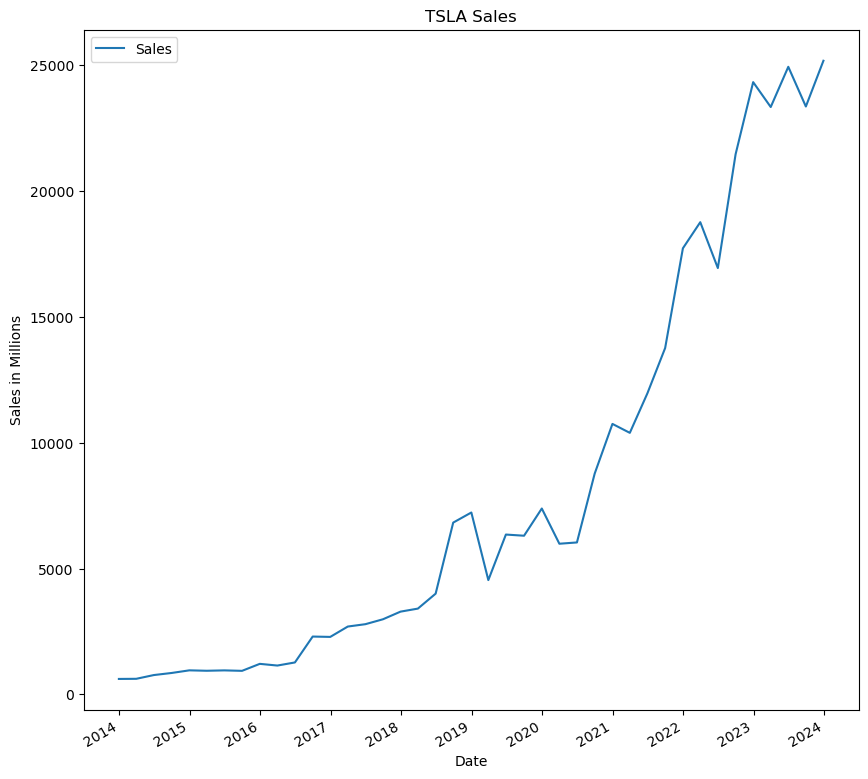

In [140]:
goog.plot('Date', 'Sales')
plt.title('TSLA Sales')
plt.ylabel('Sales in Millions')
plt.show()


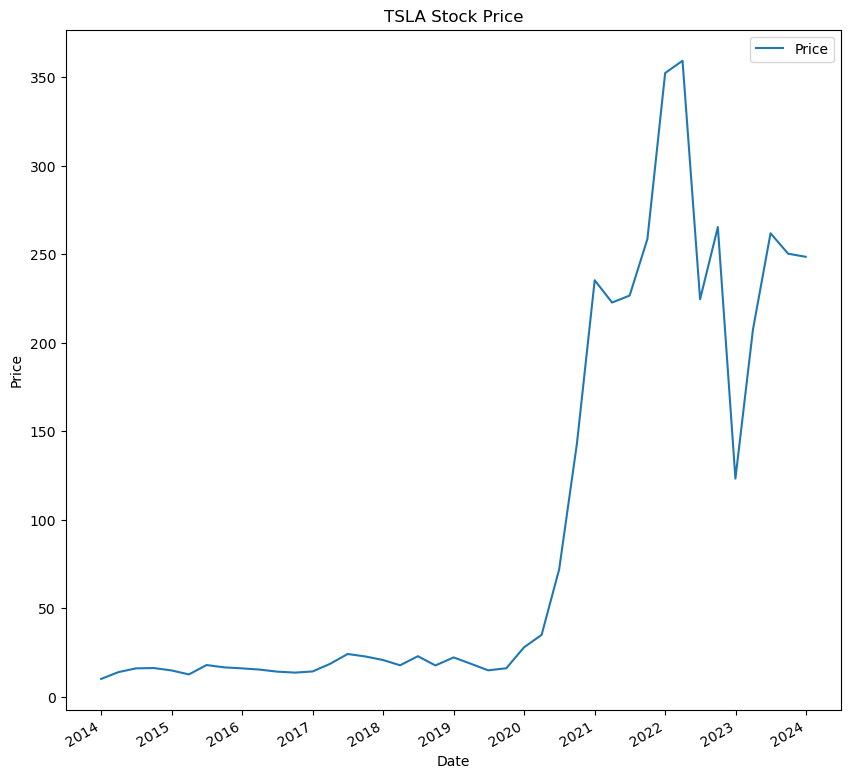

In [141]:
goog.plot('Date','Price')
plt.title('TSLA Stock Price')
plt.ylabel('Price')
plt.show()

Text(0.5, 1.0, 'TSLA Stock Price vs Sales')

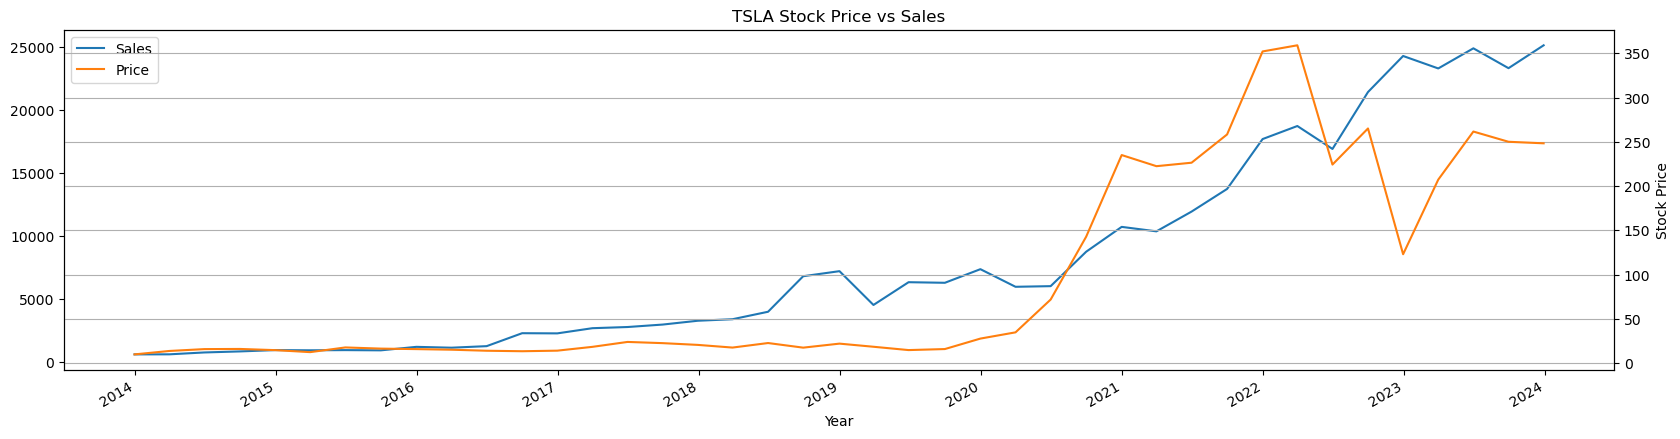

In [142]:
goog.loc[:,['Date','Sales','Price']].plot(x = 'Date',secondary_y=['Price'], xlabel = 'Year', ylabel = 'Stock Price',sharex = True,mark_right=False, figsize = (20,5), grid=True)
plt.title('TSLA Stock Price vs Sales')

[Text(0.5, 1.0, 'TSLA Box and Whisker by Year')]

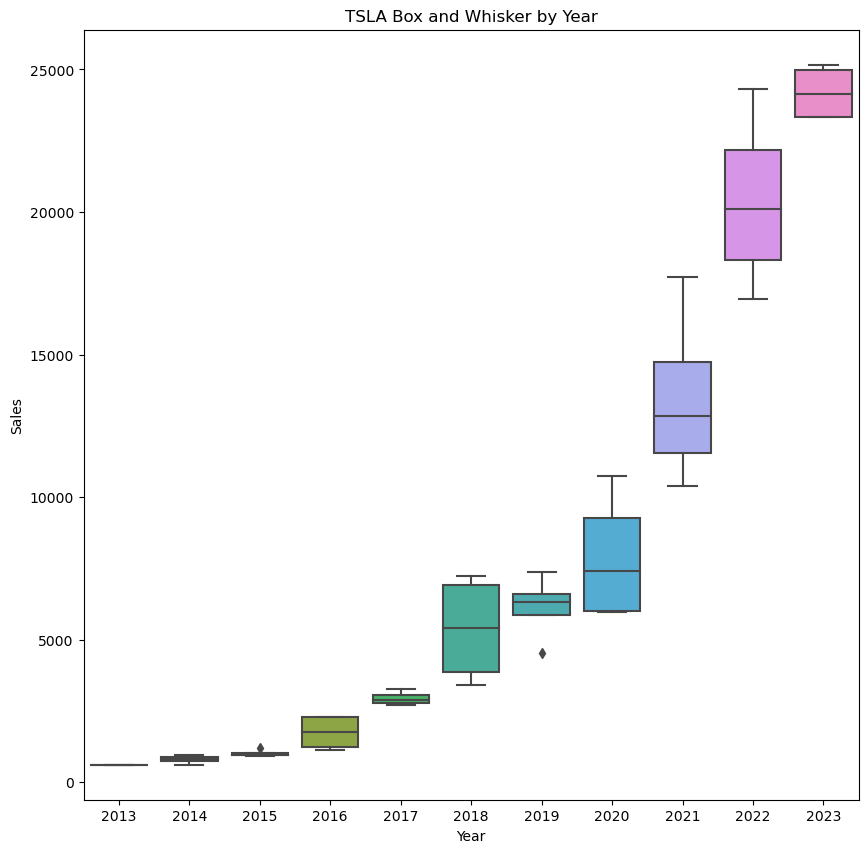

In [143]:
sn.boxplot(x='Year',y='Sales', data = goog).set(title = 'TSLA Box and Whisker by Year')

In [144]:
avgperqtr = goog[['Quarter', 'Sales']].groupby('Quarter').mean().reset_index()



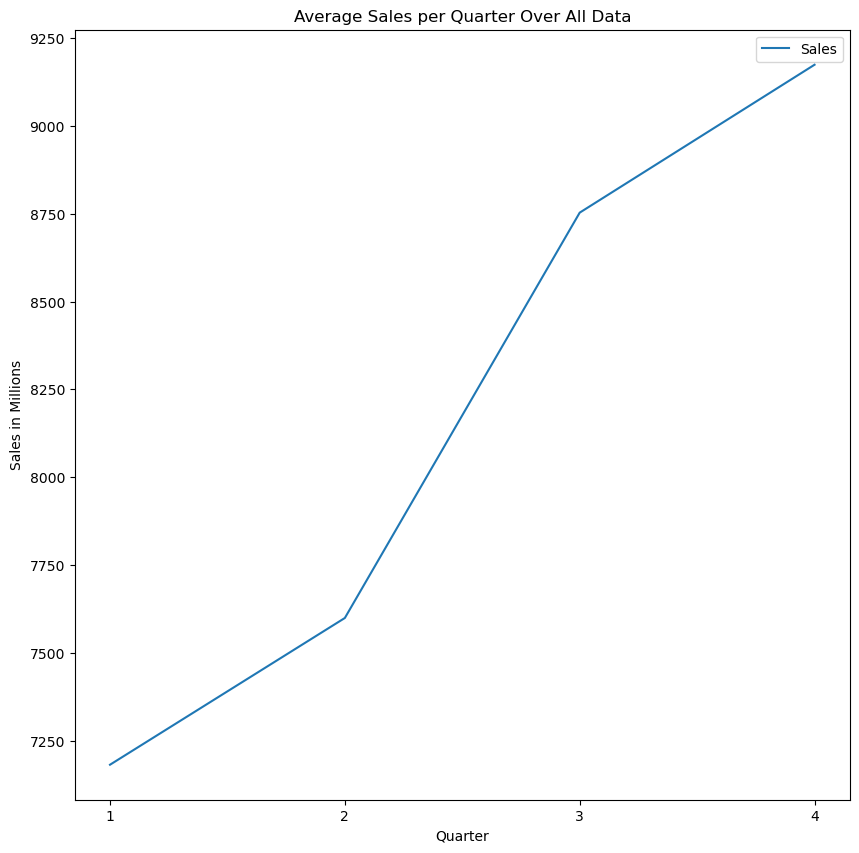

In [145]:
avgperqtr.plot('Quarter','Sales')
plt.ylabel('Sales in Millions')
plt.title('Average Sales per Quarter Over All Data')
plt.xticks(goog.Quarter.unique())
plt.show()

In [146]:
goog1 = pd.DataFrame(goog, columns=['Year','Quarter','Sales'])

In [147]:
dictyear = {}
saleslist = []
for year in goog1['Year'].unique():
    #print(year)
    #byyear = goog1[goog1['Year'] == year]
    #saleslist = saleslist.append(byyear.Sales) 
    dictyear[year] = list(goog1[goog1['Year'] == year].Sales)
    
    
    

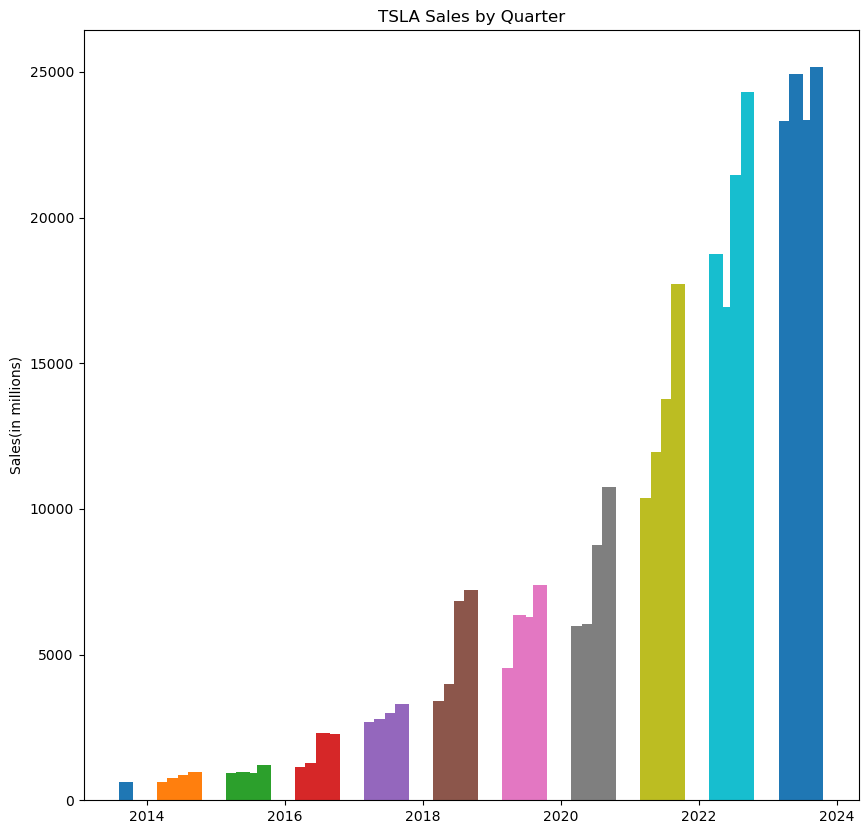

In [148]:
#adopted from https://medium.com/@BetterEverything/graph-quarterly-data-with-python-6f38bcc6b7fe
for year, data in dictyear.items():
    quarters = list(goog1.loc[(goog1['Year'] == year)].Quarter)
    x_coordinates = [year + 0.15 * q for q in quarters]
    #print(x_coordinates, data)
    plt.bar(x_coordinates,data,width=0.2,align='edge')
plt.title('TSLA Sales by Quarter')
plt.ylabel('Sales(in millions)')

#plt.xticks(labels=[np.unique(goog1['Year'].values)], ticks = [])
#print(plt.xticks())
plt.show()

In [149]:
goog.set_index('Date', inplace=True)

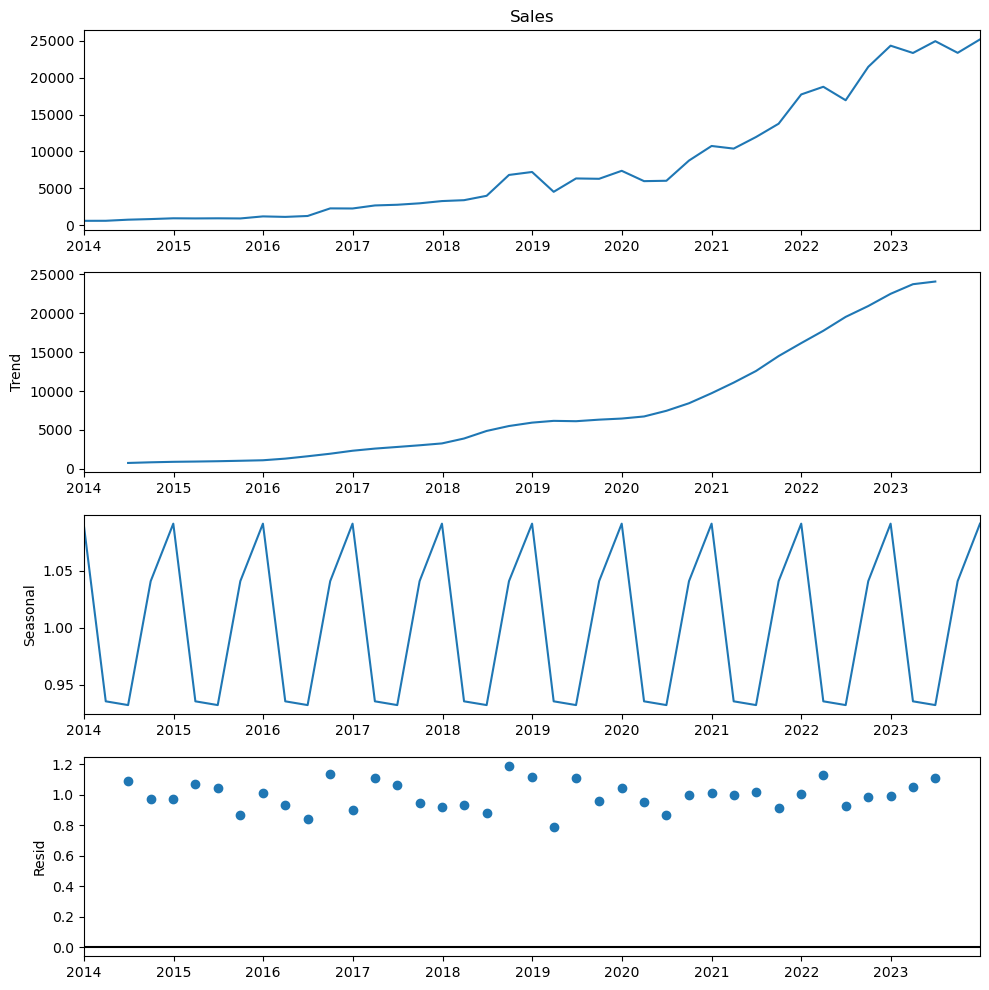

In [150]:

#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Sales'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

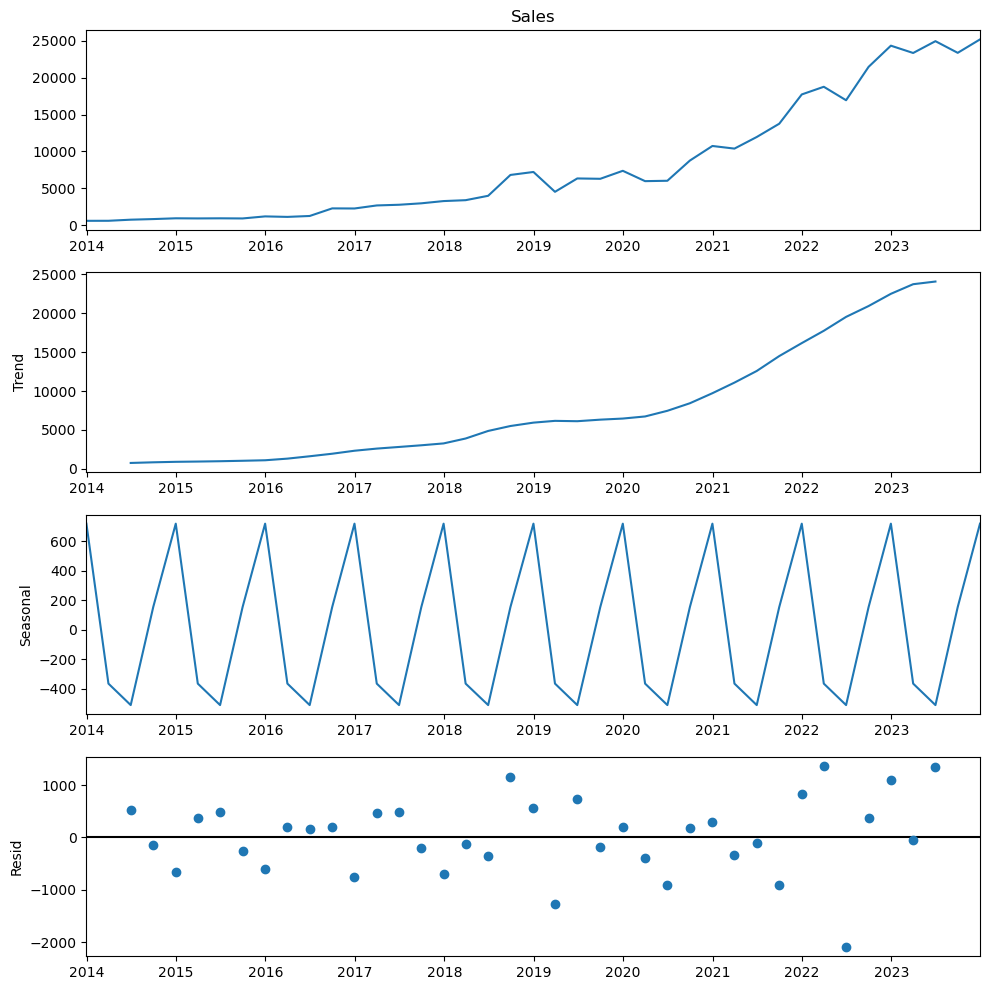

In [151]:
result = seasonal_decompose(goog['Sales'],model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
#plt.title('Time Series Decomposition of Sales')
plt.show()

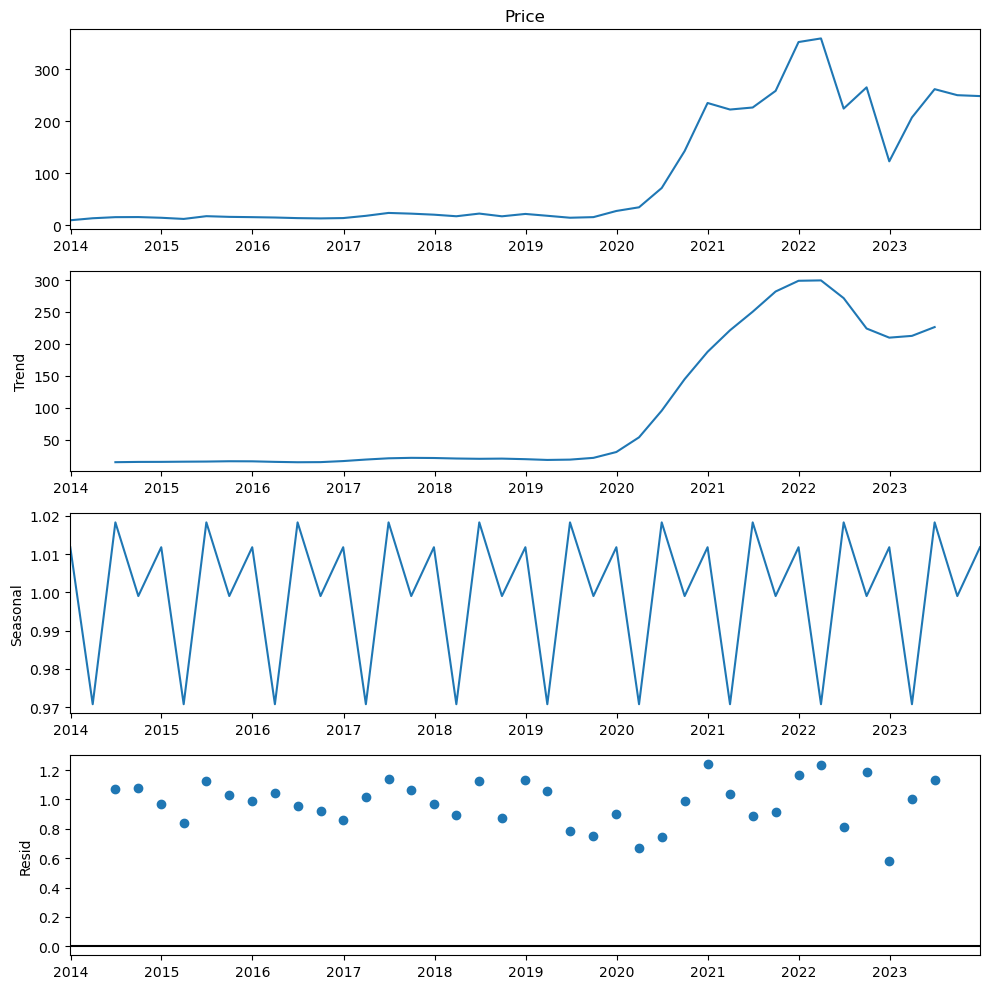

In [152]:
#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Price'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

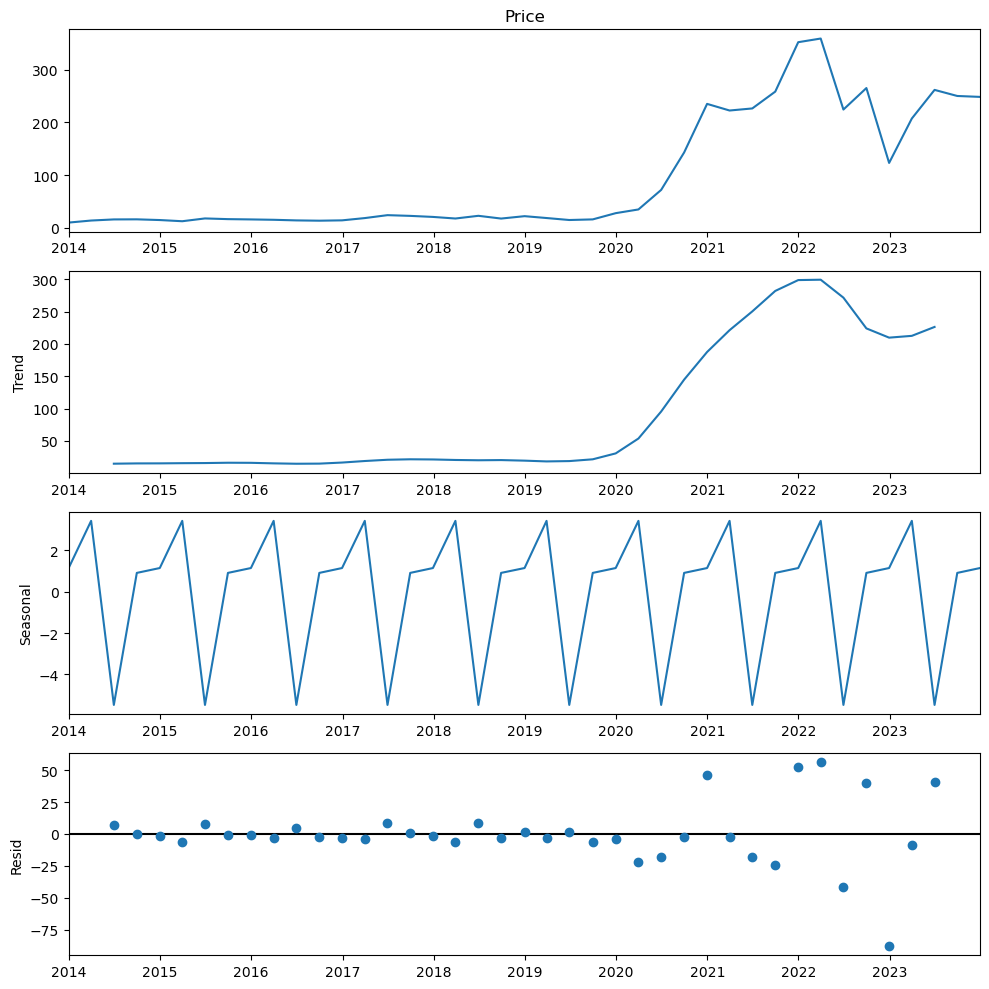

In [153]:
result = seasonal_decompose(goog['Price'], model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

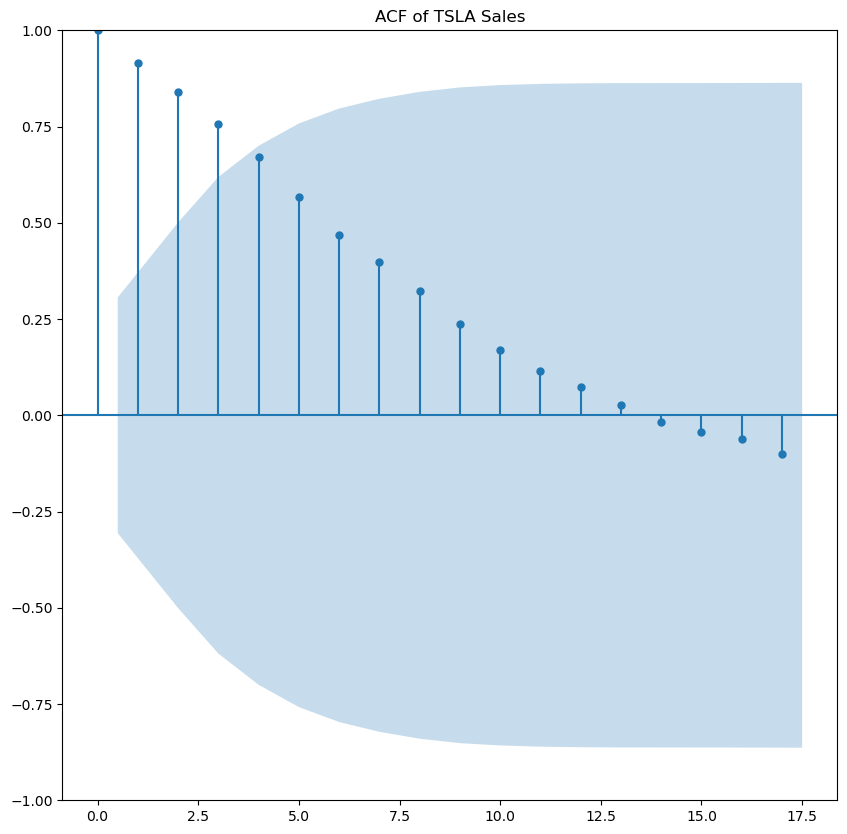

In [157]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_acf(goog['Sales'], title='ACF of TSLA Sales')
pyplot.show()

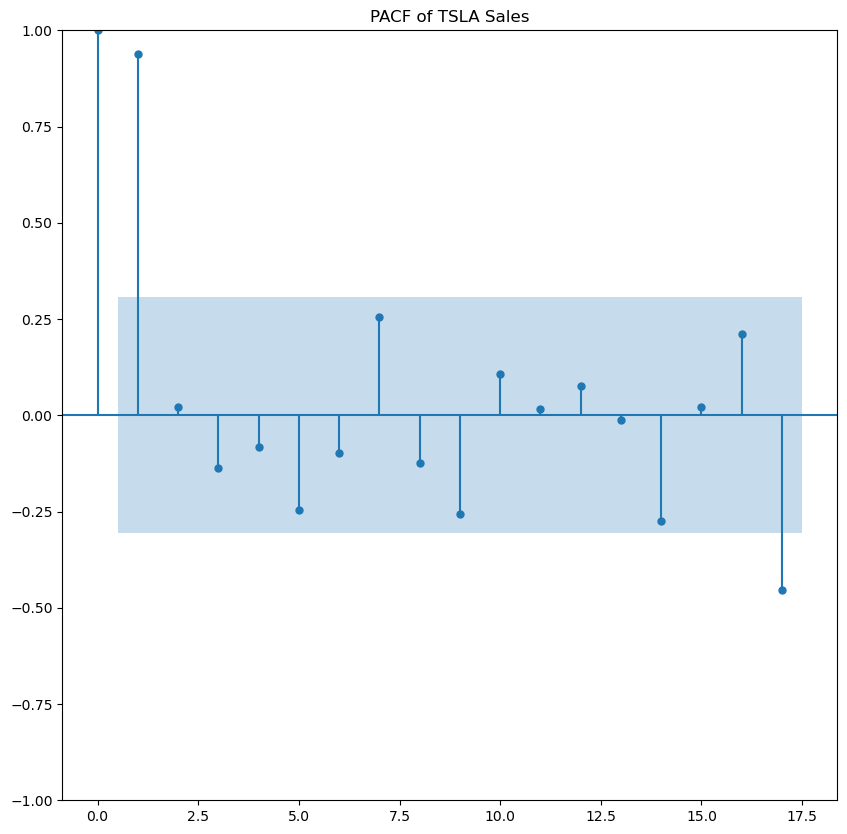

In [159]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_pacf(goog['Sales'], title='PACF of TSLA Sales')
pyplot.show()


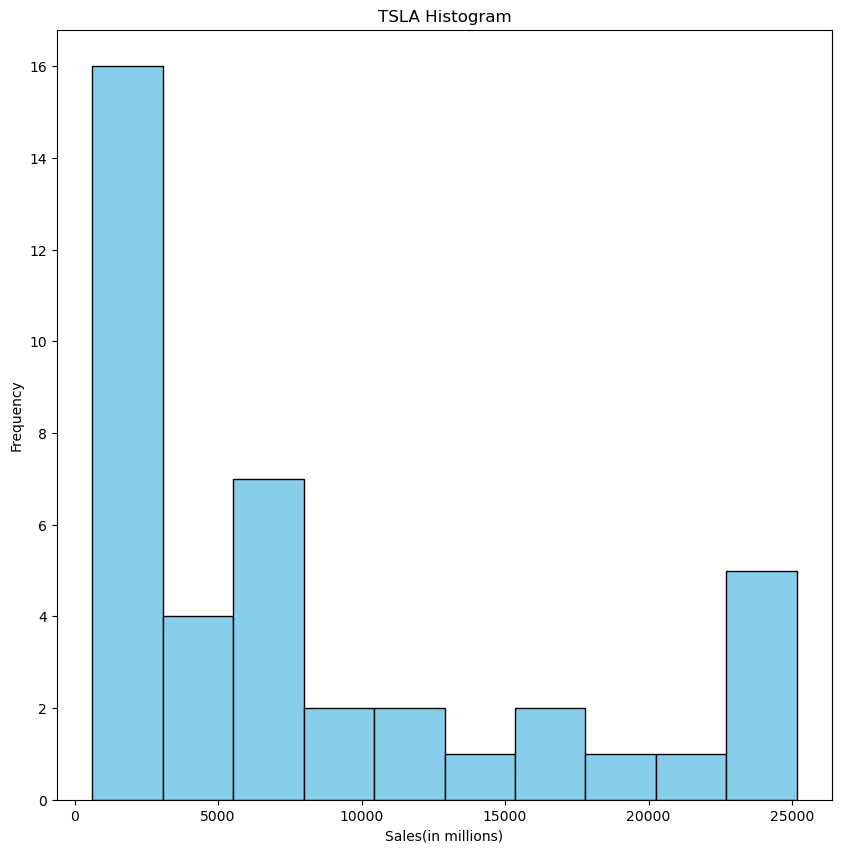

In [162]:
plt.hist(goog['Sales'], color='skyblue', edgecolor='black')
plt.xlabel('Sales(in millions)')
plt.ylabel('Frequency')
plt.title('TSLA Histogram')
pyplot.show()

In [163]:
# statistical test
result = adfuller(goog['Sales'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 0.939400
p-value: 0.993584
Critical Values:
	1%: -3.646
	5%: -2.954
	10%: -2.616


In [164]:
# statistical test
result = adfuller(goog['Price'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -1.382937
p-value: 0.590428
Critical Values:
	1%: -3.670
	5%: -2.964
	10%: -2.621


## TSLA Conclusion

Description of Time series (is it stationary, are there any trends, seasonality etc)

For TSLA, you can see there is clearly a trend higher in both price and sales over the last 10 years. More recently, TSLA's stock price is declining on concerns about low priced EV's coming from China as well as general concern of the amount of TSLA's manufacturing exposure. There does appear to be seasonality mainly in the 4th quarter of the year.  The additive model seems to be more appropriate for the Sales data while the multiplicative and additive approach have similar patterns in the residuals. It's unclear to me which model is best for the stock price data since the residuals in both models appear to have somewhat of a pattern. This is shown in both time series decomposition charts. 

The null hypothesis of the ADF test is the time series is Non Stationary. We conclude TSLA is Non Stationary both when looking at Sales and Price since the test statistic is larger than the critical values. 


TSLA does show autocorrelation out to about 4 lags.

### Analysis of AMZN Stock and Fundamentals over last 10 years

In [170]:
#goog = pd.read_csv('GOOGL.csv',header=0, index_col=0, parse_dates=True,squeeze=True)
goog = pd.read_csv('AMZN.csv')

In [171]:
goog.columns


Index(['Date', 'Sales', 'FreeCashFlow', 'Cash', 'Long Term Debt', 'Price'], dtype='object')

In [172]:
goog['Date'] = pd.to_datetime(goog['Date'], format='%m/%d/%Y')
goog['Year'] = goog['Date'].dt.year
goog['Quarter'] = goog['Date'].dt.quarter

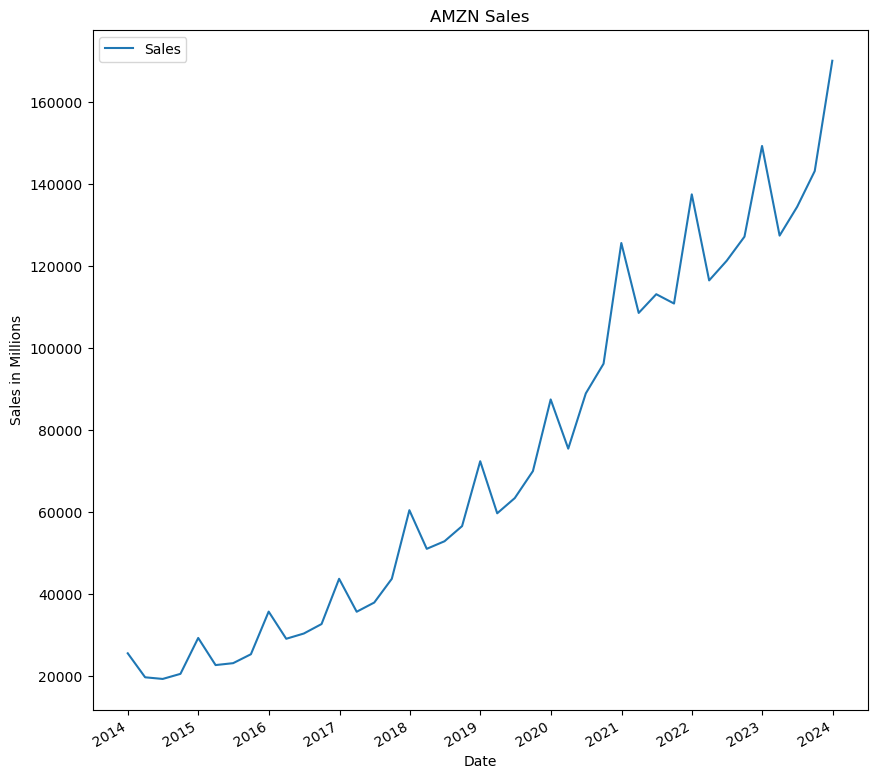

In [173]:
goog.plot('Date', 'Sales')
plt.title('AMZN Sales')
plt.ylabel('Sales in Millions')
plt.show()


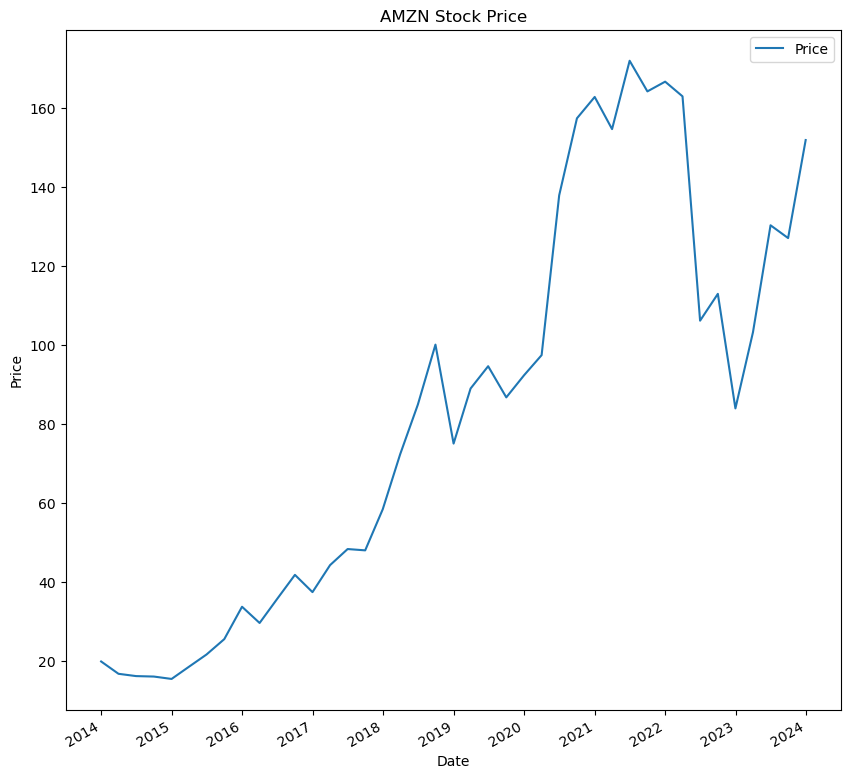

In [174]:
goog.plot('Date','Price')
plt.title('AMZN Stock Price')
plt.ylabel('Price')
plt.show()

Text(0.5, 1.0, 'AMZN Stock Price vs Sales')

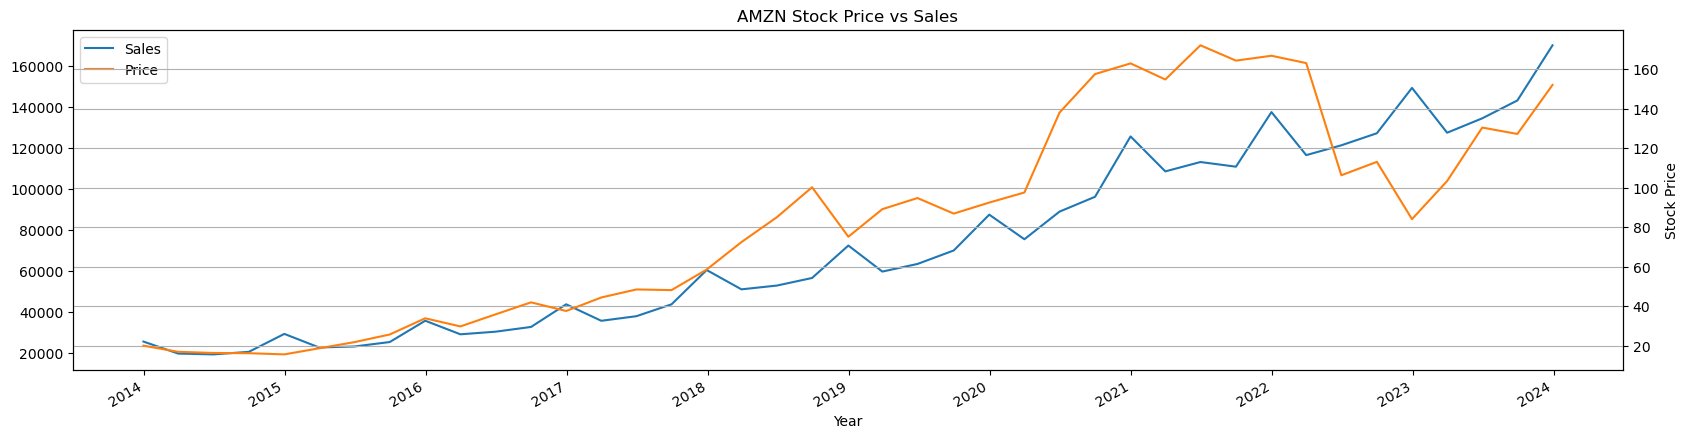

In [175]:
goog.loc[:,['Date','Sales','Price']].plot(x = 'Date',secondary_y=['Price'], xlabel = 'Year', ylabel = 'Stock Price',sharex = True,mark_right=False, figsize = (20,5), grid=True)
plt.title('AMZN Stock Price vs Sales')

[Text(0.5, 1.0, 'AMZN Box and Whisker by Year')]

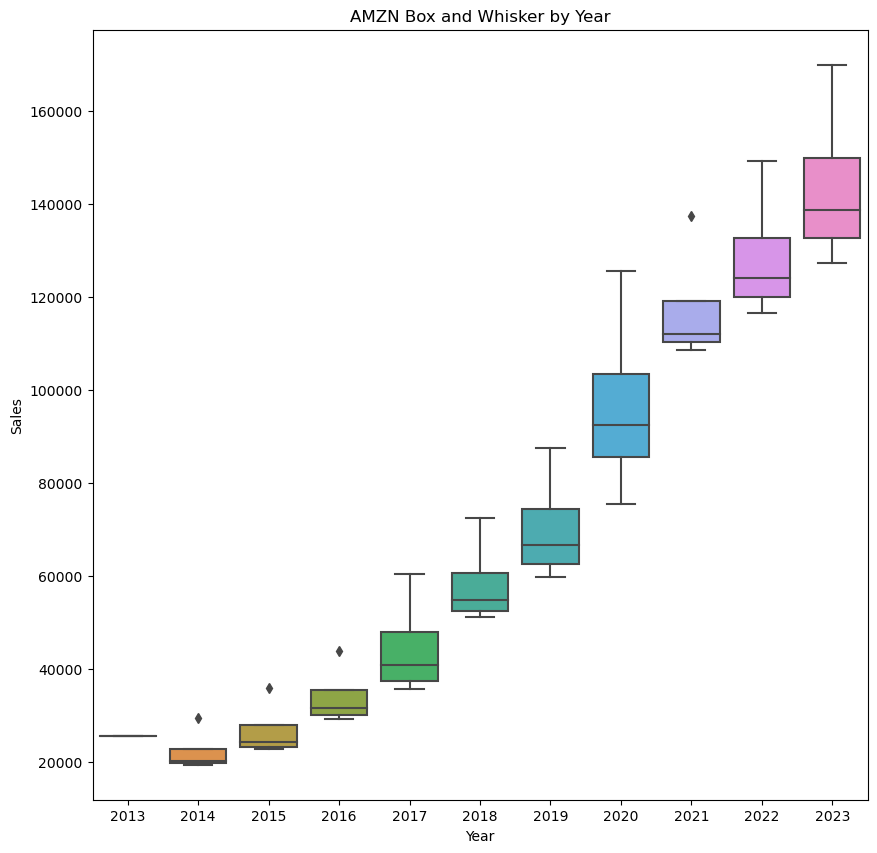

In [177]:
sn.boxplot(x='Year',y='Sales', data = goog).set(title = 'AMZN Box and Whisker by Year')

In [178]:
avgperqtr = goog[['Quarter', 'Sales']].groupby('Quarter').mean().reset_index()



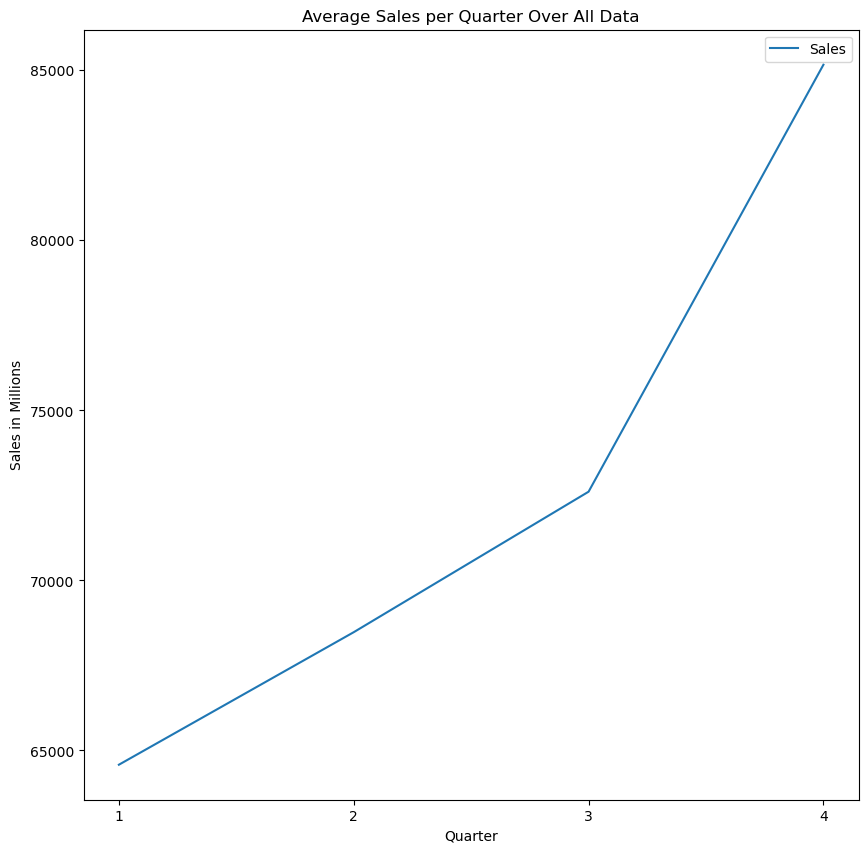

In [179]:
avgperqtr.plot('Quarter','Sales')
plt.ylabel('Sales in Millions')
plt.title('Average Sales per Quarter Over All Data')
plt.xticks(goog.Quarter.unique())
plt.show()

In [180]:
goog1 = pd.DataFrame(goog, columns=['Year','Quarter','Sales'])

In [181]:
dictyear = {}
saleslist = []
for year in goog1['Year'].unique():
    #print(year)
    #byyear = goog1[goog1['Year'] == year]
    #saleslist = saleslist.append(byyear.Sales) 
    dictyear[year] = list(goog1[goog1['Year'] == year].Sales)
    
    
    

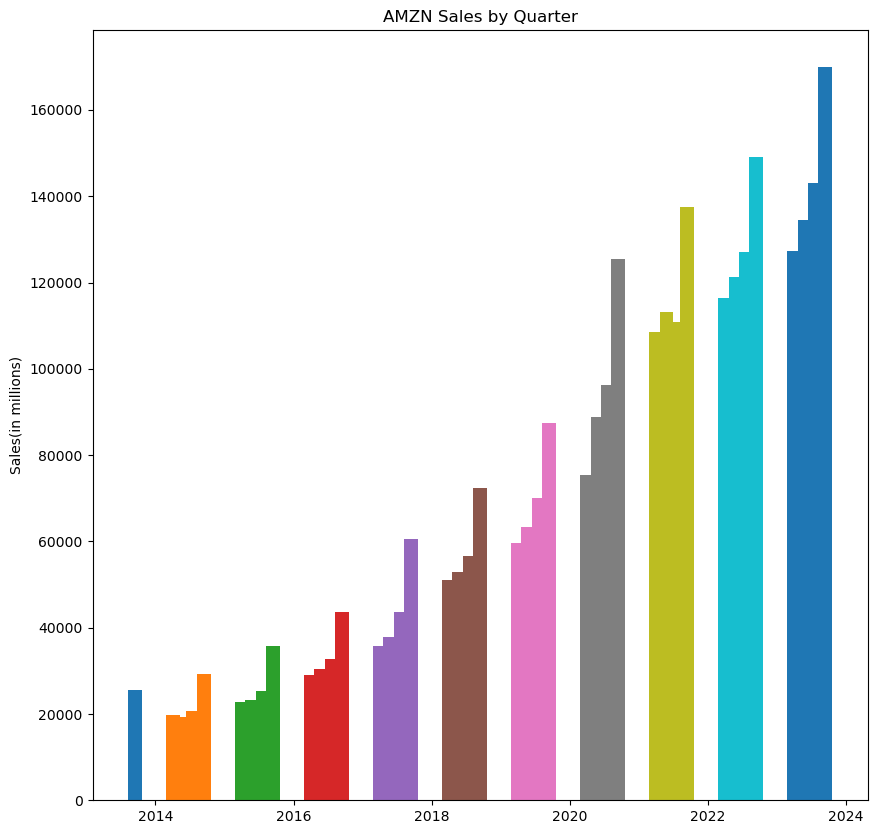

In [183]:
#adopted from https://medium.com/@BetterEverything/graph-quarterly-data-with-python-6f38bcc6b7fe
for year, data in dictyear.items():
    quarters = list(goog1.loc[(goog1['Year'] == year)].Quarter)
    x_coordinates = [year + 0.15 * q for q in quarters]
    #print(x_coordinates, data)
    plt.bar(x_coordinates,data,width=0.2,align='edge')
plt.title('AMZN Sales by Quarter')
plt.ylabel('Sales(in millions)')

#plt.xticks(labels=[np.unique(goog1['Year'].values)], ticks = [])
#print(plt.xticks())
plt.show()

In [184]:
goog.set_index('Date', inplace=True)

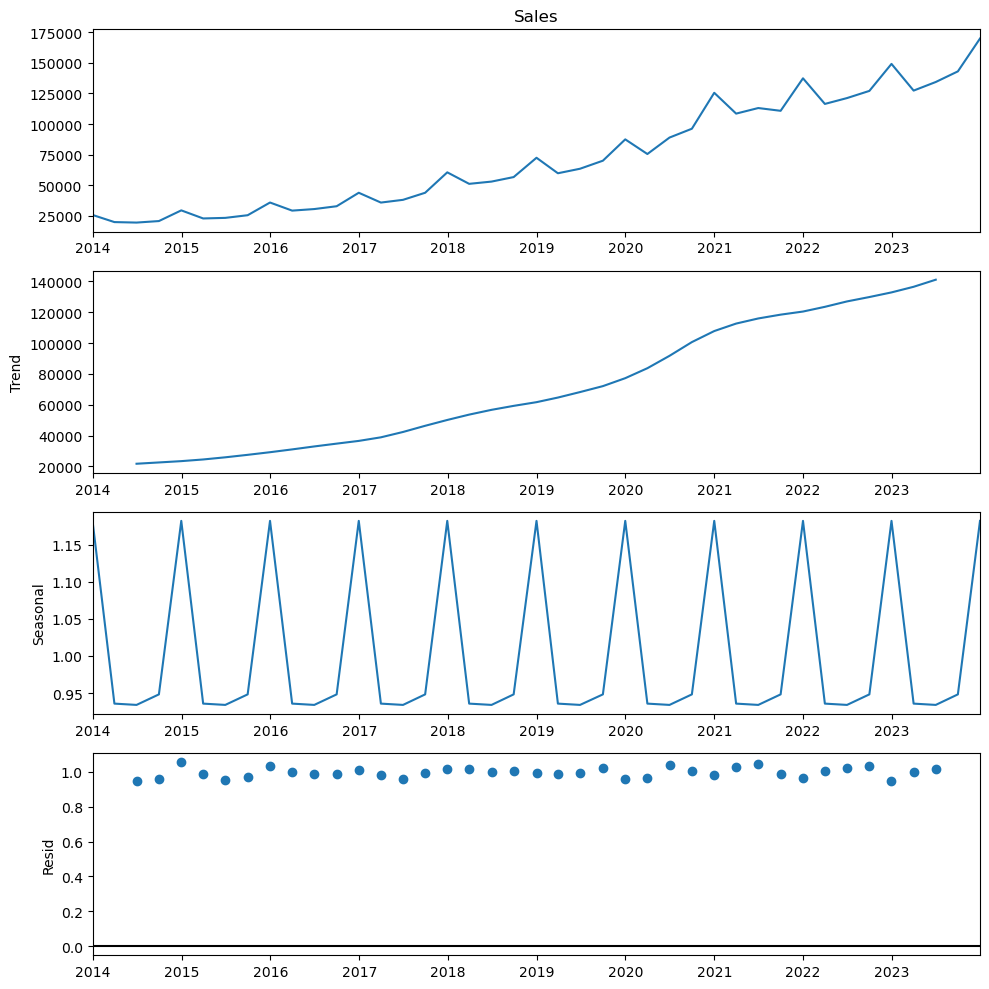

In [185]:

#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Sales'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

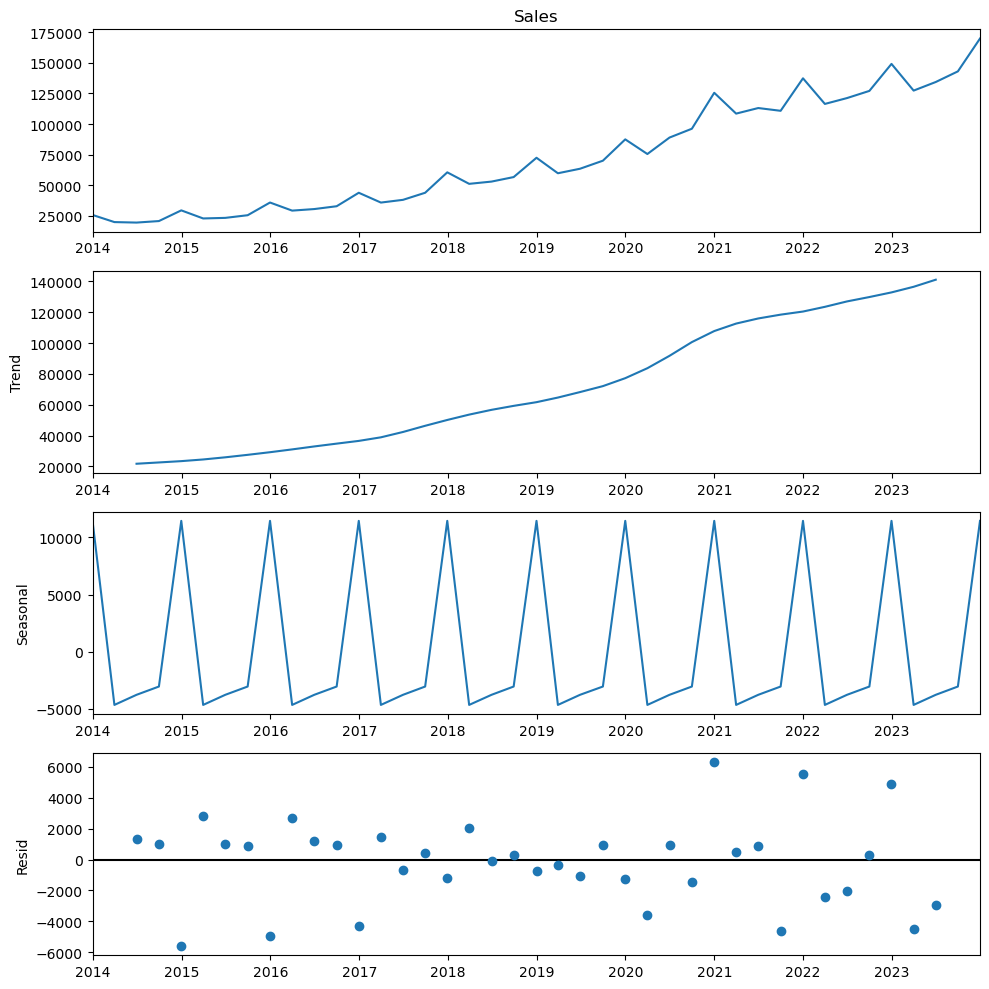

In [186]:
result = seasonal_decompose(goog['Sales'],model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
#plt.title('Time Series Decomposition of Sales')
plt.show()

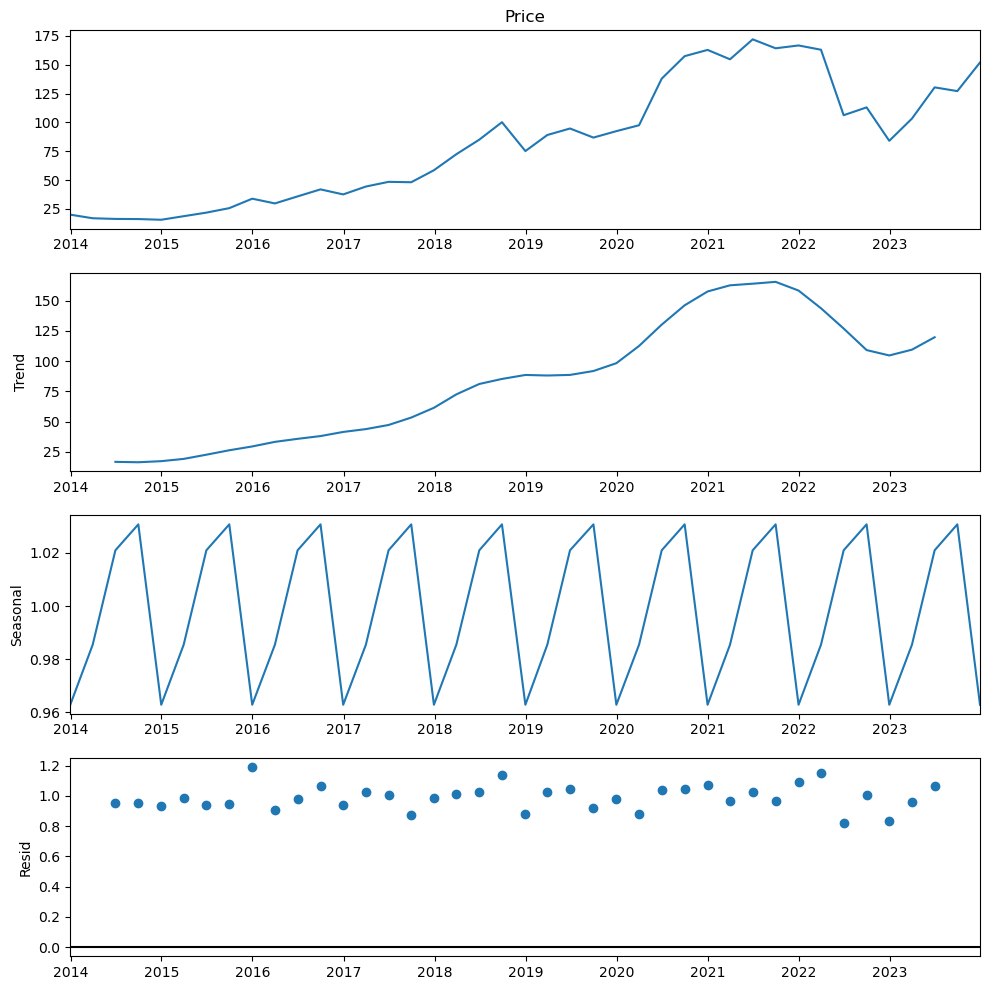

In [187]:
#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Price'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

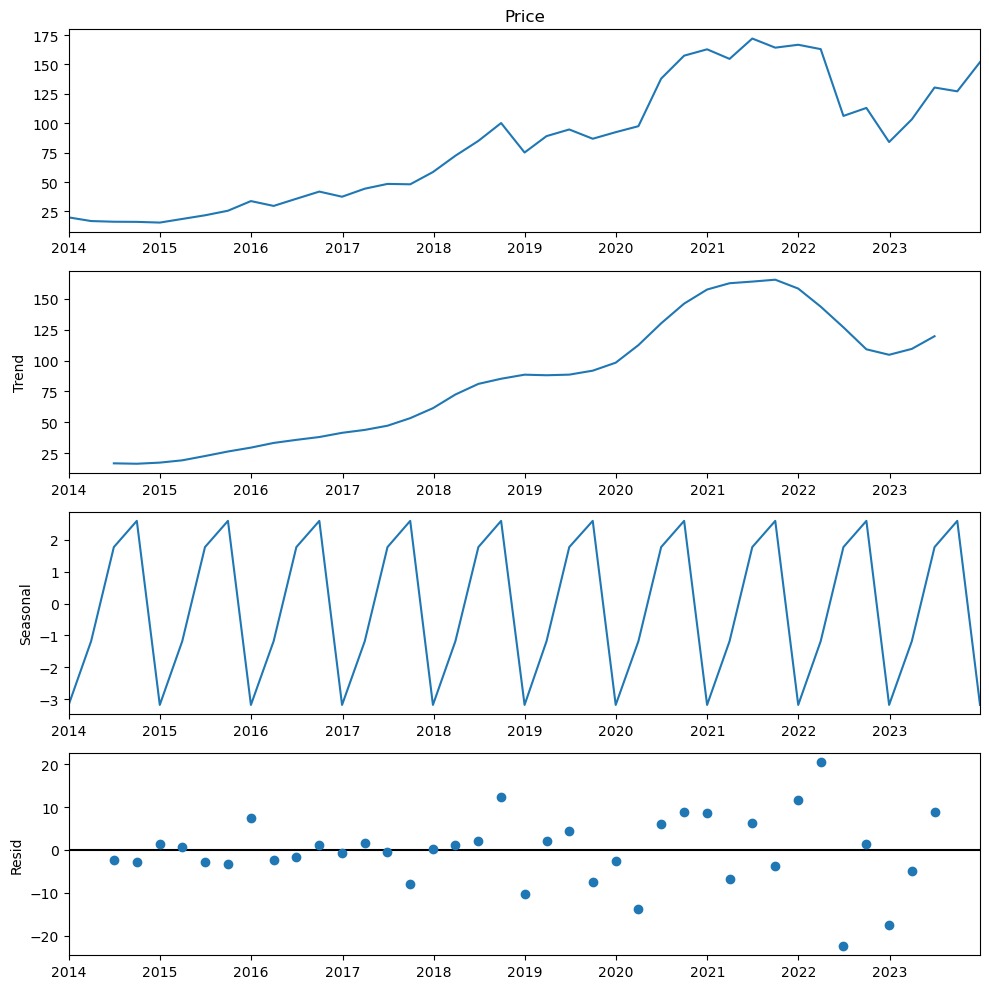

In [188]:
result = seasonal_decompose(goog['Price'], model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

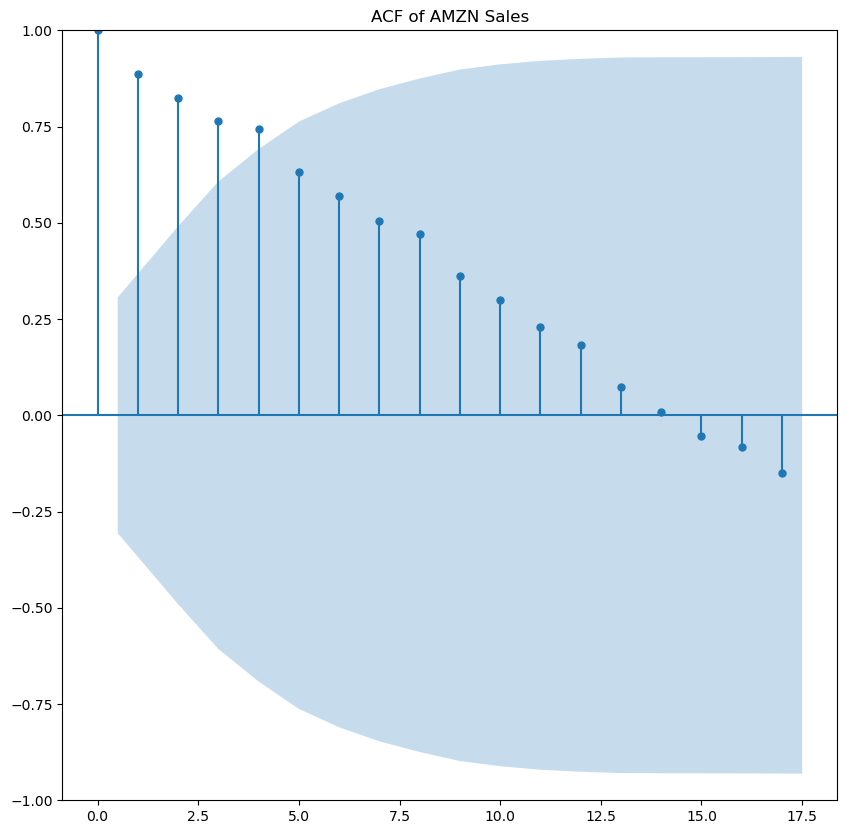

In [189]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_acf(goog['Sales'], title='ACF of AMZN Sales')
pyplot.show()

C:\Users\mdcas\anaconda_3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


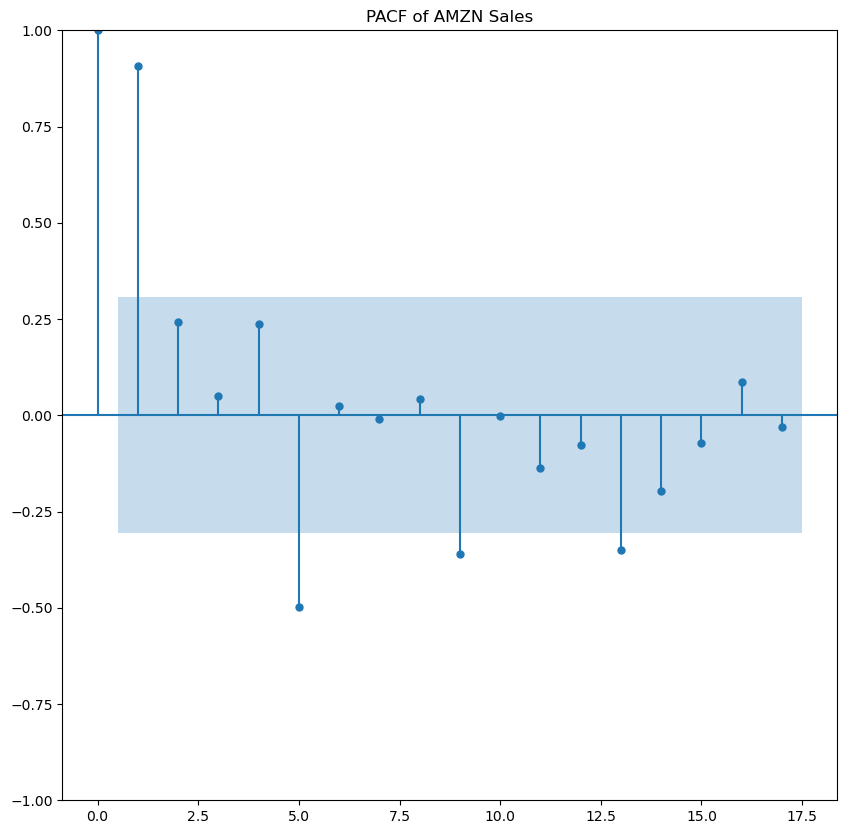

In [190]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_pacf(goog['Sales'], title='PACF of AMZN Sales')
pyplot.show()


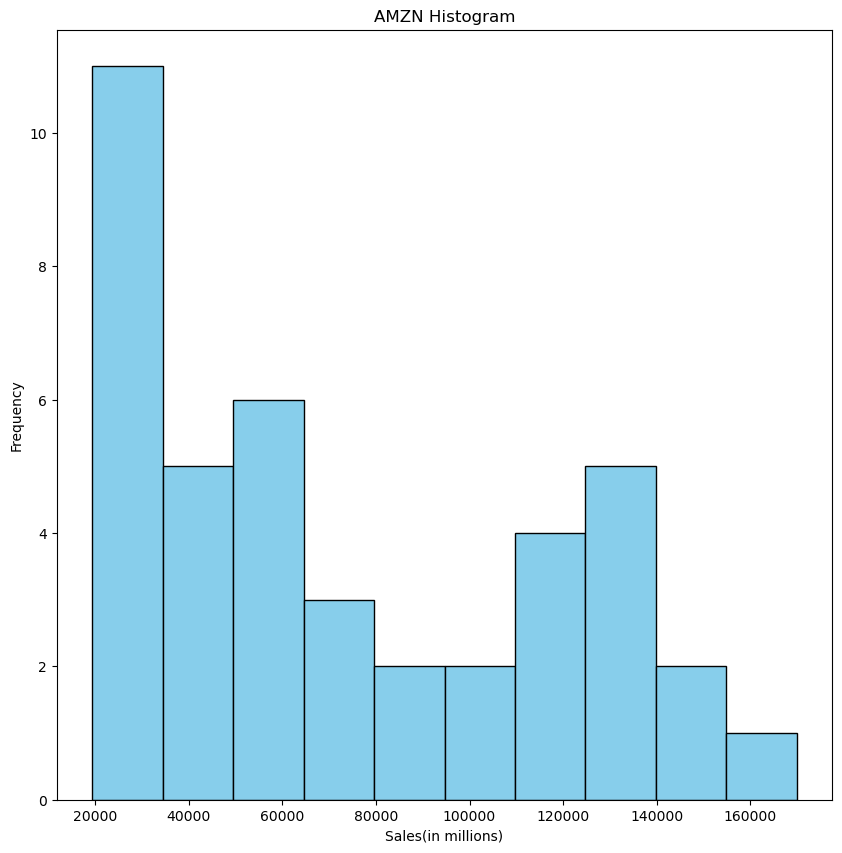

In [191]:
plt.hist(goog['Sales'], color='skyblue', edgecolor='black')
plt.xlabel('Sales(in millions)')
plt.ylabel('Frequency')
plt.title('AMZN Histogram')
pyplot.show()

In [192]:
# statistical test
result = adfuller(goog['Sales'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 1.213185
p-value: 0.996076
Critical Values:
	1%: -3.639
	5%: -2.951
	10%: -2.614


In [193]:
# statistical test
result = adfuller(goog['Price'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -0.890552
p-value: 0.791068
Critical Values:
	1%: -3.606
	5%: -2.937
	10%: -2.607


## AMZN Conclusion

Description of Time series (is it stationary, are there any trends, seasonality etc)

For AMZN, you can see there is clearly a trend higher in both price and sales over the last 10 years. It's interesting to note the higher level of volatility in Sales vs Stock price. Seems like investors might be more nervous about AMZN while Sales continue on a steady trend higher. There does appear to be seasonality mainly in the 4th quarter of the year. The additive model seems to be more appropriate for the Sales and Stock price data as the residuals in each case appear like white noise in the additive model but have more of a pattern in the multiplicative model. This is shown in both time series decomposition charts. 

The null hypothesis of the ADF test is the time series is Non Stationary. We conclude AMZN is Non Stationary both when looking at Sales and Price since the test statistic is larger than the critical values. 


AMZN does show autocorrelation out to about 5 lags.

### Analysis of AAPL Stock and Fundamentals over last 10 years

In [194]:
#goog = pd.read_csv('GOOGL.csv',header=0, index_col=0, parse_dates=True,squeeze=True)
goog = pd.read_csv('AAPL.csv')

In [195]:
goog.columns


Index(['Date', 'Sales', 'FreeCashFlow', ' Cash ', 'Long Term Debt', 'Price'], dtype='object')

In [196]:
goog['Date'] = pd.to_datetime(goog['Date'], format='%m/%d/%Y')
goog['Year'] = goog['Date'].dt.year
goog['Quarter'] = goog['Date'].dt.quarter

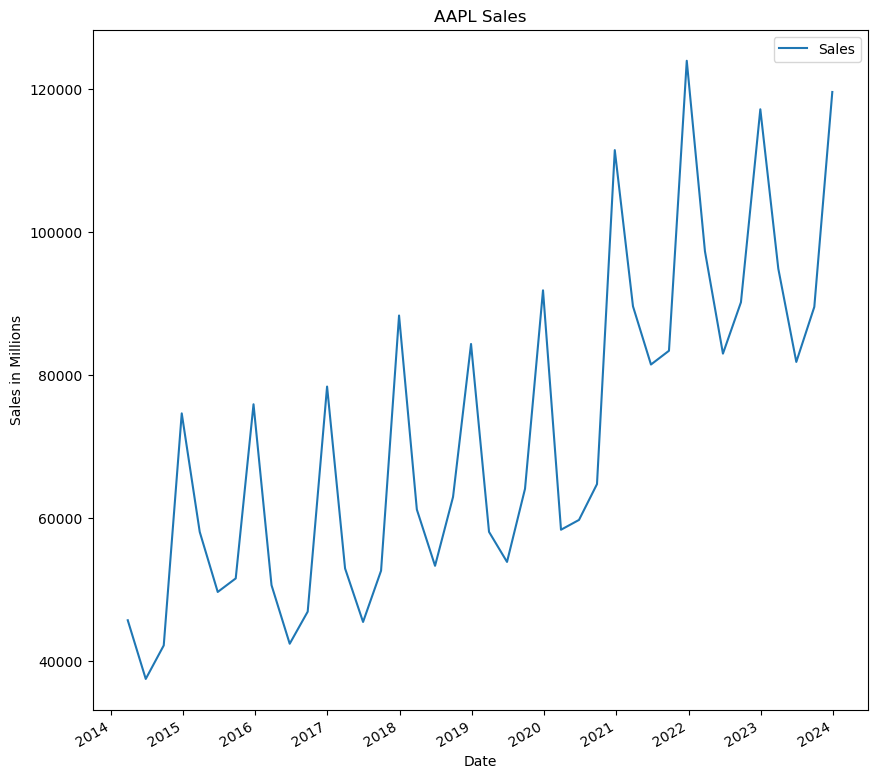

In [197]:
goog.plot('Date', 'Sales')
plt.title('AAPL Sales')
plt.ylabel('Sales in Millions')
plt.show()


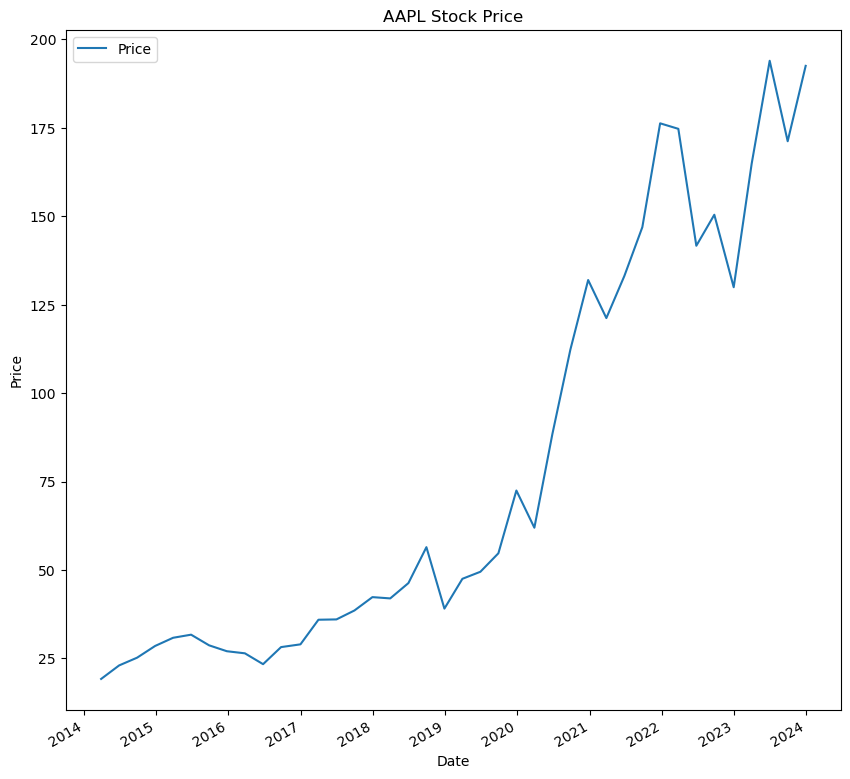

In [198]:
goog.plot('Date','Price')
plt.title('AAPL Stock Price')
plt.ylabel('Price')
plt.show()

Text(0.5, 1.0, 'AAPL Stock Price vs Sales')

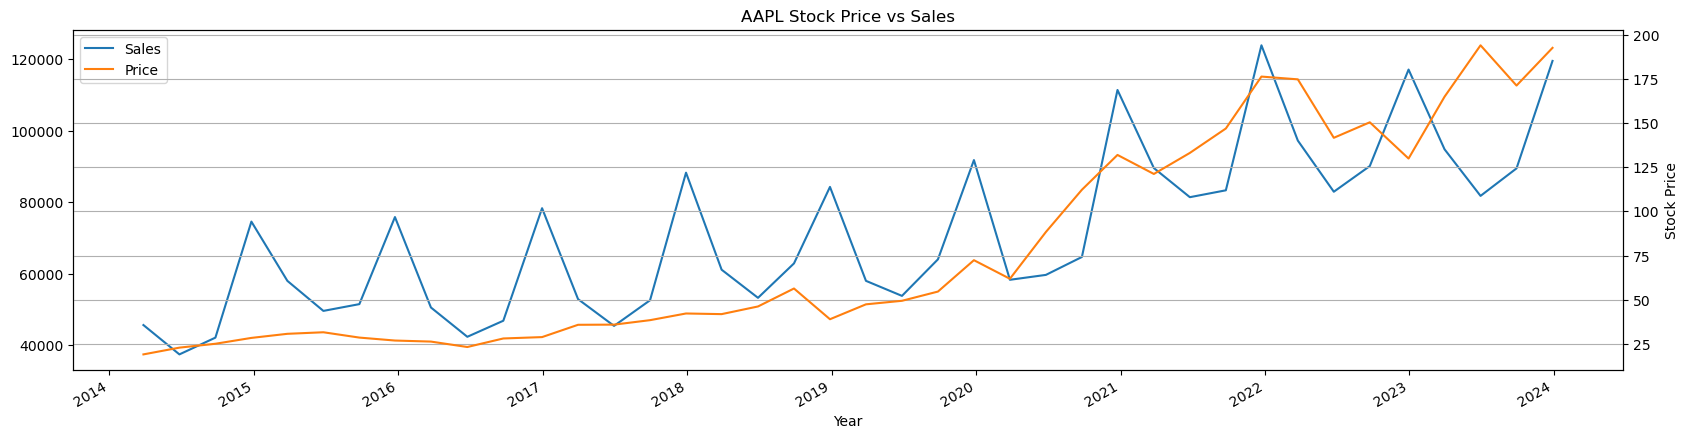

In [199]:
goog.loc[:,['Date','Sales','Price']].plot(x = 'Date',secondary_y=['Price'], xlabel = 'Year', ylabel = 'Stock Price',sharex = True,mark_right=False, figsize = (20,5), grid=True)
plt.title('AAPL Stock Price vs Sales')

[Text(0.5, 1.0, 'AAPL Box and Whisker by Year')]

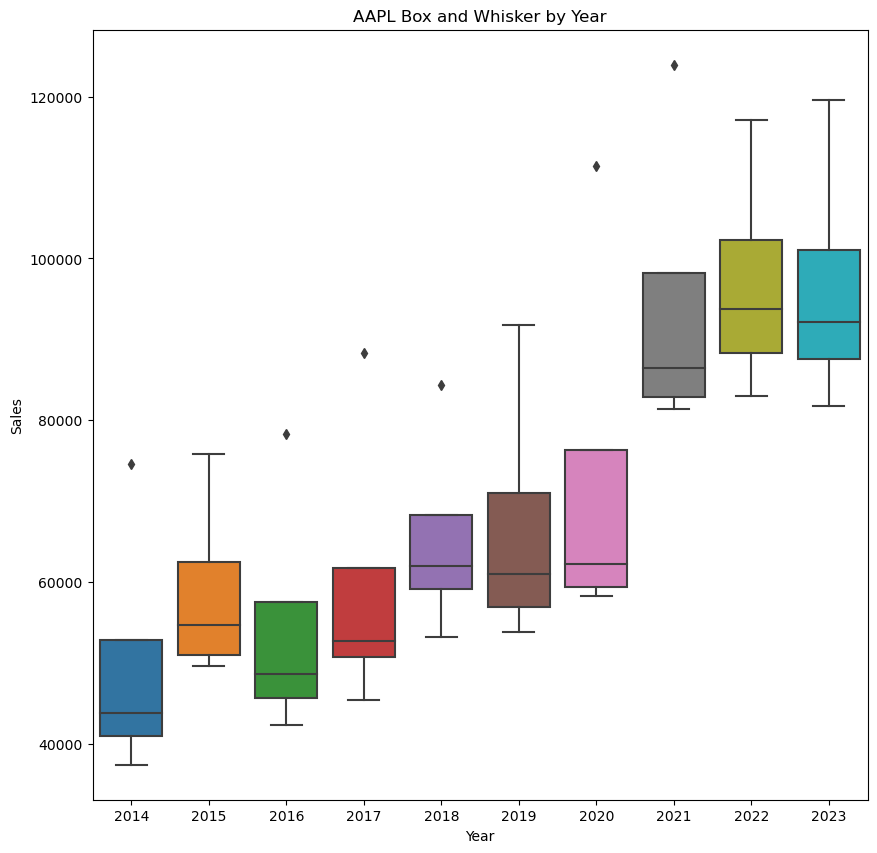

In [200]:
sn.boxplot(x='Year',y='Sales', data = goog).set(title = 'AAPL Box and Whisker by Year')

In [201]:
avgperqtr = goog[['Quarter', 'Sales']].groupby('Quarter').mean().reset_index()



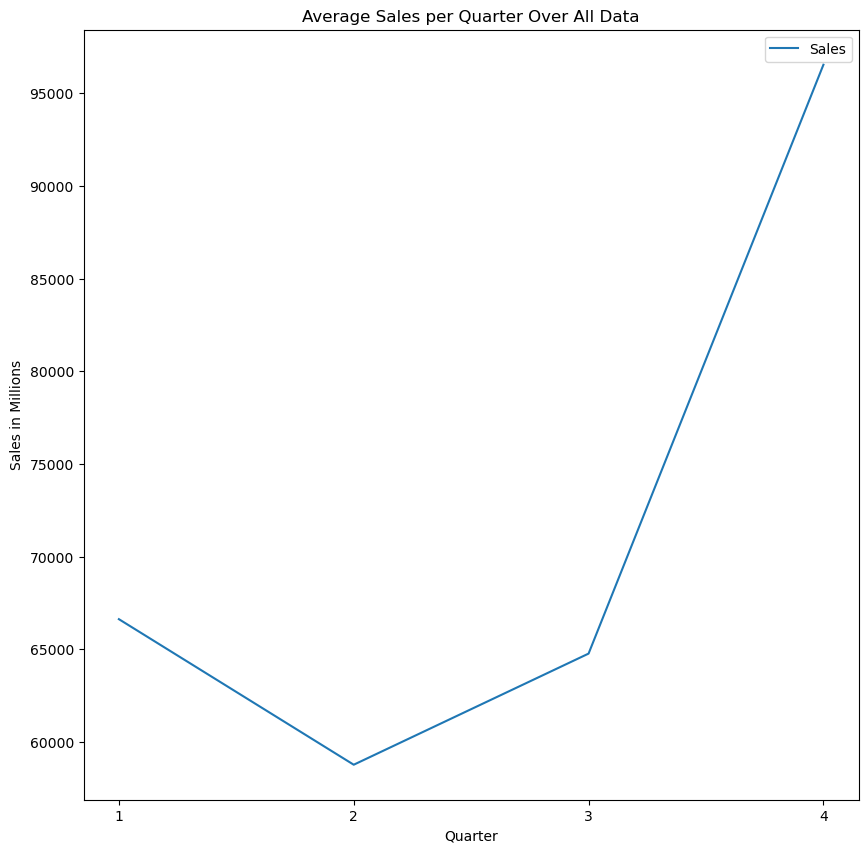

In [202]:
avgperqtr.plot('Quarter','Sales')
plt.ylabel('Sales in Millions')
plt.title('Average Sales per Quarter Over All Data')
plt.xticks(goog.Quarter.unique())
plt.show()

In [203]:
goog1 = pd.DataFrame(goog, columns=['Year','Quarter','Sales'])

In [204]:
dictyear = {}
saleslist = []
for year in goog1['Year'].unique():
    #print(year)
    #byyear = goog1[goog1['Year'] == year]
    #saleslist = saleslist.append(byyear.Sales) 
    dictyear[year] = list(goog1[goog1['Year'] == year].Sales)
    
    
    

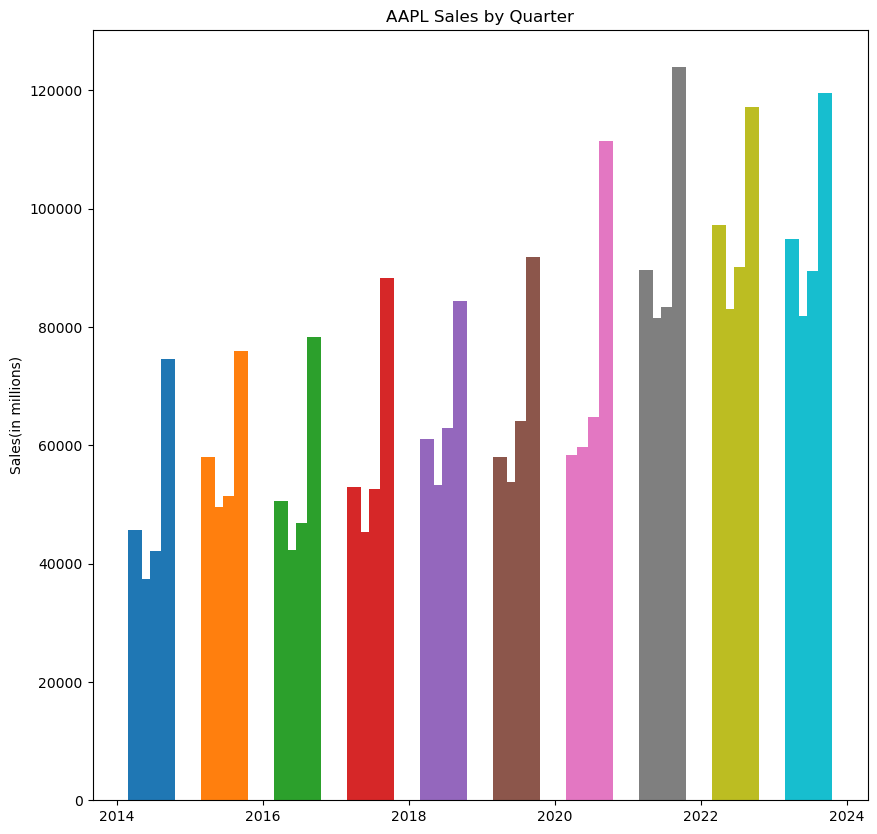

In [205]:
#adopted from https://medium.com/@BetterEverything/graph-quarterly-data-with-python-6f38bcc6b7fe
for year, data in dictyear.items():
    quarters = list(goog1.loc[(goog1['Year'] == year)].Quarter)
    x_coordinates = [year + 0.15 * q for q in quarters]
    #print(x_coordinates, data)
    plt.bar(x_coordinates,data,width=0.2,align='edge')
plt.title('AAPL Sales by Quarter')
plt.ylabel('Sales(in millions)')

#plt.xticks(labels=[np.unique(goog1['Year'].values)], ticks = [])
#print(plt.xticks())
plt.show()

In [206]:
goog.set_index('Date', inplace=True)

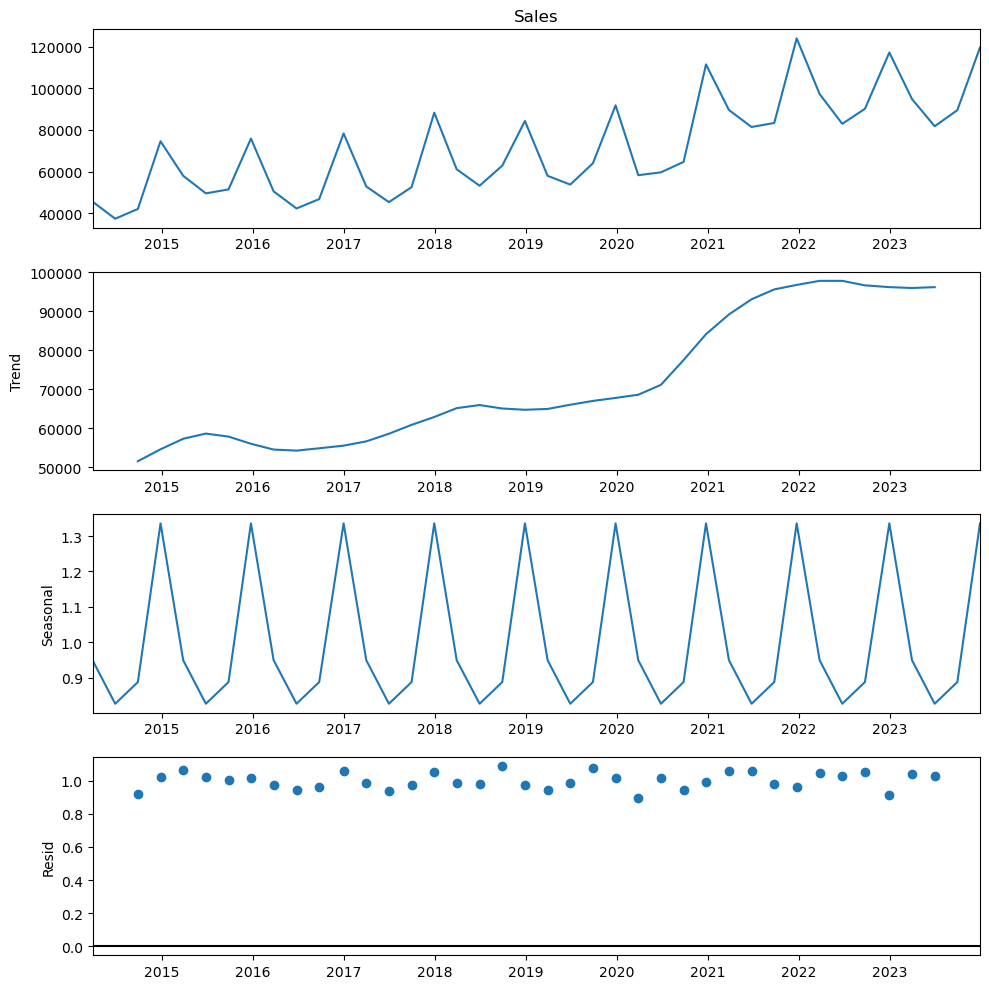

In [207]:

#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Sales'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

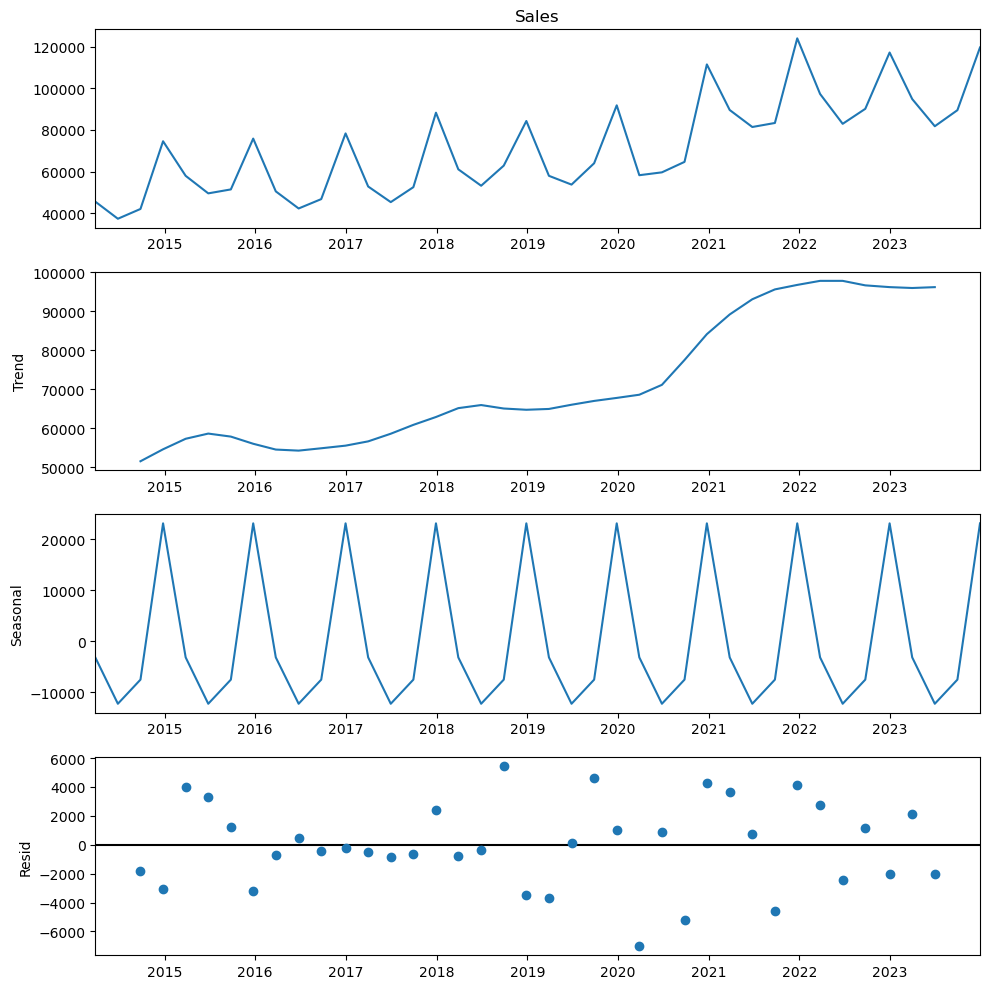

In [208]:
result = seasonal_decompose(goog['Sales'],model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
#plt.title('Time Series Decomposition of Sales')
plt.show()

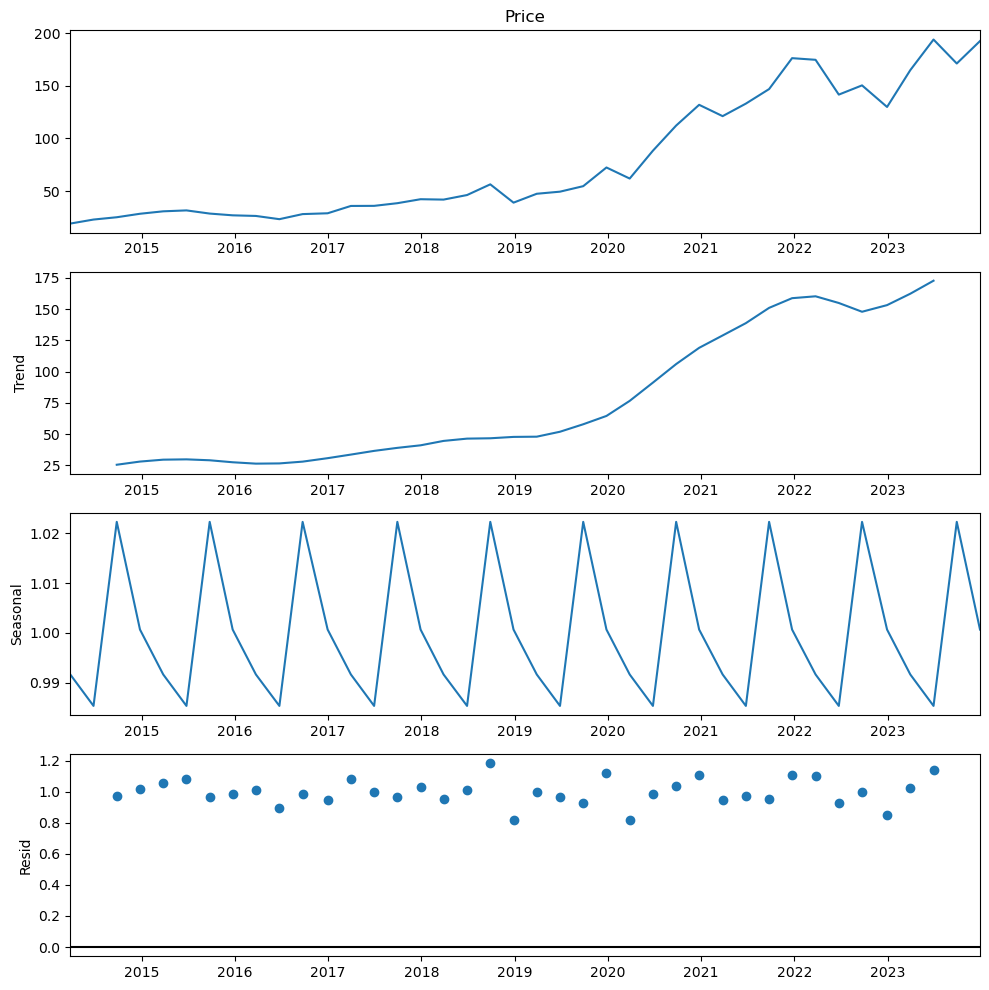

In [209]:
#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Price'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

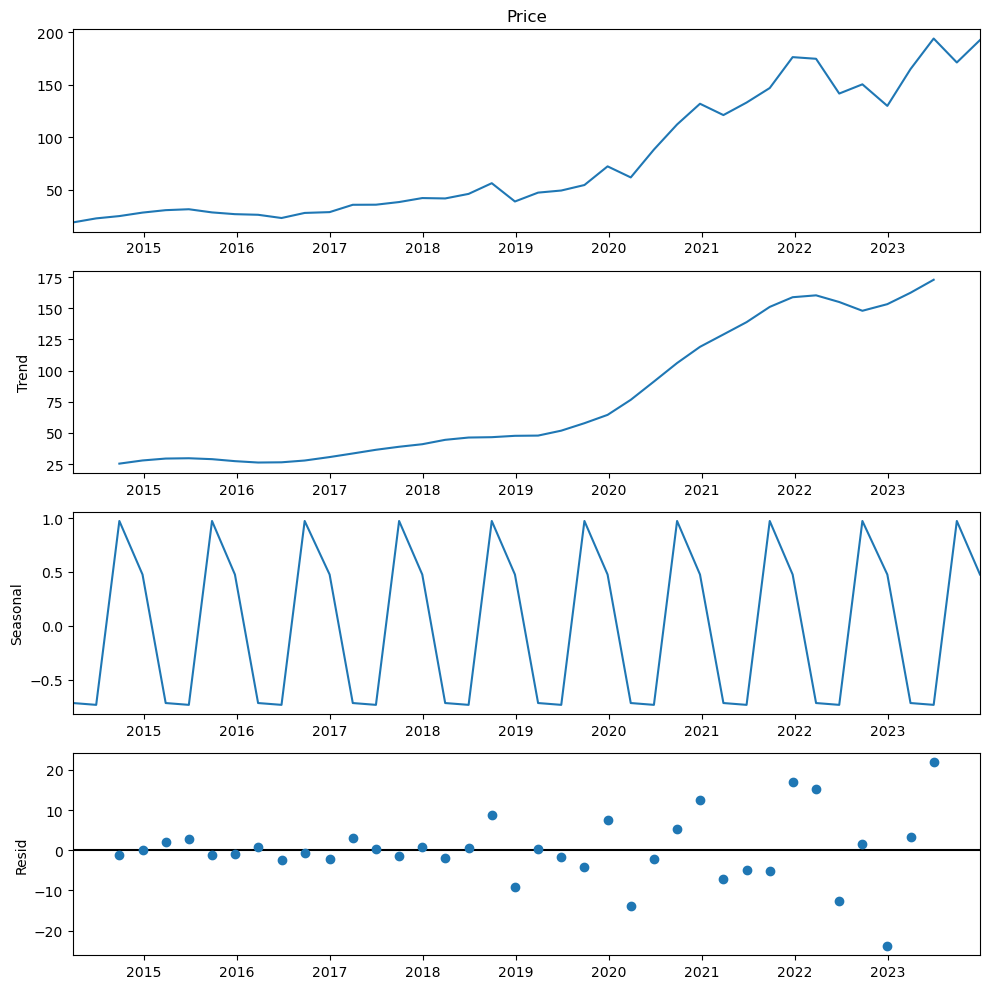

In [210]:
result = seasonal_decompose(goog['Price'], model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

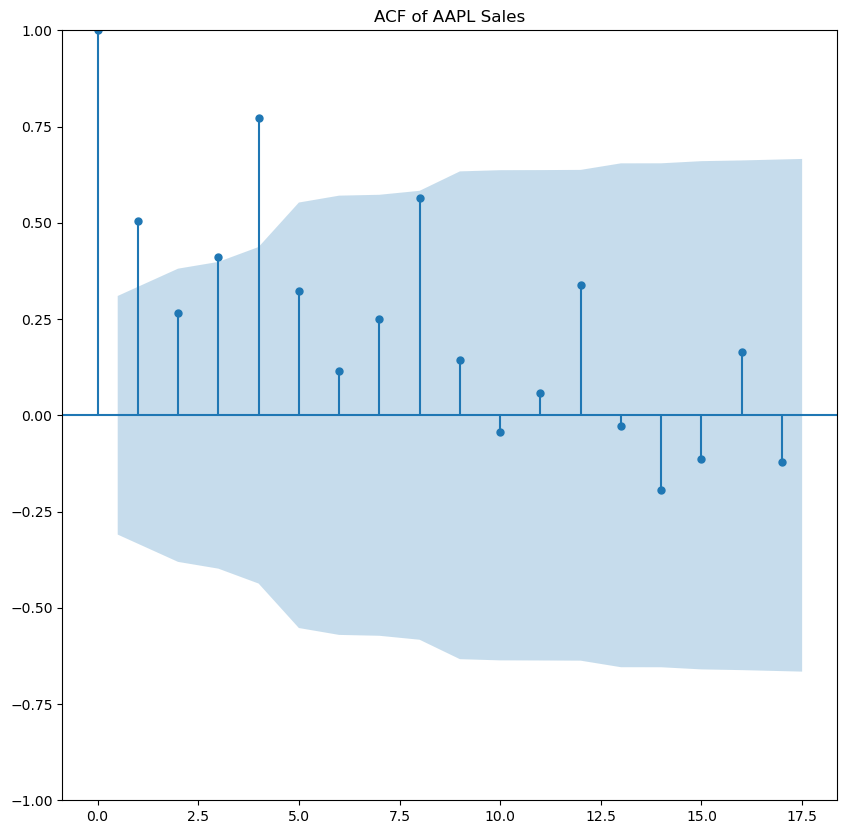

In [211]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_acf(goog['Sales'], title='ACF of AAPL Sales')
pyplot.show()

C:\Users\mdcas\anaconda_3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


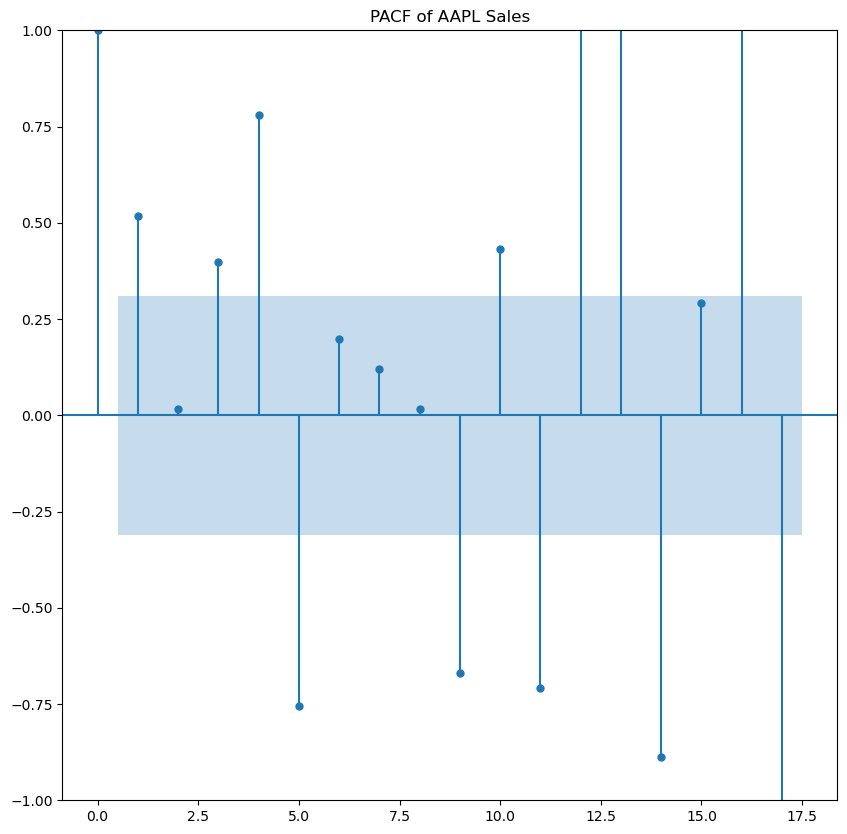

In [212]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_pacf(goog['Sales'], title='PACF of AAPL Sales')
pyplot.show()


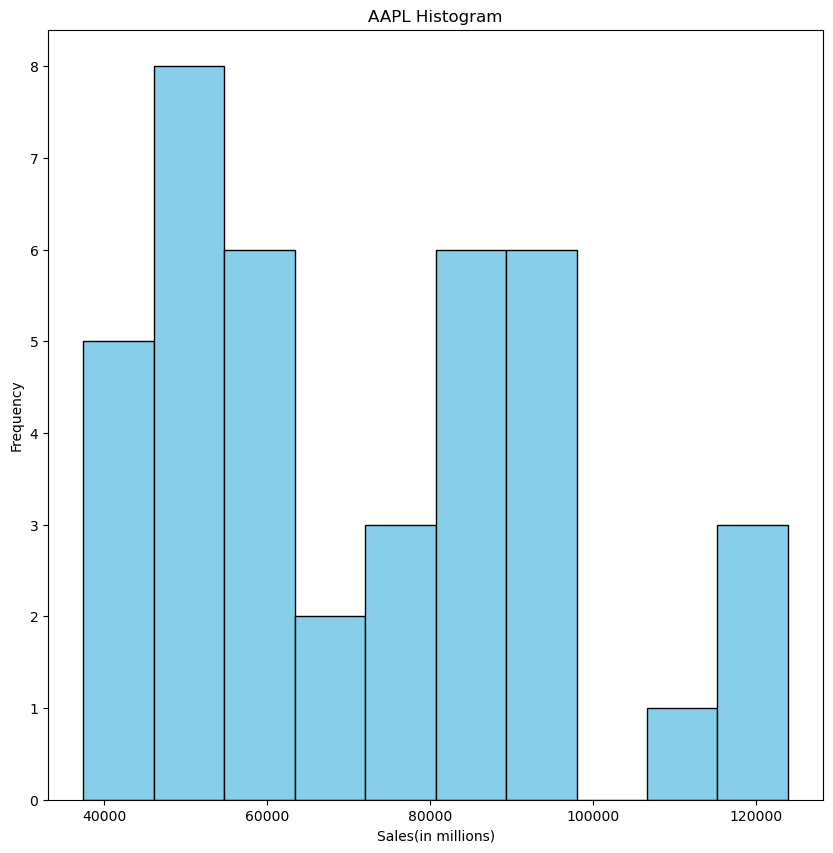

In [213]:
plt.hist(goog['Sales'], color='skyblue', edgecolor='black')
plt.xlabel('Sales(in millions)')
plt.ylabel('Frequency')
plt.title('AAPL Histogram')
pyplot.show()

In [214]:
# statistical test
result = adfuller(goog['Sales'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -0.518770
p-value: 0.888301
Critical Values:
	1%: -3.633
	5%: -2.949
	10%: -2.613


In [215]:
# statistical test
result = adfuller(goog['Price'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 2.614015
p-value: 0.999078
Critical Values:
	1%: -3.679
	5%: -2.968
	10%: -2.623


## AAPL Conclusion

Description of Time series (is it stationary, are there any trends, seasonality etc)

For AAPL,the results are interested compared to the first three we've analyzed. You can see there is clearly a trend higher in both price and sales over the last 10 years. It's interesting to note seasonality in Sales.  Second quarter is lowest quarter possibly due to sales mostly coming around the holidays, back to school and Chinese New Year. This can be seen in both the Average Sales per Quarter chart and the time series Decomposition.  The additive model seems to be more appropriate for the Sales data while the multiplicative approach seems to more appropriate for the stock price data. 

This is shown in both time series decomposition charts. The null hypothesis of the ADF test is the time series is Non Stationary. We conclude AAPL is Non Stationary both when looking at Sales and Price since the test statistic is larger than the critical values. 


AAPL does show autocorrelation at 1,2 and 5 lags.

### Analysis of MSFT Stock and Fundamentals over last 10 years

In [218]:
#goog = pd.read_csv('GOOGL.csv',header=0, index_col=0, parse_dates=True,squeeze=True)
goog = pd.read_csv('msft.csv')

In [219]:
goog.columns


Index(['Date', 'Sales', 'FreeCashFlow', 'Cash', 'Long Term Debt', 'Price'], dtype='object')

In [220]:
goog['Date'] = pd.to_datetime(goog['Date'], format='%m/%d/%Y')
goog['Year'] = goog['Date'].dt.year
goog['Quarter'] = goog['Date'].dt.quarter

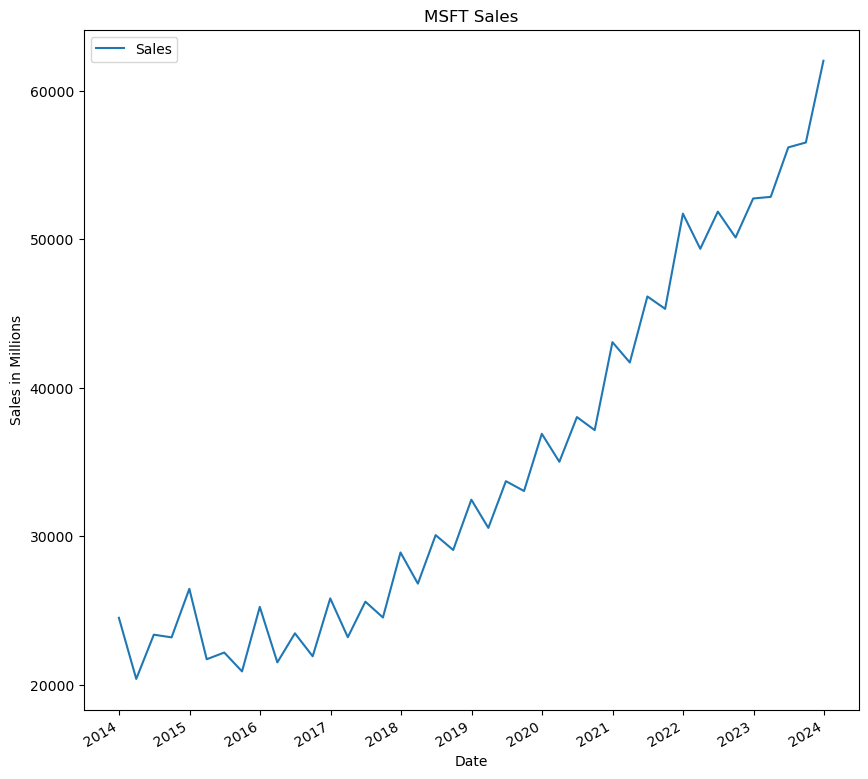

In [221]:
goog.plot('Date', 'Sales')
plt.title('MSFT Sales')
plt.ylabel('Sales in Millions')
plt.show()


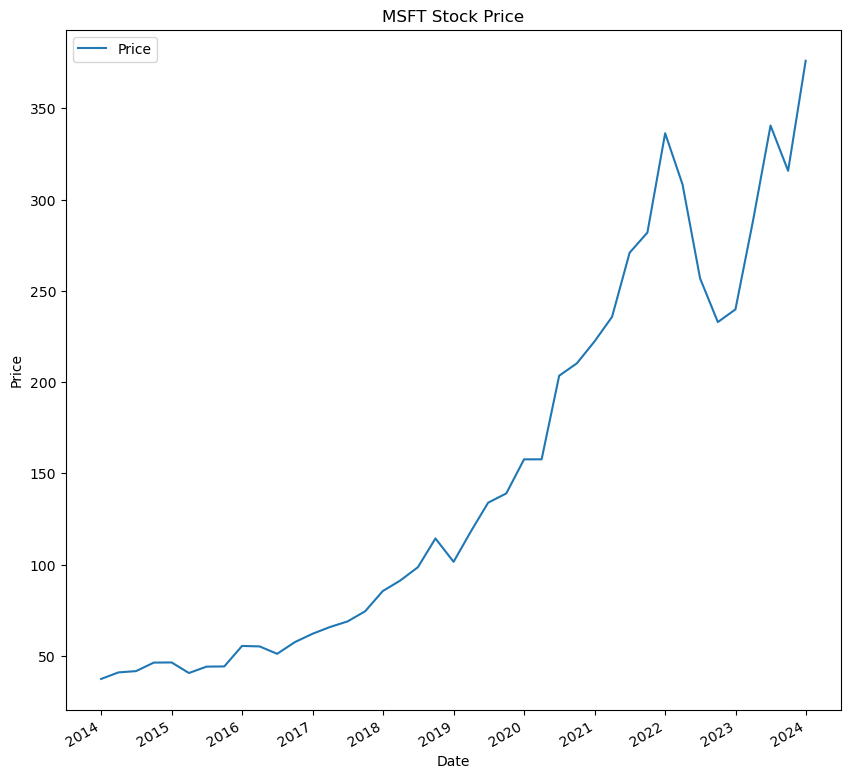

In [222]:
goog.plot('Date','Price')
plt.title('MSFT Stock Price')
plt.ylabel('Price')
plt.show()

Text(0.5, 1.0, 'MSFT Stock Price vs Sales')

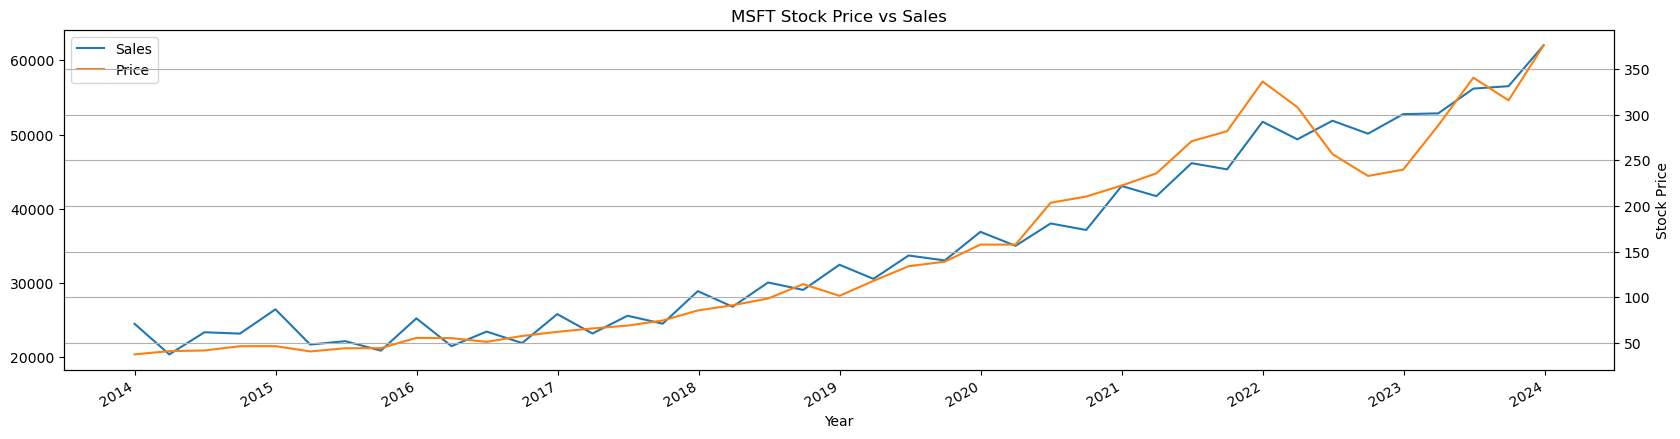

In [223]:
goog.loc[:,['Date','Sales','Price']].plot(x = 'Date',secondary_y=['Price'], xlabel = 'Year', ylabel = 'Stock Price',sharex = True,mark_right=False, figsize = (20,5), grid=True)
plt.title('MSFT Stock Price vs Sales')

[Text(0.5, 1.0, 'MSFT Box and Whisker by Year')]

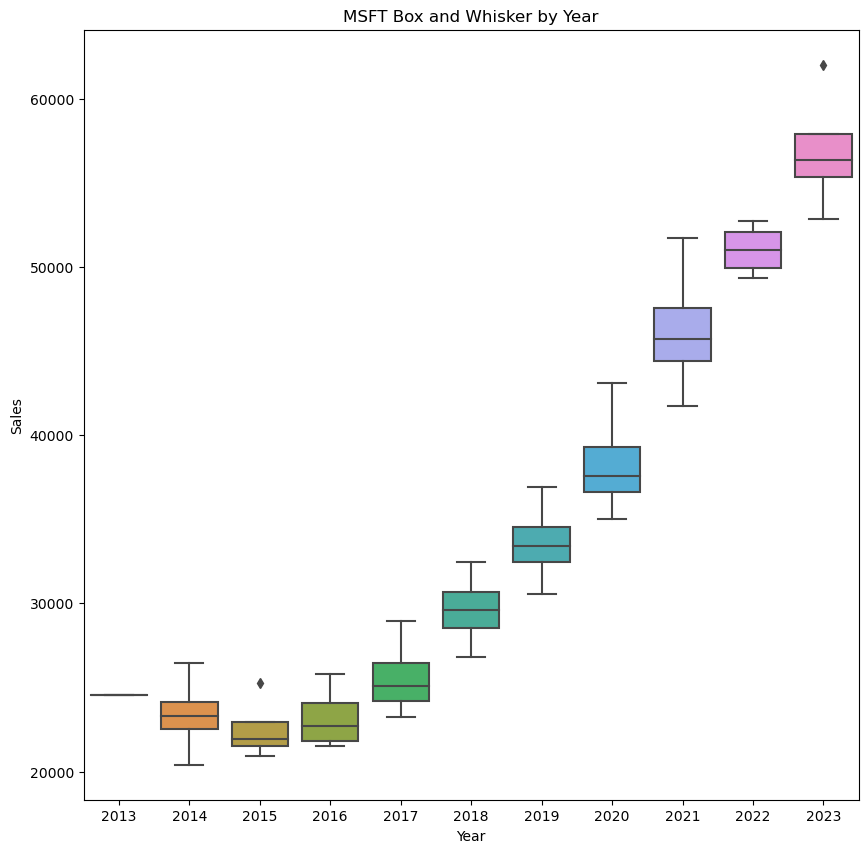

In [224]:
sn.boxplot(x='Year',y='Sales', data = goog).set(title = 'MSFT Box and Whisker by Year')

In [225]:
avgperqtr = goog[['Quarter', 'Sales']].groupby('Quarter').mean().reset_index()



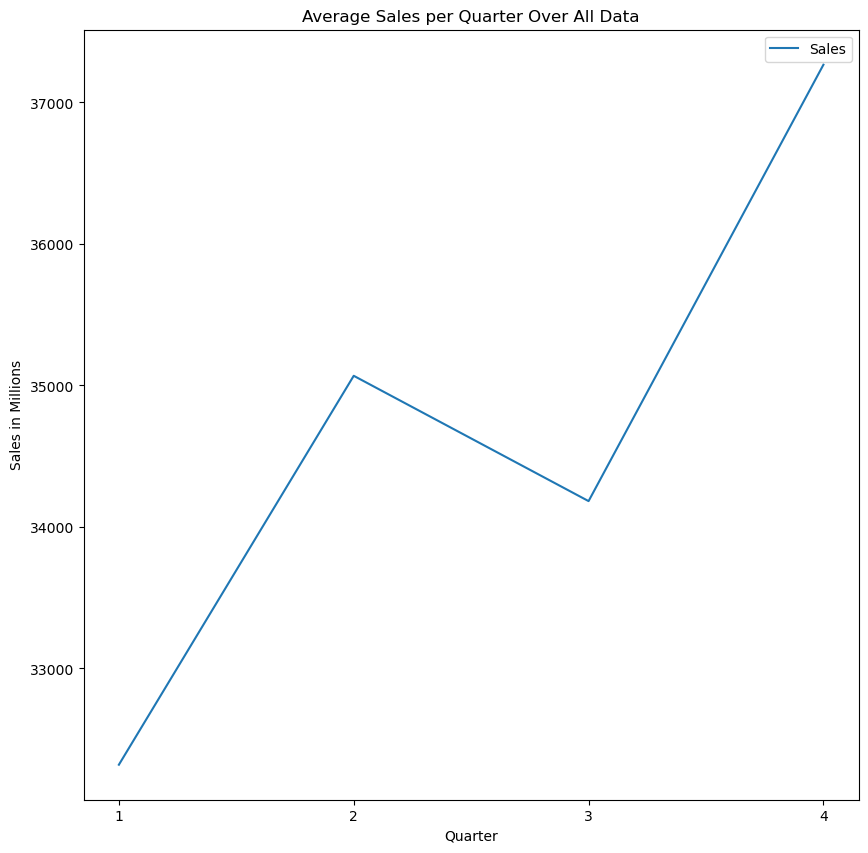

In [226]:
avgperqtr.plot('Quarter','Sales')
plt.ylabel('Sales in Millions')
plt.title('Average Sales per Quarter Over All Data')
plt.xticks(goog.Quarter.unique())
plt.show()

In [227]:
goog1 = pd.DataFrame(goog, columns=['Year','Quarter','Sales'])

In [228]:
dictyear = {}
saleslist = []
for year in goog1['Year'].unique():
    #print(year)
    #byyear = goog1[goog1['Year'] == year]
    #saleslist = saleslist.append(byyear.Sales) 
    dictyear[year] = list(goog1[goog1['Year'] == year].Sales)
    
    
    

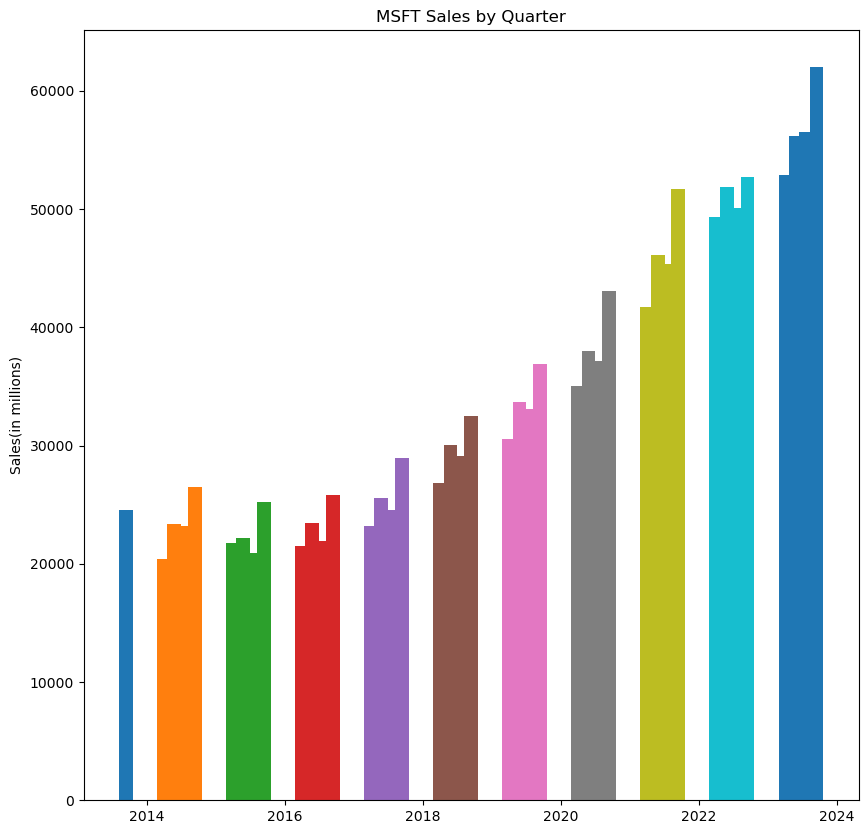

In [229]:
#adopted from https://medium.com/@BetterEverything/graph-quarterly-data-with-python-6f38bcc6b7fe
for year, data in dictyear.items():
    quarters = list(goog1.loc[(goog1['Year'] == year)].Quarter)
    x_coordinates = [year + 0.15 * q for q in quarters]
    #print(x_coordinates, data)
    plt.bar(x_coordinates,data,width=0.2,align='edge')
plt.title('MSFT Sales by Quarter')
plt.ylabel('Sales(in millions)')

#plt.xticks(labels=[np.unique(goog1['Year'].values)], ticks = [])
#print(plt.xticks())
plt.show()

In [230]:
goog.set_index('Date', inplace=True)

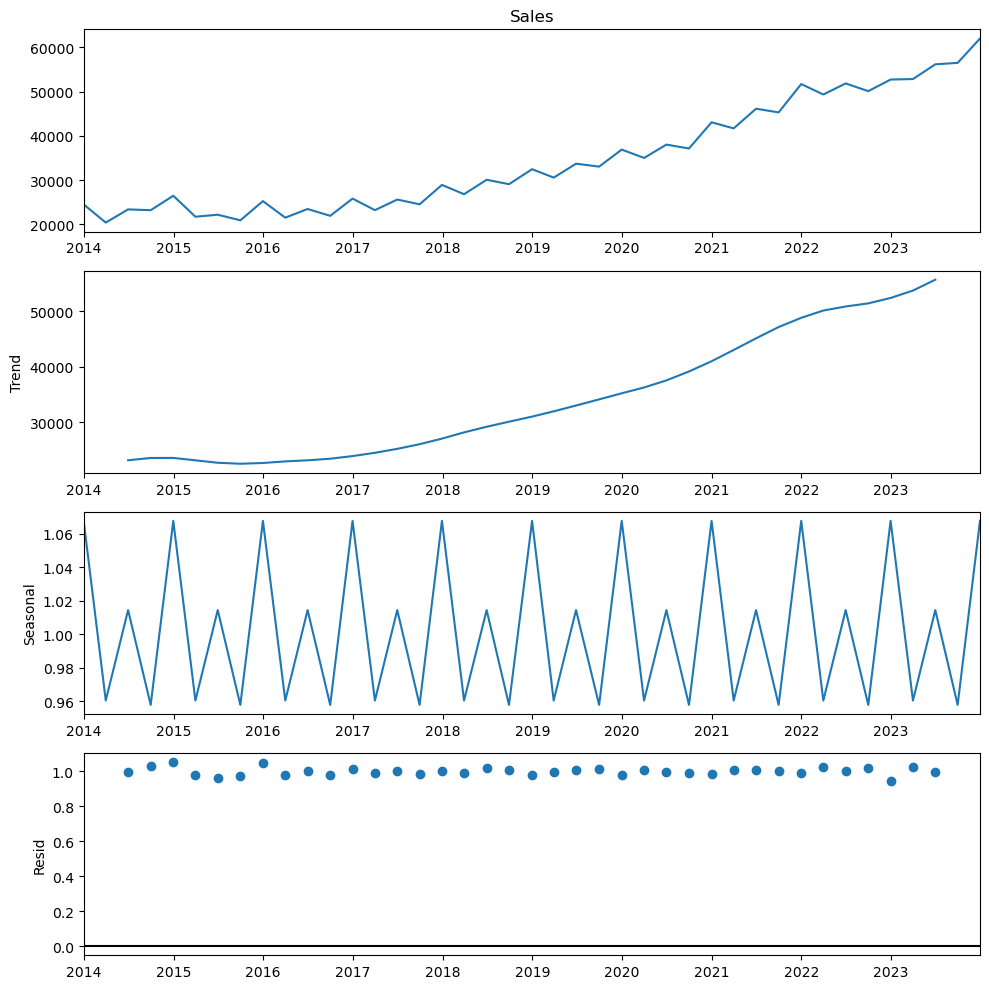

In [231]:

#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Sales'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

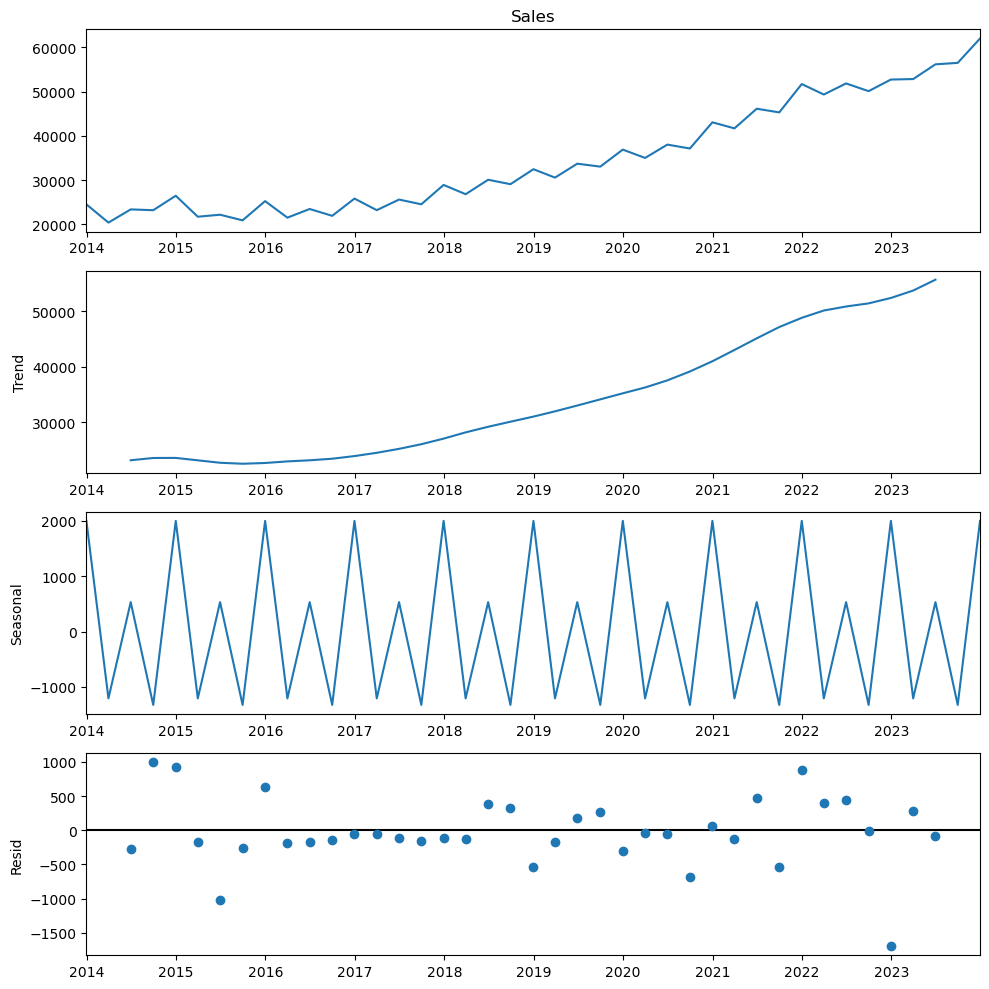

In [232]:
result = seasonal_decompose(goog['Sales'],model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
#plt.title('Time Series Decomposition of Sales')
plt.show()

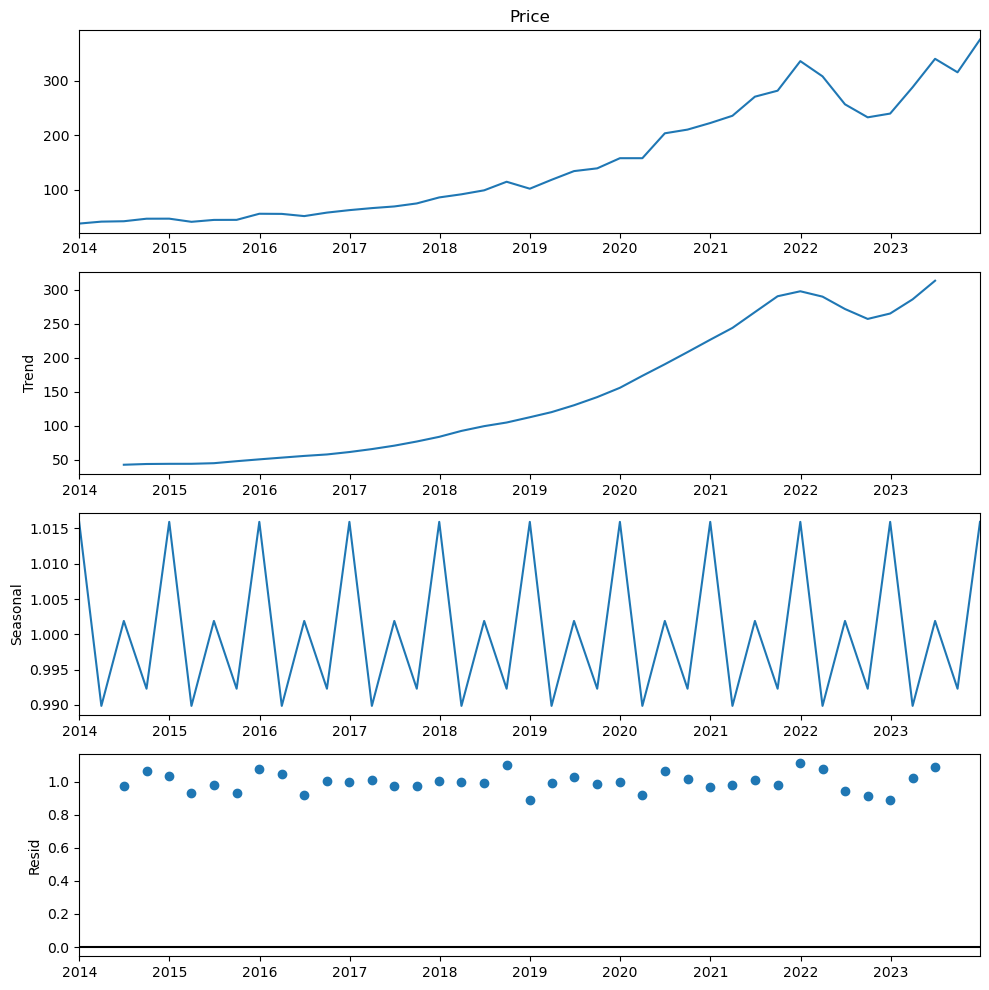

In [233]:
#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Price'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

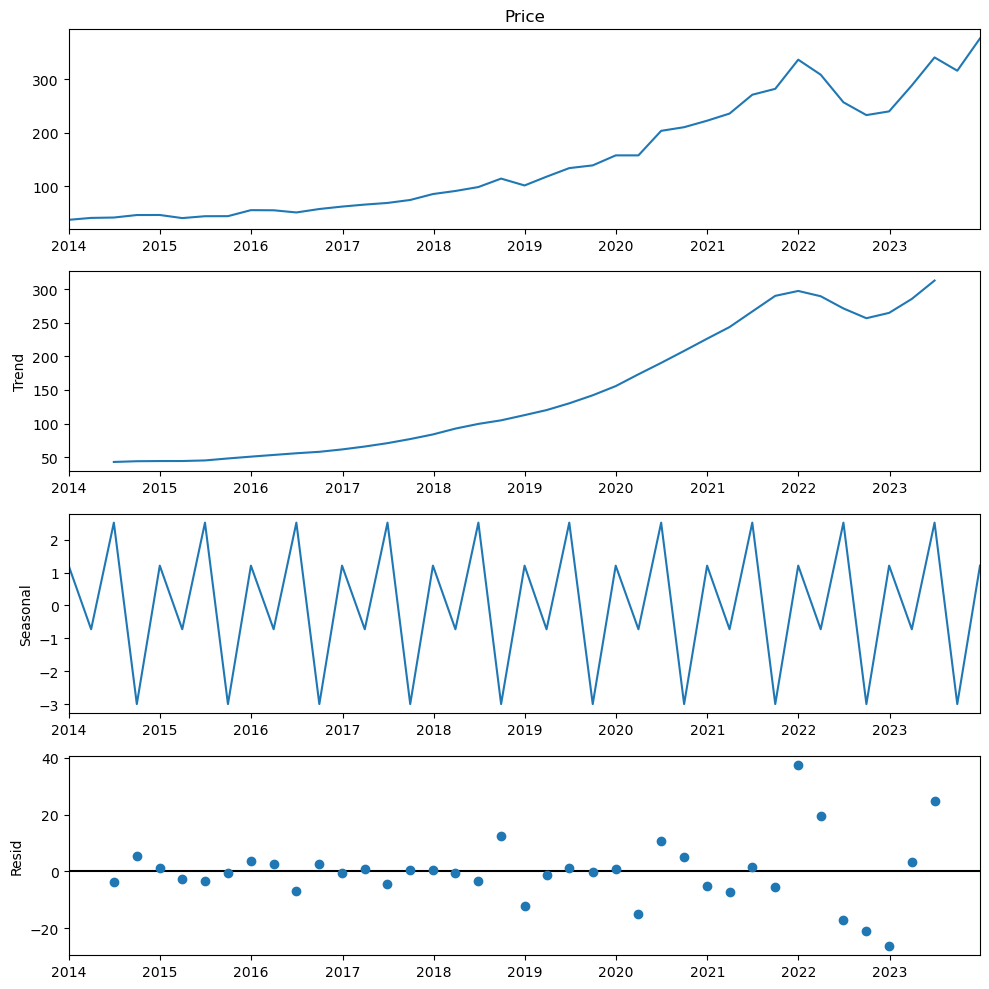

In [234]:
result = seasonal_decompose(goog['Price'], model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

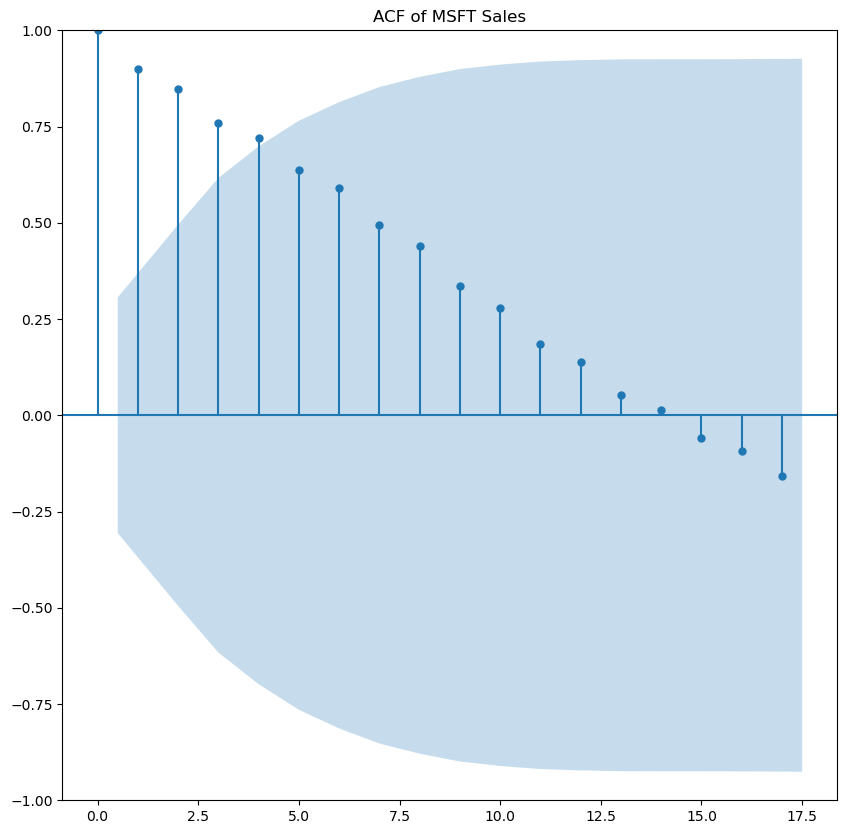

In [235]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_acf(goog['Sales'], title='ACF of MSFT Sales')
pyplot.show()

C:\Users\mdcas\anaconda_3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


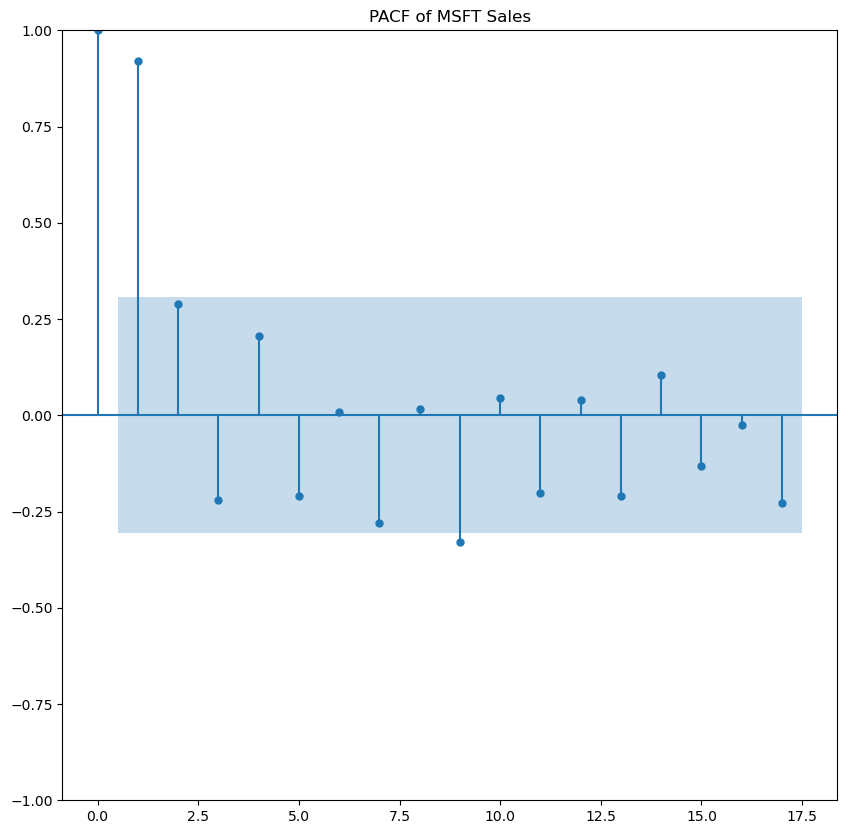

In [236]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_pacf(goog['Sales'], title='PACF of MSFT Sales')
pyplot.show()


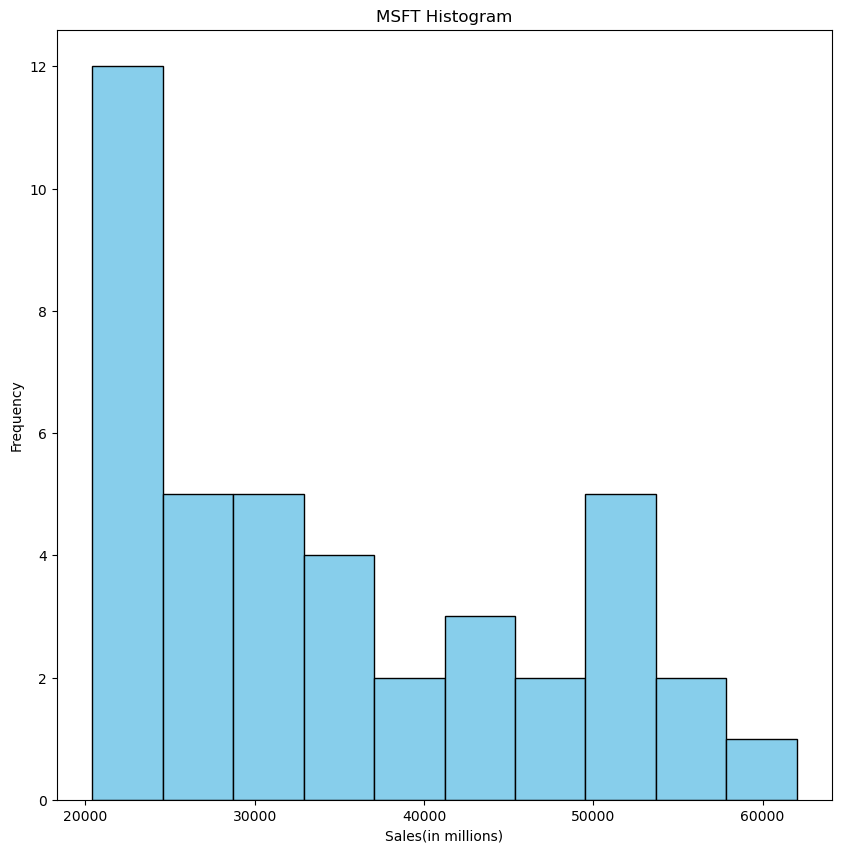

In [237]:
plt.hist(goog['Sales'], color='skyblue', edgecolor='black')
plt.xlabel('Sales(in millions)')
plt.ylabel('Frequency')
plt.title('MSFT Histogram')
pyplot.show()

In [238]:
# statistical test
result = adfuller(goog['Sales'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 1.150560
p-value: 0.995626
Critical Values:
	1%: -3.654
	5%: -2.957
	10%: -2.618


In [239]:
# statistical test
result = adfuller(goog['Price'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 2.103584
p-value: 0.998793
Critical Values:
	1%: -3.646
	5%: -2.954
	10%: -2.616


## MSFT Conclusion

Description of Time series (is it stationary, are there any trends, seasonality etc)

For MSFT, you can see there is clearly a very steady trend higher in Sales over the last 10 years. Price trending higher as well. The seasonality is interesting.  1st quarter definetely the lowest but a stall of sales growth between the 2nd and 4th quarters.  The fourth quarter is massively higher compared to the first 3 quarters. The additive model seems to be more appropriate for the Sales and Stock price data as the residuals in each case appear like white noise in the additive model but have more of a pattern in the multiplicative model. This is shown in both time series decomposition charts.

The null hypothesis of the ADF test is the time series is Non Stationary. We conclude MSFT is Non Stationary both when looking at Sales and Price since the test statistic is larger than the critical values. 


MSFT does show autocorrelation out to about 5 lags.

### Analysis of META Stock and Fundamentals over last 10 years

In [242]:
#goog = pd.read_csv('GOOGL.csv',header=0, index_col=0, parse_dates=True,squeeze=True)
goog = pd.read_csv('meta.csv')

In [243]:
goog.columns


Index(['Date', 'Sales', 'FreeCashFlow', 'Cash', ' Long Term Debt ', 'Price'], dtype='object')

In [244]:
goog['Date'] = pd.to_datetime(goog['Date'], format='%m/%d/%Y')
goog['Year'] = goog['Date'].dt.year
goog['Quarter'] = goog['Date'].dt.quarter

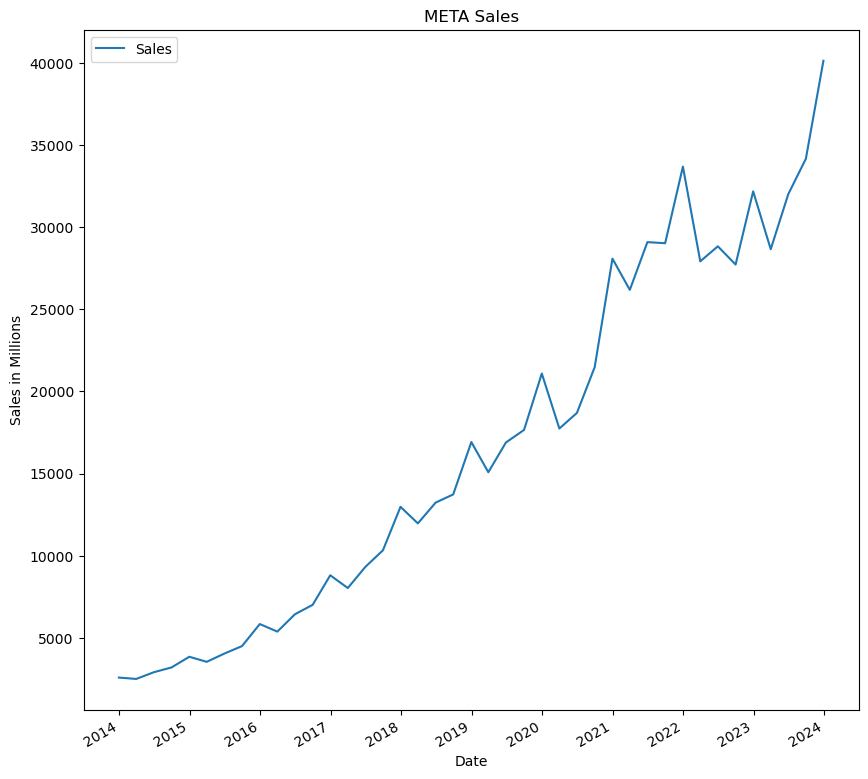

In [245]:
goog.plot('Date', 'Sales')
plt.title('META Sales')
plt.ylabel('Sales in Millions')
plt.show()


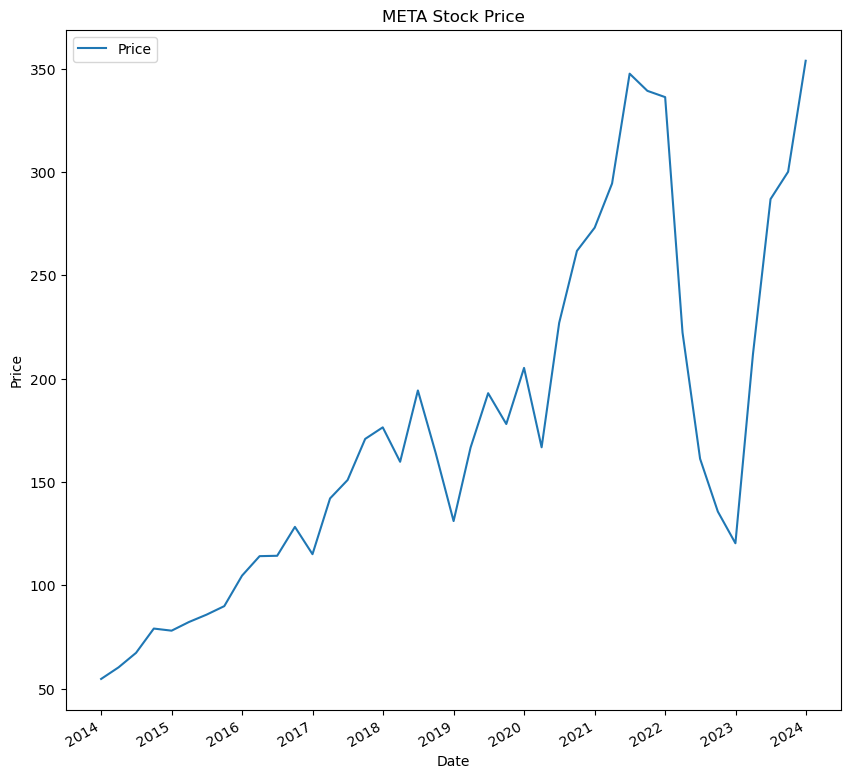

In [246]:
goog.plot('Date','Price')
plt.title('META Stock Price')
plt.ylabel('Price')
plt.show()

Text(0.5, 1.0, 'META Stock Price vs Sales')

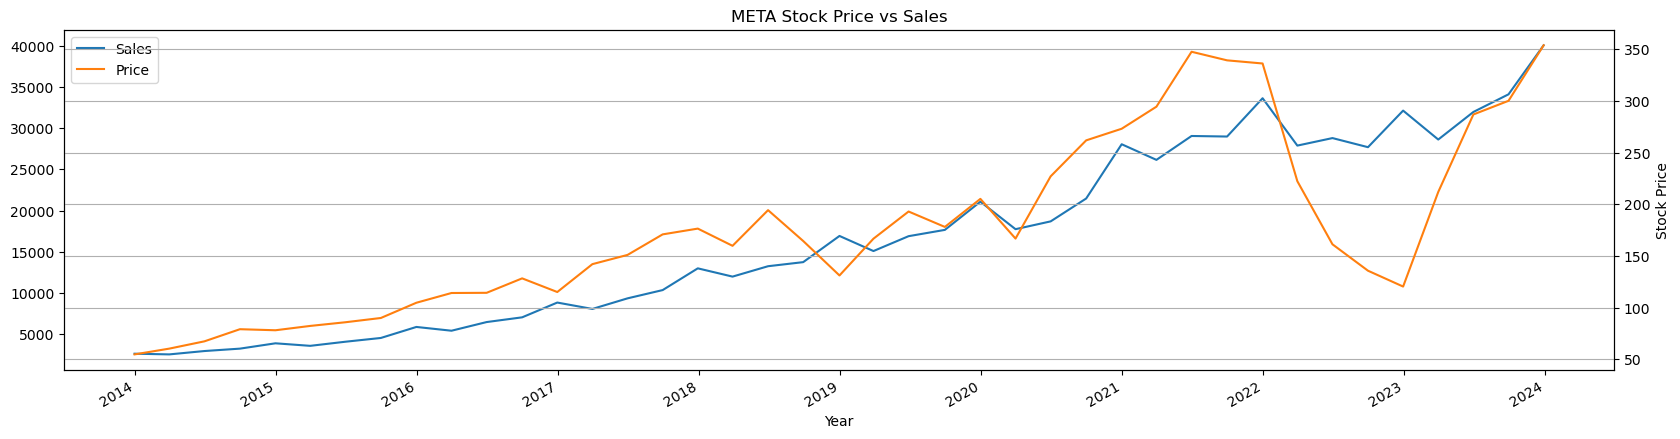

In [247]:
goog.loc[:,['Date','Sales','Price']].plot(x = 'Date',secondary_y=['Price'], xlabel = 'Year', ylabel = 'Stock Price',sharex = True,mark_right=False, figsize = (20,5), grid=True)
plt.title('META Stock Price vs Sales')

[Text(0.5, 1.0, 'META Box and Whisker by Year')]

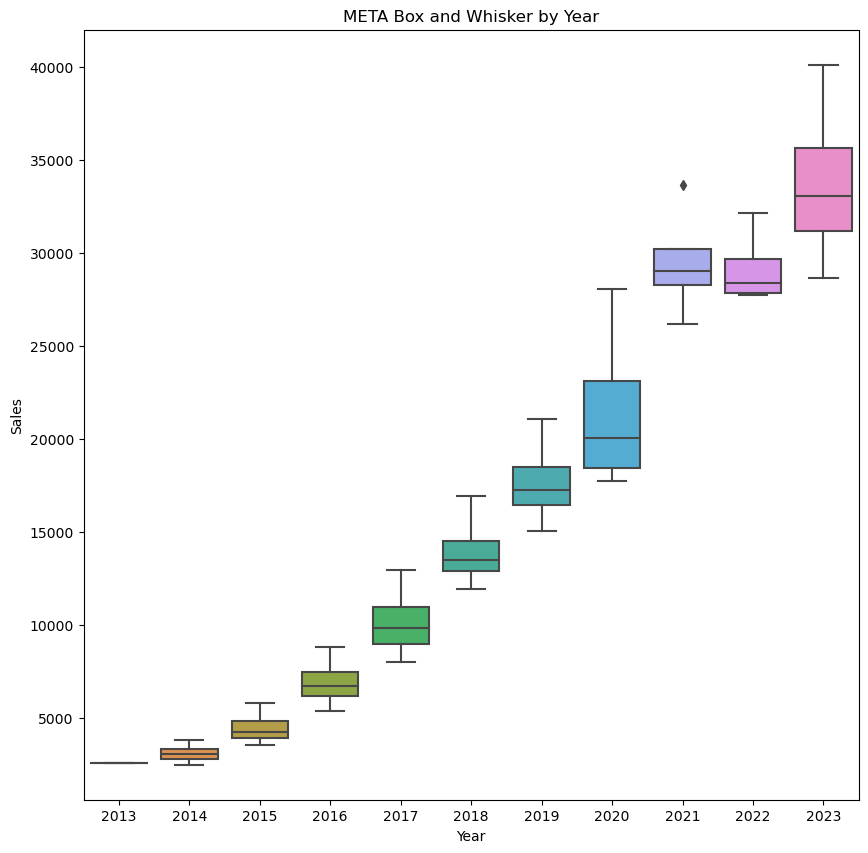

In [248]:
sn.boxplot(x='Year',y='Sales', data = goog).set(title = 'META Box and Whisker by Year')

In [249]:
avgperqtr = goog[['Quarter', 'Sales']].groupby('Quarter').mean().reset_index()



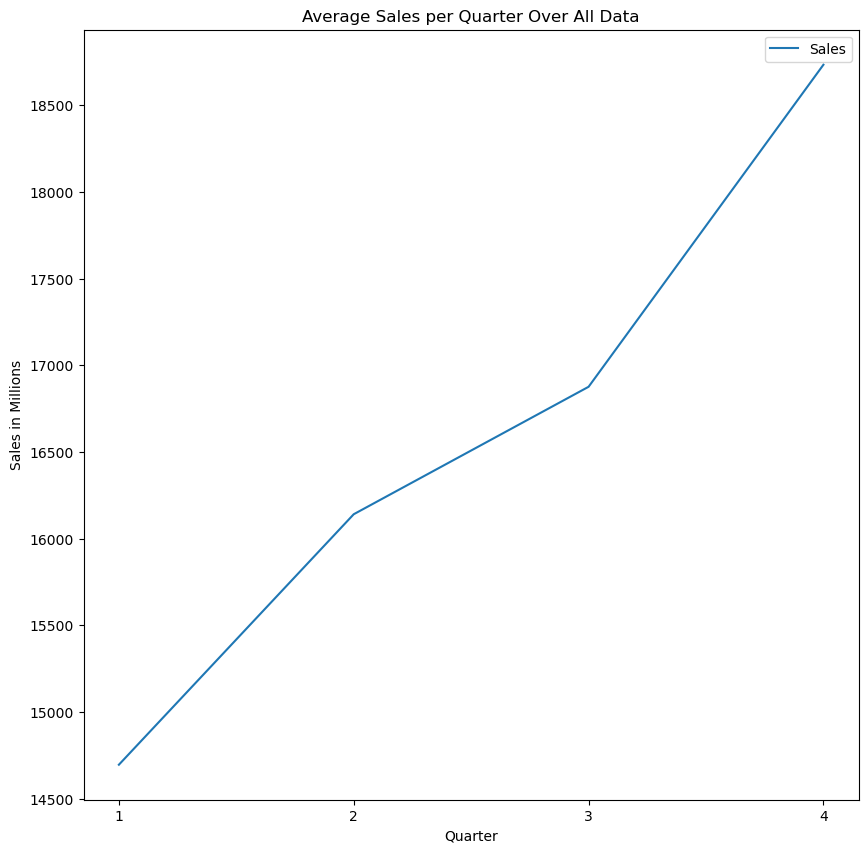

In [250]:
avgperqtr.plot('Quarter','Sales')
plt.ylabel('Sales in Millions')
plt.title('Average Sales per Quarter Over All Data')
plt.xticks(goog.Quarter.unique())
plt.show()

In [251]:
goog1 = pd.DataFrame(goog, columns=['Year','Quarter','Sales'])

In [252]:
dictyear = {}
saleslist = []
for year in goog1['Year'].unique():
    #print(year)
    #byyear = goog1[goog1['Year'] == year]
    #saleslist = saleslist.append(byyear.Sales) 
    dictyear[year] = list(goog1[goog1['Year'] == year].Sales)
    
    
    

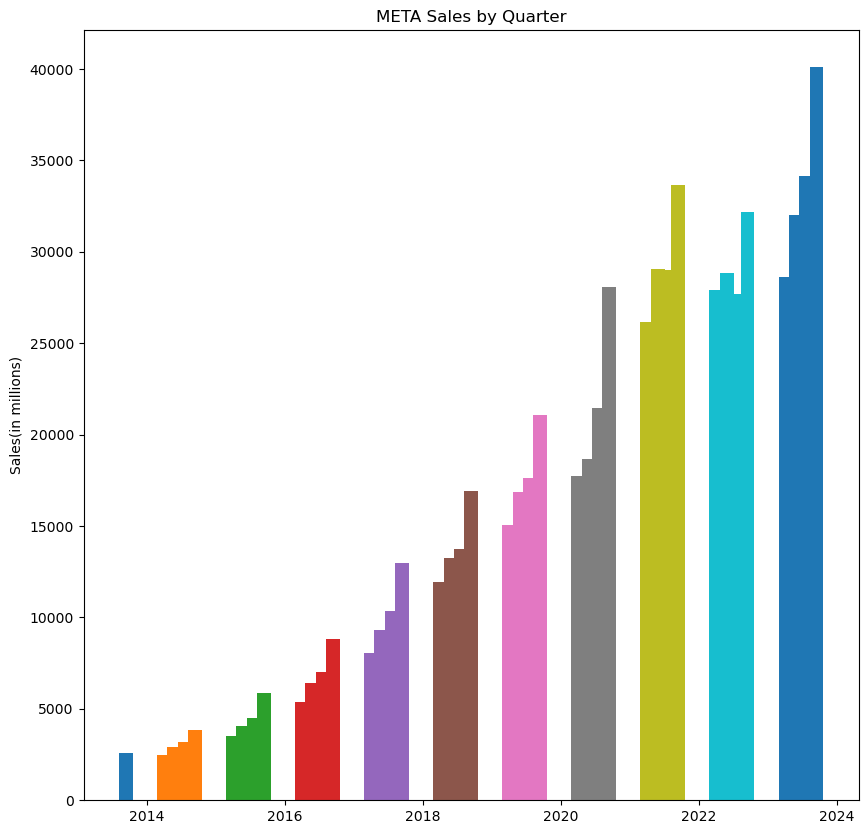

In [253]:
#adopted from https://medium.com/@BetterEverything/graph-quarterly-data-with-python-6f38bcc6b7fe
for year, data in dictyear.items():
    quarters = list(goog1.loc[(goog1['Year'] == year)].Quarter)
    x_coordinates = [year + 0.15 * q for q in quarters]
    #print(x_coordinates, data)
    plt.bar(x_coordinates,data,width=0.2,align='edge')
plt.title('META Sales by Quarter')
plt.ylabel('Sales(in millions)')

#plt.xticks(labels=[np.unique(goog1['Year'].values)], ticks = [])
#print(plt.xticks())
plt.show()

In [254]:
goog.set_index('Date', inplace=True)

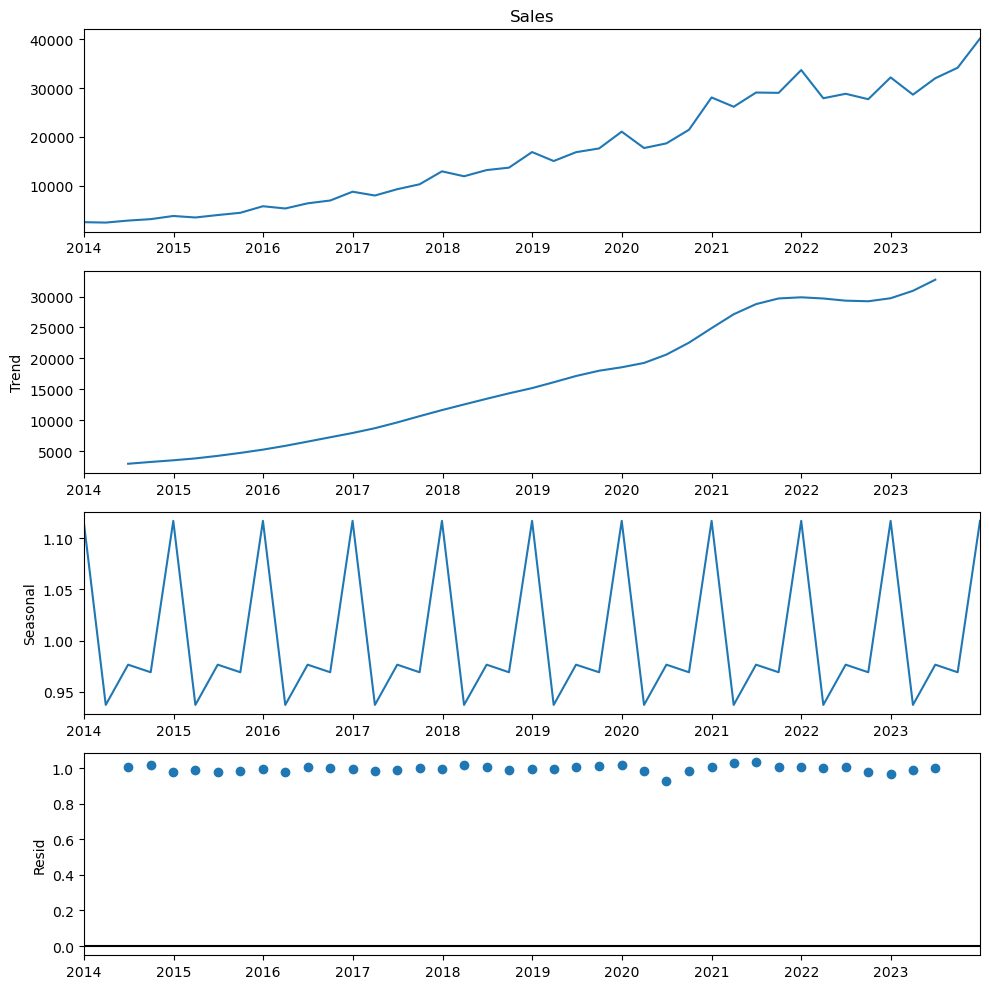

In [255]:

#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Sales'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

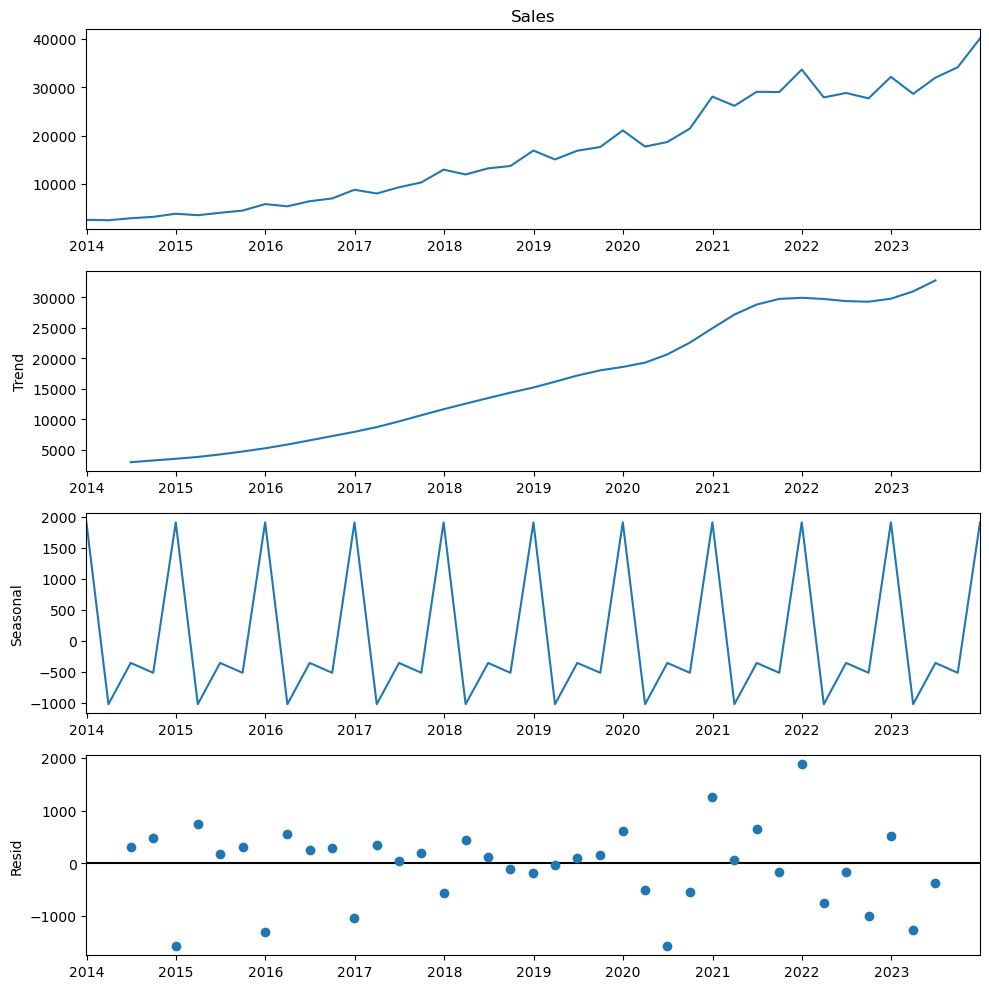

In [256]:
result = seasonal_decompose(goog['Sales'],model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
#plt.title('Time Series Decomposition of Sales')
plt.show()

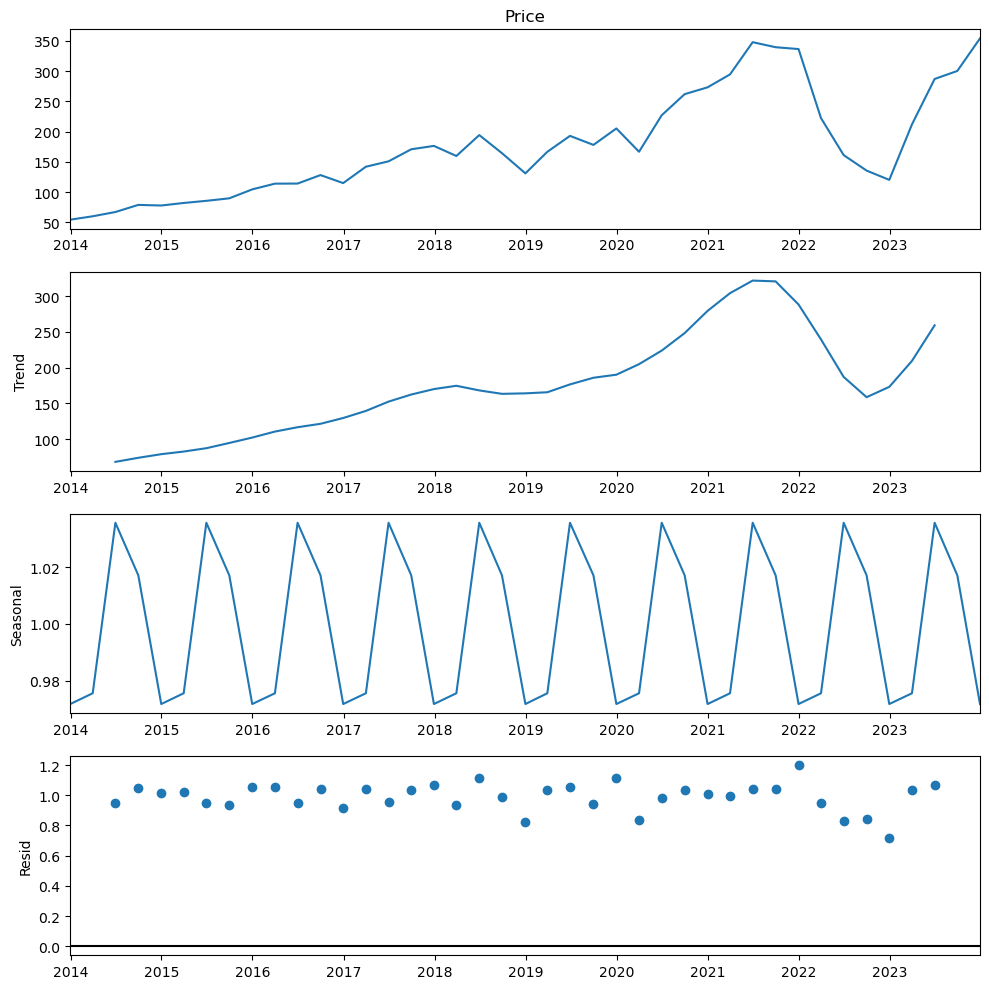

In [257]:
#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Price'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

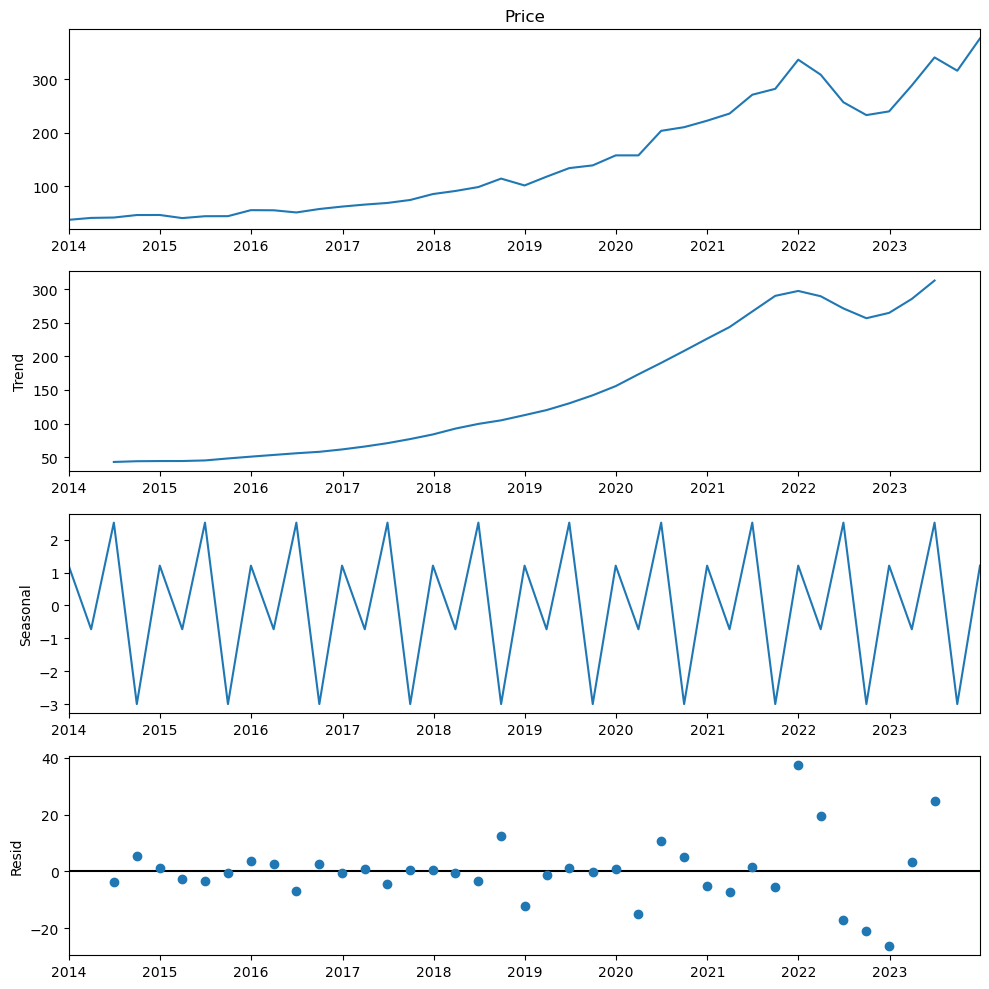

In [234]:
result = seasonal_decompose(goog['Price'], model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

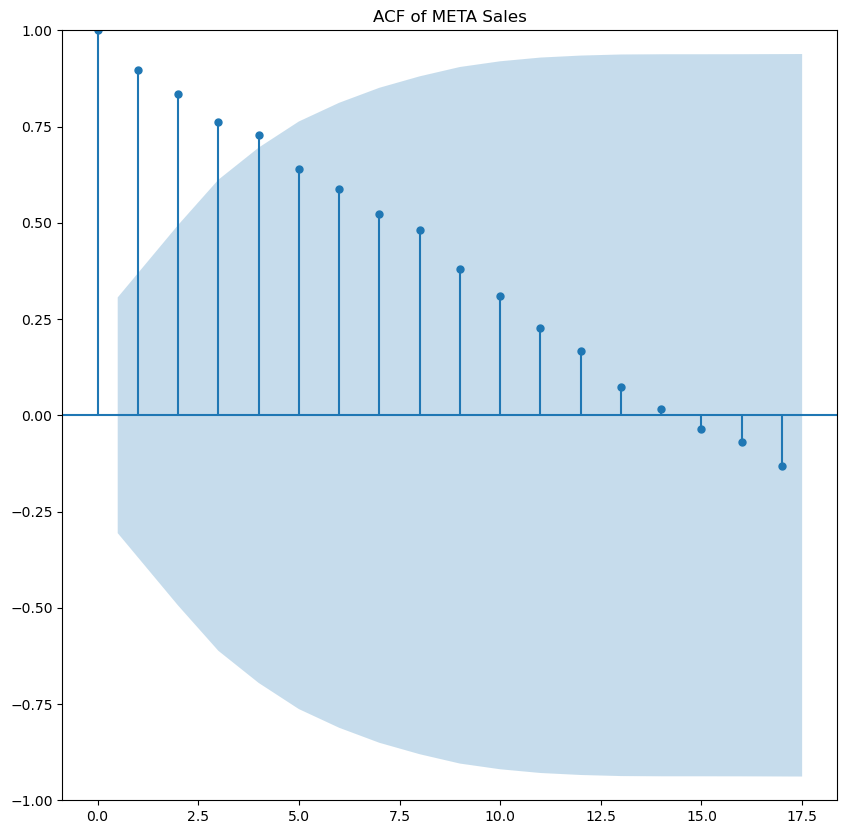

In [258]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_acf(goog['Sales'], title='ACF of META Sales')
pyplot.show()

C:\Users\mdcas\anaconda_3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


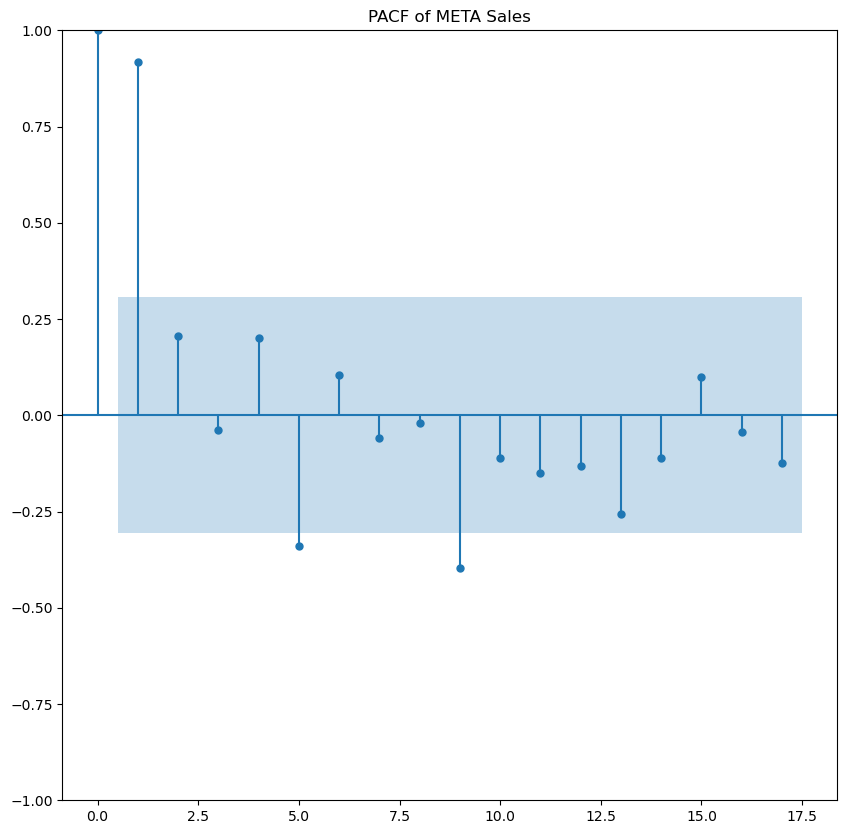

In [259]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_pacf(goog['Sales'], title='PACF of META Sales')
pyplot.show()


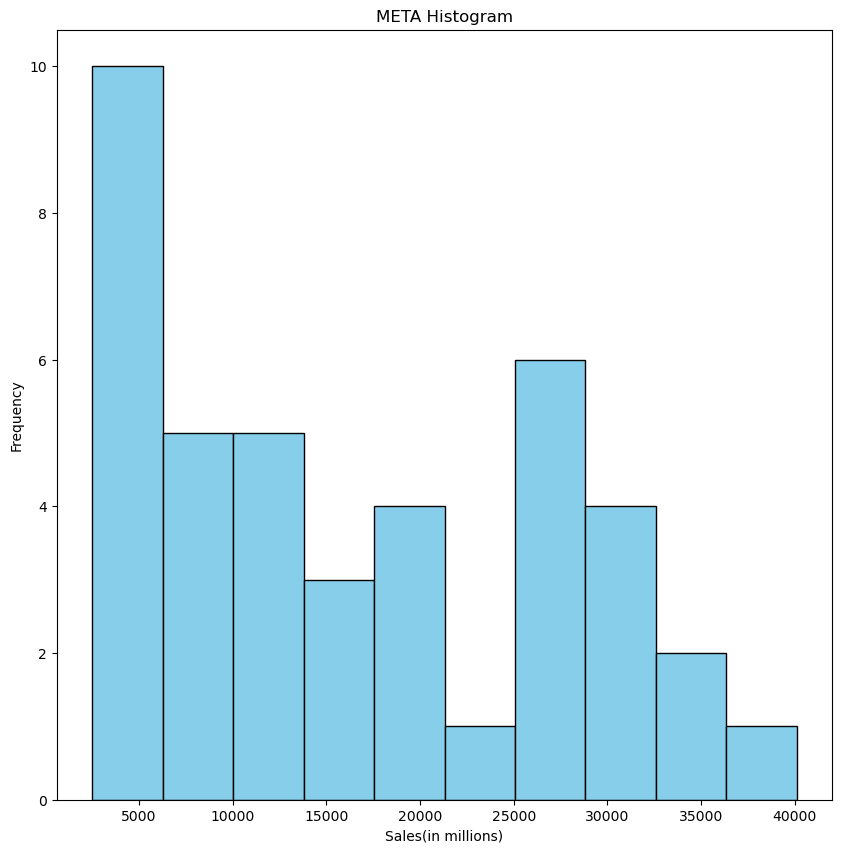

In [260]:
plt.hist(goog['Sales'], color='skyblue', edgecolor='black')
plt.xlabel('Sales(in millions)')
plt.ylabel('Frequency')
plt.title('META Histogram')
pyplot.show()

In [261]:
# statistical test
result = adfuller(goog['Sales'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 1.346103
p-value: 0.996855
Critical Values:
	1%: -3.639
	5%: -2.951
	10%: -2.614


In [262]:
# statistical test
result = adfuller(goog['Price'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -1.355435
p-value: 0.603445
Critical Values:
	1%: -3.654
	5%: -2.957
	10%: -2.618


## META Conclusion

Description of Time Series (is it stationary, are there any trends, seasonality, etc)

For META, you can see there is clearly a very steady trend higher in Sales and Stock Price over the last 10 years. The seasonality is of the Sales and Stock Price is really interesting. Sales has seasonality where sales bottom in the first quarter and peak in the 4th quarter.  Seasonality for stock price is different.  The multiplicative model indicates stock price seasonality is the strongest in the middle quarters(2nd and 3rd quarters) and weakest in the first and last quarter. The additive model seems to be more appropriate for the Sales and Stock price data as the residuals in each case appear like white noise in the additive model but have more of a pattern in the multiplicative model. This is shown in both time series decomposition charts. The null hypothesis of the ADF test is the time series is Non Stationary. 

We conclude META is Non Stationary both when looking at Sales and Price since the test statistic is larger than the critical values. 


META does show autocorrelation out to about 5 lags.



### Analysis of NVDA Stock and Fundamentals over last 10 years

In [265]:
#goog = pd.read_csv('GOOGL.csv',header=0, index_col=0, parse_dates=True,squeeze=True)
goog = pd.read_csv('nvda.csv')

In [266]:
goog.columns


Index(['Date', 'Sales', 'FreeCashFlow', 'Cash', 'Long Term Debt', 'Price'], dtype='object')

In [267]:
goog['Date'] = pd.to_datetime(goog['Date'], format='%m/%d/%Y')
goog['Year'] = goog['Date'].dt.year
goog['Quarter'] = goog['Date'].dt.quarter

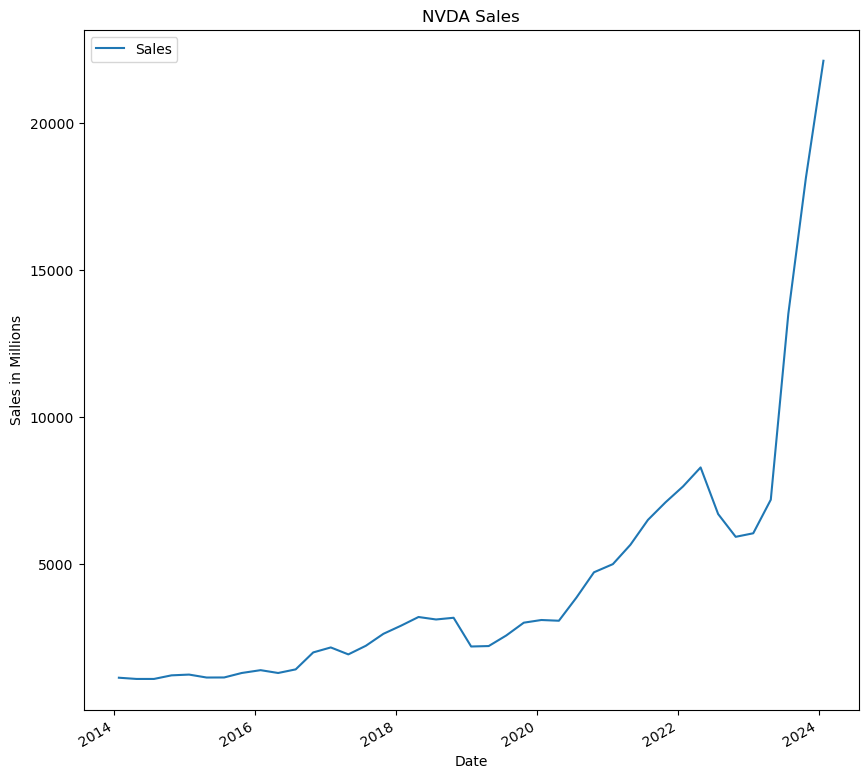

In [268]:
goog.plot('Date', 'Sales')
plt.title('NVDA Sales')
plt.ylabel('Sales in Millions')
plt.show()


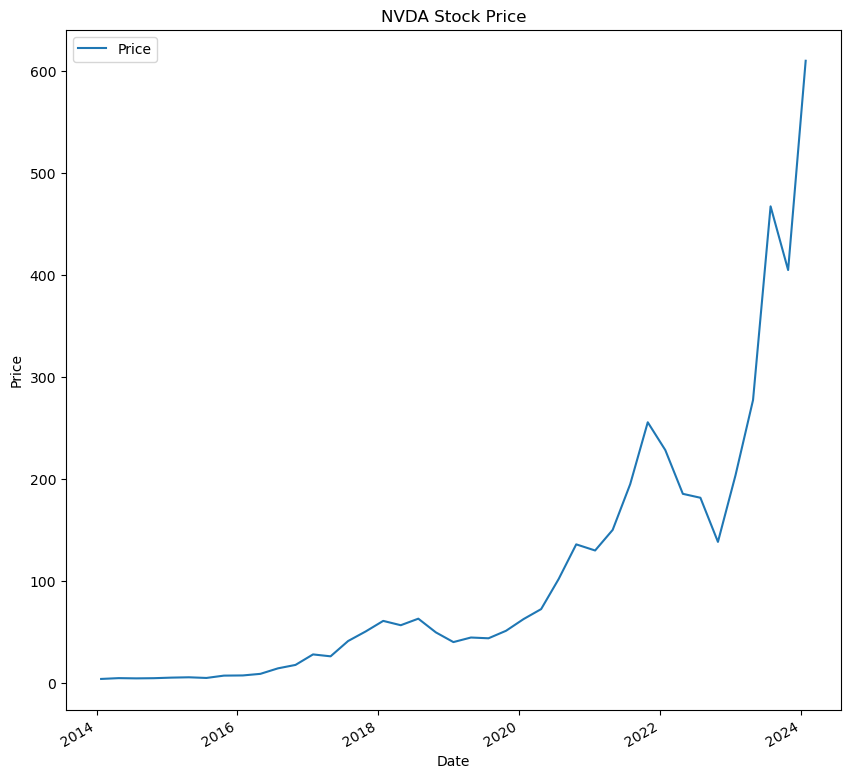

In [269]:
goog.plot('Date','Price')
plt.title('NVDA Stock Price')
plt.ylabel('Price')
plt.show()

Text(0.5, 1.0, 'NVDA Stock Price vs Sales')

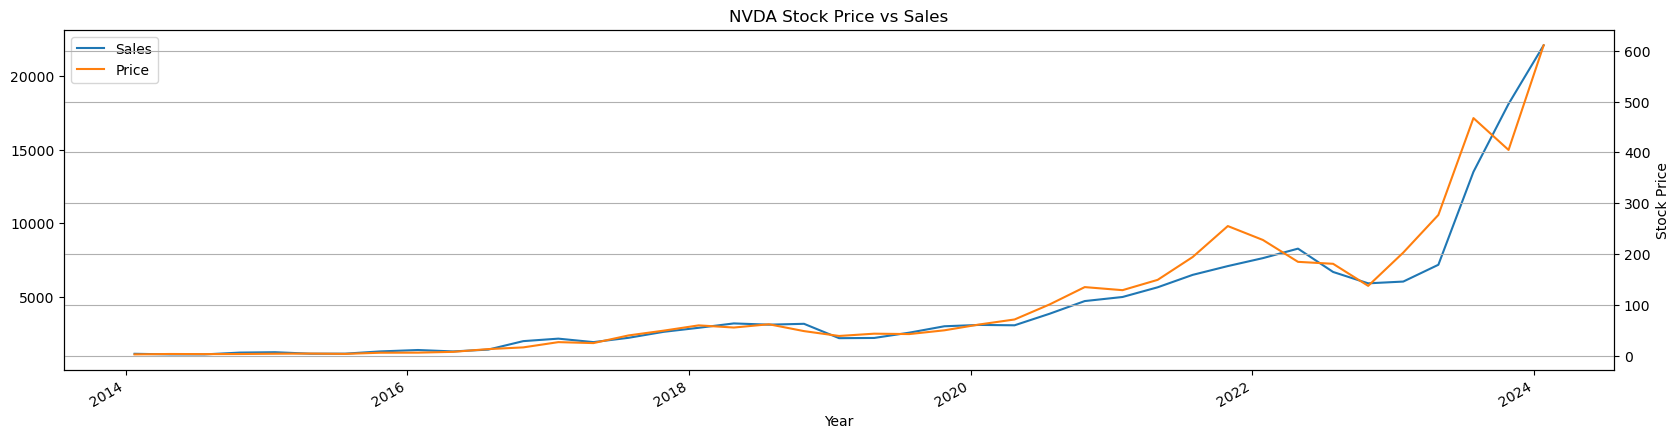

In [270]:
goog.loc[:,['Date','Sales','Price']].plot(x = 'Date',secondary_y=['Price'], xlabel = 'Year', ylabel = 'Stock Price',sharex = True,mark_right=False, figsize = (20,5), grid=True)
plt.title('NVDA Stock Price vs Sales')

[Text(0.5, 1.0, 'NVDA Box and Whisker by Year')]

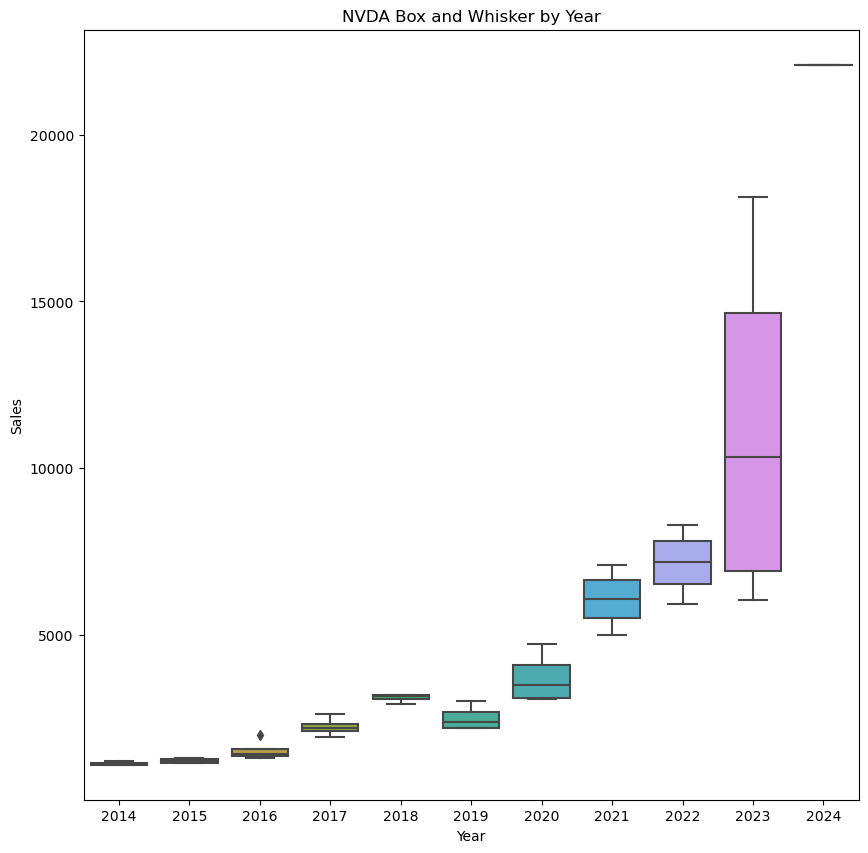

In [271]:
sn.boxplot(x='Year',y='Sales', data = goog).set(title = 'NVDA Box and Whisker by Year')

In [272]:
avgperqtr = goog[['Quarter', 'Sales']].groupby('Quarter').mean().reset_index()



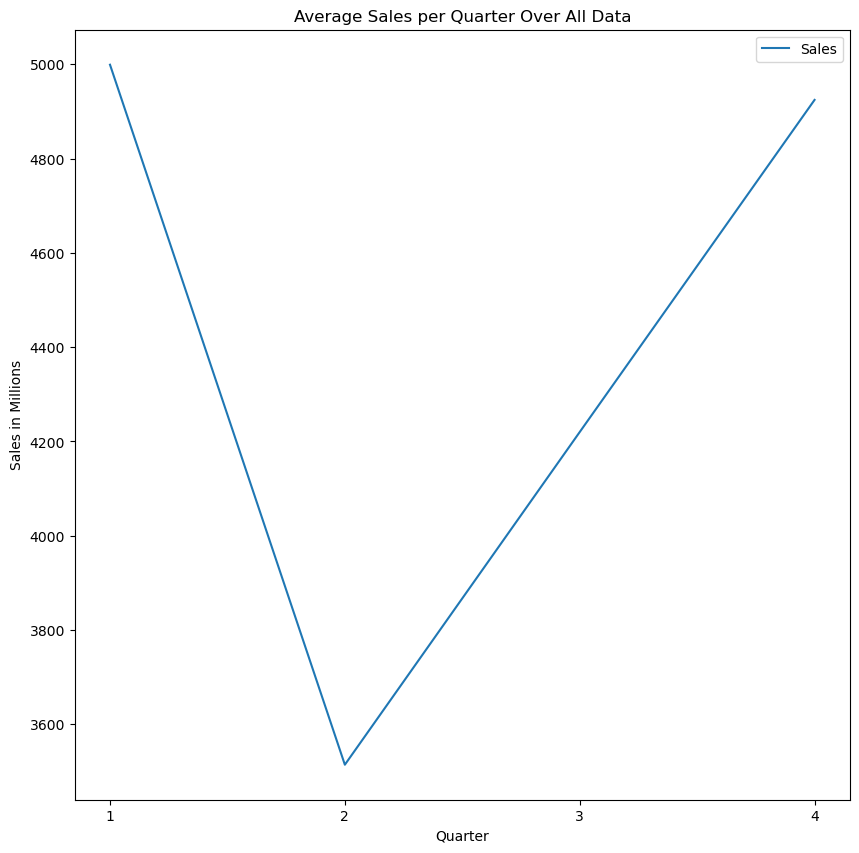

In [273]:
avgperqtr.plot('Quarter','Sales')
plt.ylabel('Sales in Millions')
plt.title('Average Sales per Quarter Over All Data')
plt.xticks(goog.Quarter.unique())
plt.show()

In [274]:
goog1 = pd.DataFrame(goog, columns=['Year','Quarter','Sales'])

In [275]:
dictyear = {}
saleslist = []
for year in goog1['Year'].unique():
    #print(year)
    #byyear = goog1[goog1['Year'] == year]
    #saleslist = saleslist.append(byyear.Sales) 
    dictyear[year] = list(goog1[goog1['Year'] == year].Sales)
    
    
    

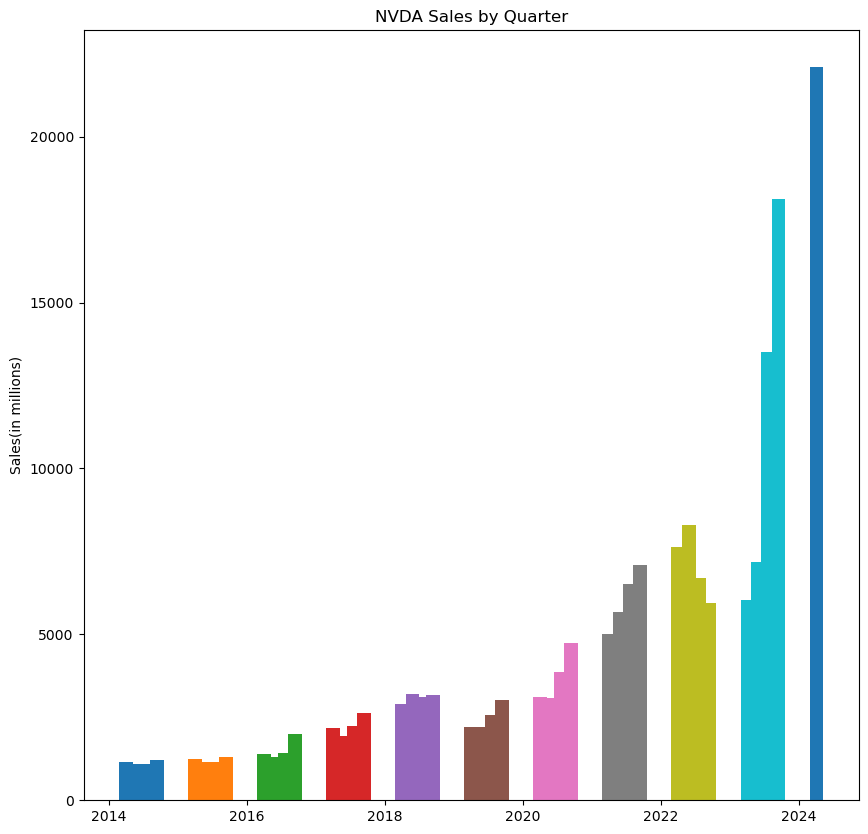

In [277]:
#adopted from https://medium.com/@BetterEverything/graph-quarterly-data-with-python-6f38bcc6b7fe
for year, data in dictyear.items():
    quarters = list(goog1.loc[(goog1['Year'] == year)].Quarter)
    x_coordinates = [year + 0.15 * q for q in quarters]
    #print(x_coordinates, data)
    plt.bar(x_coordinates,data,width=0.2,align='edge')
plt.title('NVDA Sales by Quarter')
plt.ylabel('Sales(in millions)')

#plt.xticks(labels=[np.unique(goog1['Year'].values)], ticks = [])
#print(plt.xticks())
plt.show()

In [278]:
goog.set_index('Date', inplace=True)

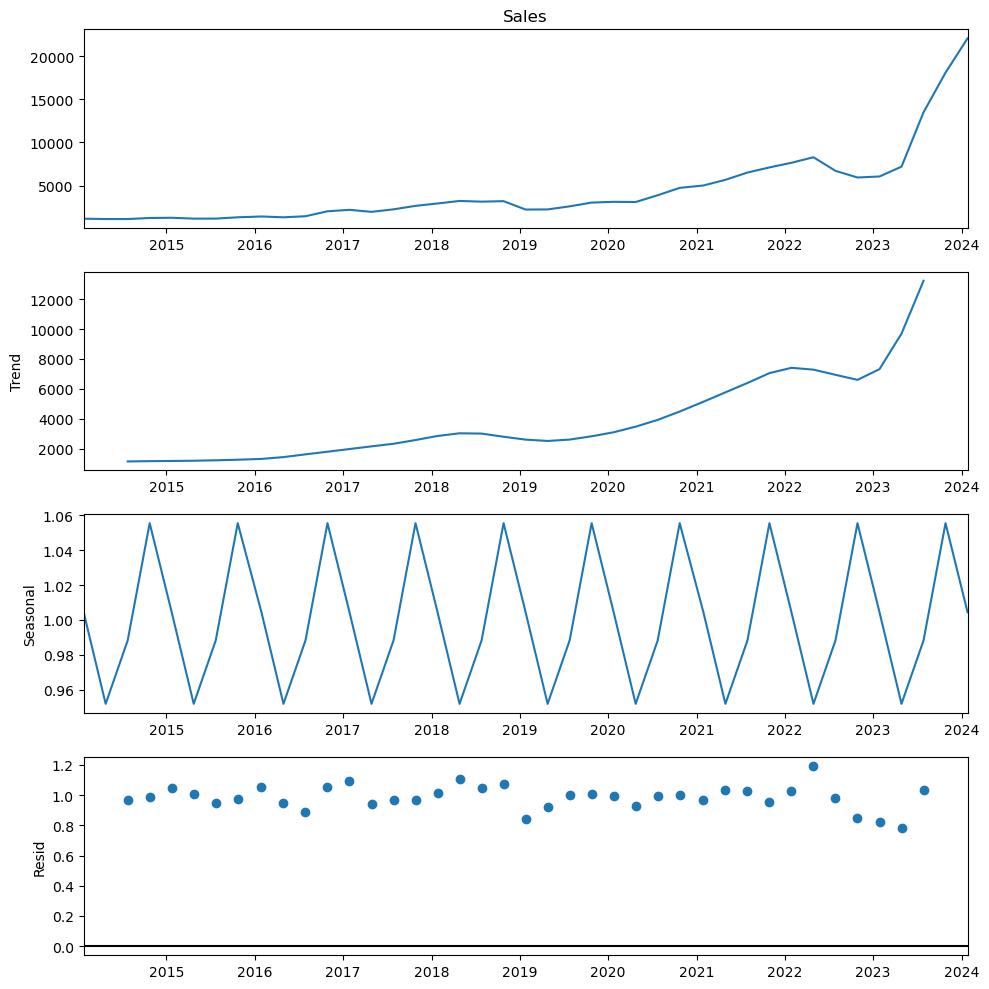

In [279]:

#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Sales'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

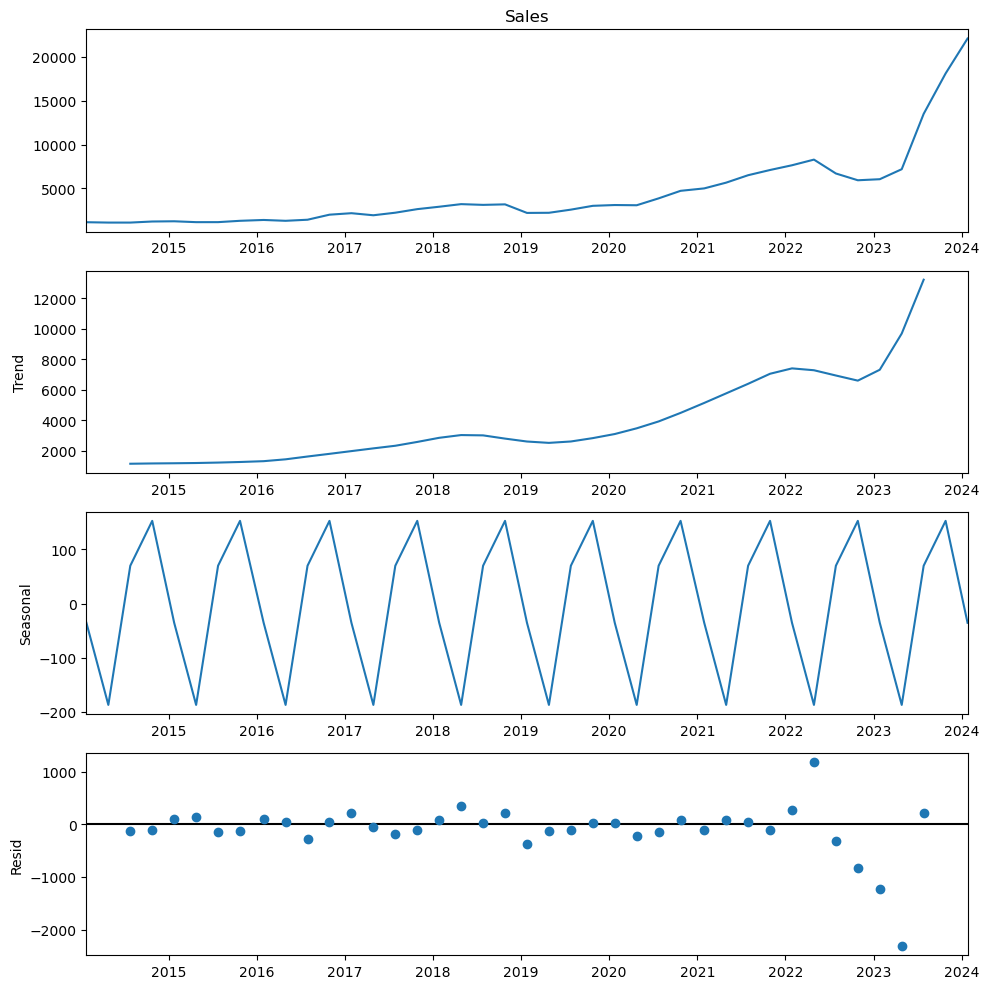

In [280]:
result = seasonal_decompose(goog['Sales'],model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
#plt.title('Time Series Decomposition of Sales')
plt.show()

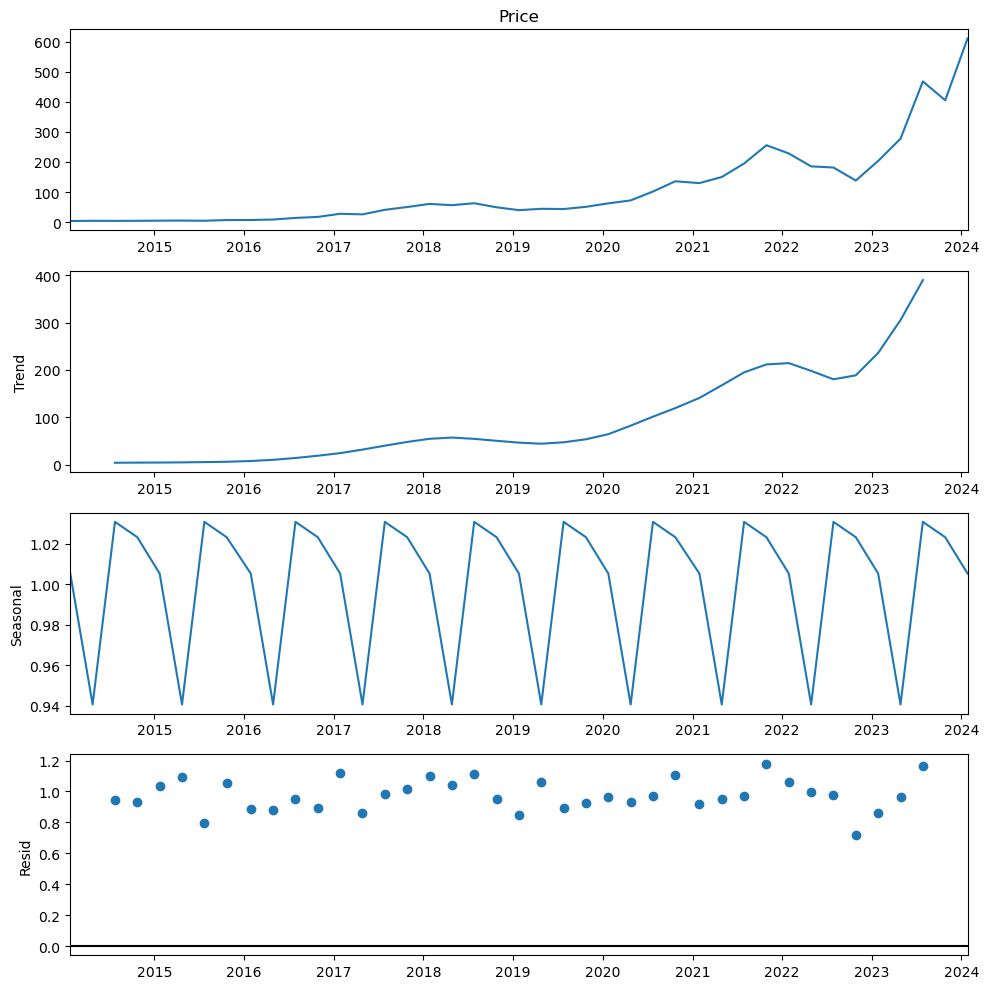

In [281]:
#series = read_csv('airline-passengers.csv', header=0, index_col=0, parse_dates=True,squeeze=True)
result = seasonal_decompose(goog['Price'], model='multiplicative',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

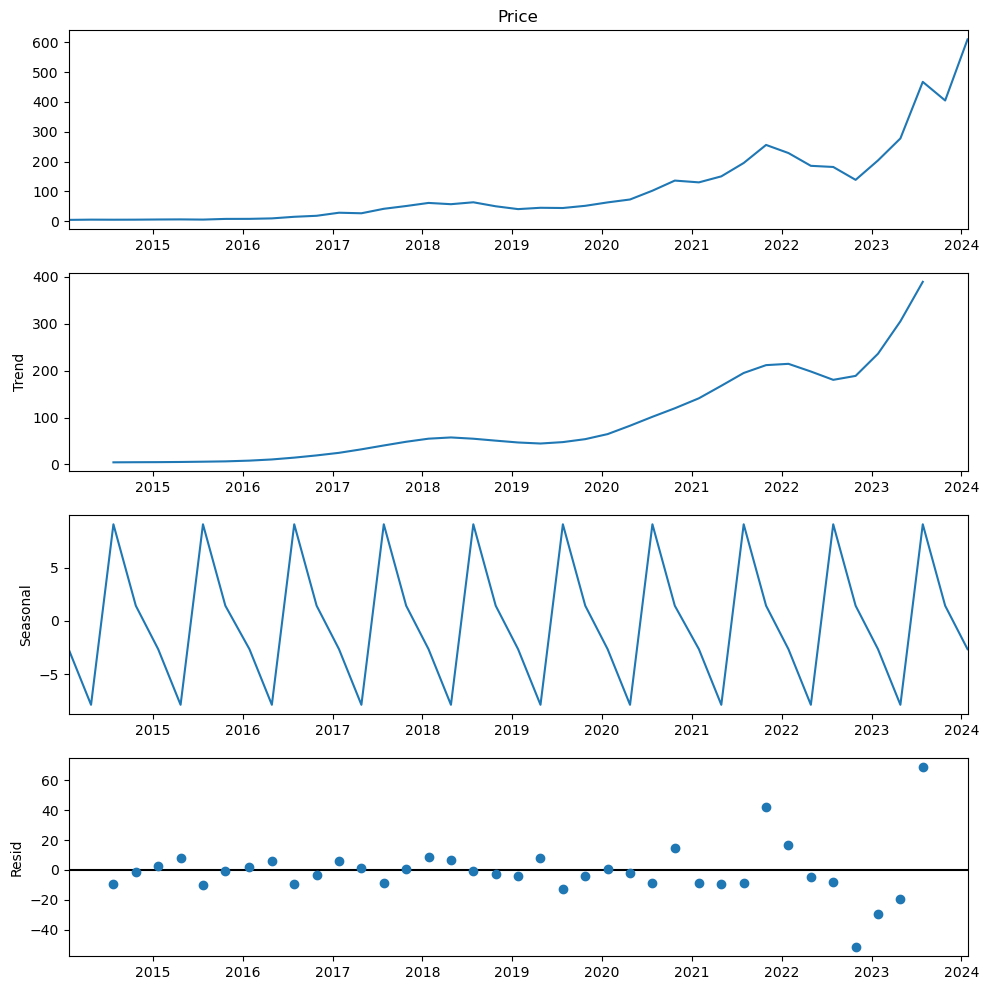

In [282]:
result = seasonal_decompose(goog['Price'], model='additive',period = 4)
plt.rcParams["figure.figsize"] = (10,10)
result.plot()
plt.show()

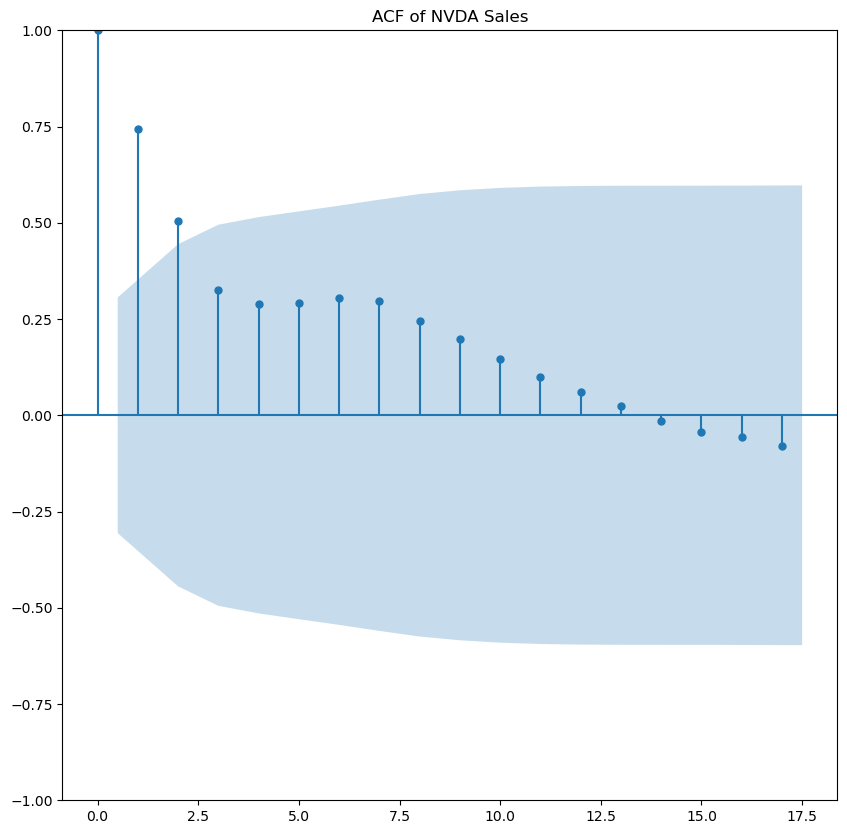

In [283]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_acf(goog['Sales'], title='ACF of NVDA Sales')
pyplot.show()

C:\Users\mdcas\anaconda_3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


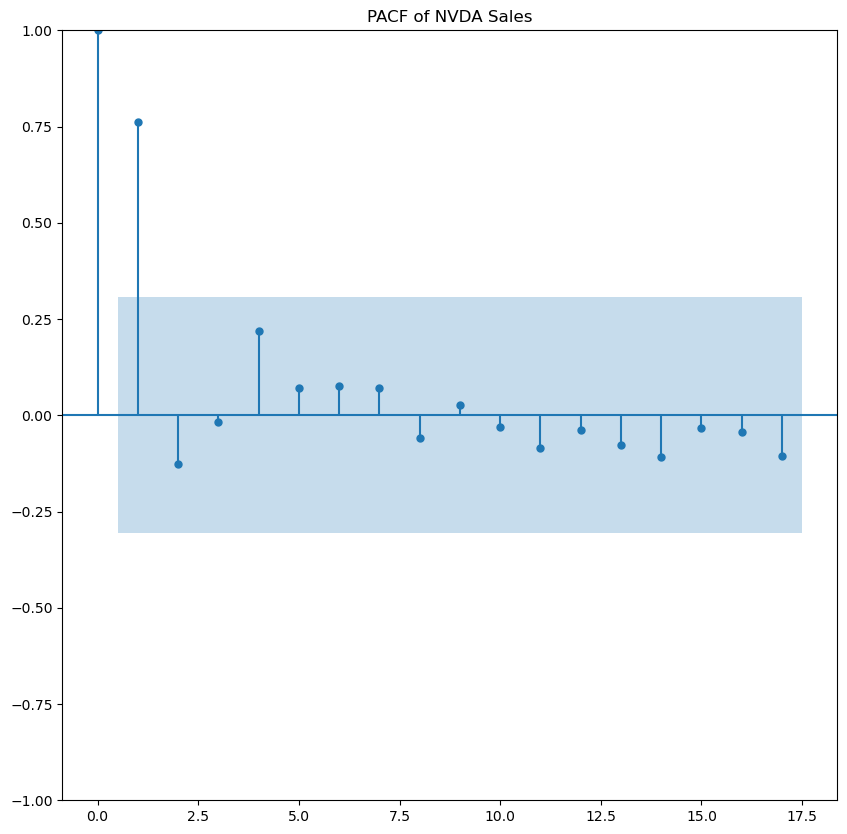

In [284]:
#https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#series = read_csv('daily-minimum-temperatures.csv', header=0, index_col=0)
plot_pacf(goog['Sales'], title='PACF of NVDA Sales')
pyplot.show()


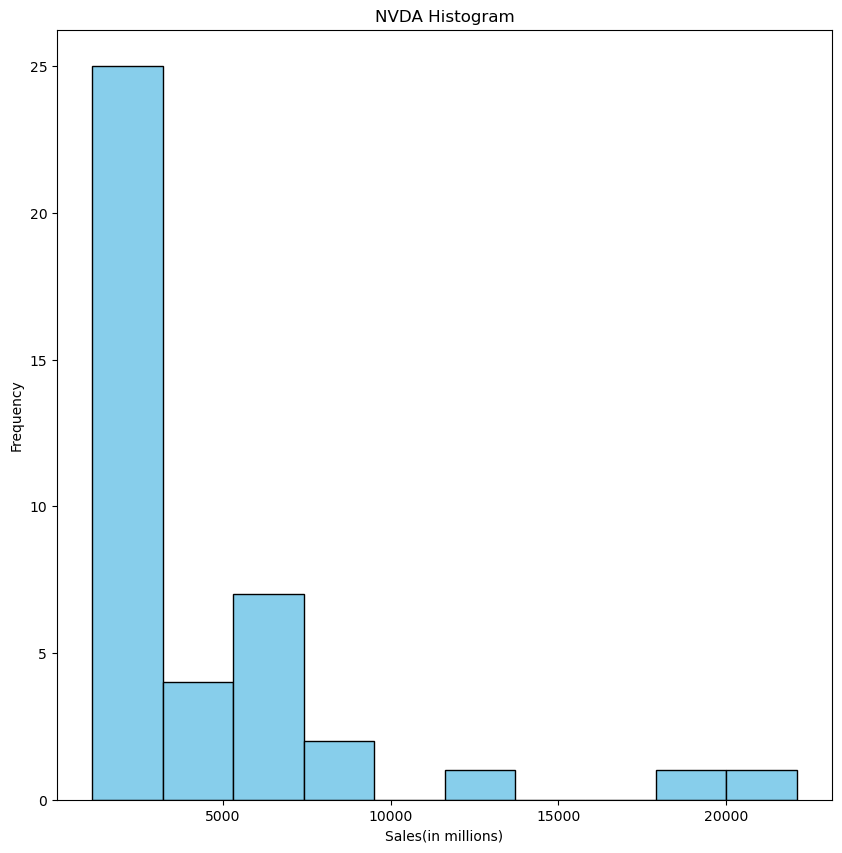

In [285]:
plt.hist(goog['Sales'], color='skyblue', edgecolor='black')
plt.xlabel('Sales(in millions)')
plt.ylabel('Frequency')
plt.title('NVDA Histogram')
pyplot.show()

In [286]:
# statistical test
result = adfuller(goog['Sales'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 3.369466
p-value: 1.000000
Critical Values:
	1%: -3.627
	5%: -2.946
	10%: -2.612


In [287]:
# statistical test
result = adfuller(goog['Price'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 4.251282
p-value: 1.000000
Critical Values:
	1%: -3.654
	5%: -2.957
	10%: -2.618


## NVDA Conclusion

Description of Time Series (is it stationary, are there any trends, seasonality, etc)

For NVDA, you can see there is clearly a very steady trend higher in Sales and Stock Price over the last 10 years.  In particular, the most recent quarter of sales reported is literally almost off the charts. There is seasonality with the 2nd quarter being the lowest compared to the other three quarters. The additive model seems to be more appropriate for the Sales and Stock price data as the residuals in each case appear like white noise in the additive model but have more of a pattern in the multiplicative model. This is shown in both time series decomposition charts. 

The null hypothesis of the ADF test is the time series is Non Stationary. We conclude NVDA is Non Stationary both when looking at Sales and Price since the test statistic is larger than the critical values. 


NVDA does show autocorrelation out to about 3 lags.

